# Nueva Ecija Yield Modeling (2019–2025)

**Capstone II – UST (DSA)**  
**Authors:** Althea Grace Concha, George Emanuel Cruz

## Goal
Build municipality-level seasonal yield prediction models for Nueva Ecija using:
- Yield records (municipality × year × semester)
- Remote sensing indices (NDVI/EVI)
- Weather and agro-climate variables
- Terrain statistics
- Rice area
- Planting month statistics

## Modeling Strategy
This notebook:
1. Builds a unified municipality-season feature table
2. Applies feature screening and multicollinearity control
3. Evaluates six machine learning models using grouped seasonal validation
4. Compares machine learning models against simple historical baselines
5. Selects the best **machine learning model** for website deployment
6. Produces website-ready CSV and JSON outputs

## Models Evaluated
- RandomForest
- XGBoost
- MLPRegressor
- LinearRegression
- GradientBoosting
- KNeighbors

## Main Output Files
- `model_df.csv`
- `cv_results.csv`
- `holdout_results.csv`
- `combined_results.csv`
- `baseline_overall.csv`
- `baseline_by_season.csv`
- website-ready outputs in `web_data/`

## Data Availability and Source Notice

This section builds the modeling dataset by combining yield records, remote sensing variables, agroclimate variables, terrain features, rice area, and planting month statistics for municipality-level rice yield modeling in Nueva Ecija.

### Datasets <span style="color:green;"><strong>included</strong></span> in this GitHub repository

The following processed datasets are included in this repository because they were derived from open or publicly accessible geospatial/climate sources:

| Dataset                       | Source                                                                                                                                                                                              | File                               |
| ----------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------- |
| NDVI/EVI variables            | Google Earth Engine (GEE), using Sentinel-2 Surface Reflectance Harmonized: `COPERNICUS/S2_SR_HARMONIZED` — https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED | `FINAL_NDVI_EVI_2019_2025.csv`     |
| Rainfall variables            | Google Earth Engine (GEE), using GPM IMERG Monthly Final Run V07: `NASA/GPM_L3/IMERG_MONTHLY_V07` — https://developers.google.com/earth-engine/datasets/catalog/NASA_GPM_L3_IMERG_MONTHLY_V07       | `FINAL_RAINFALL_2019_2025.csv`     |
| Surface temperature variables | Google Earth Engine (GEE), using MODIS Terra Land Surface Temperature 8-Day: `MODIS/061/MOD11A2` — https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD11A2                    | `FINAL_SURFACE_TEMP_2019_2025.csv` |
| Other agroclimate variables   | Google Earth Engine (GEE), using ERA5-Land Daily Aggregated: `ECMWF/ERA5_LAND/DAILY_AGGR` — https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_LAND_DAILY_AGGR                  | `FINAL_OTHER_VARS_2019_2025.csv`   |

### Datasets <span style="color:red;"><strong>not included</strong></span> in this GitHub repository

The following datasets are not included because they were obtained through request-based access or are subject to data-sharing restrictions:

| Dataset                                                                         | Source                                                                                | Expected file/s                       |
| ------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------- | ------------------------------------- |
| Municipality-level rice yield records                                           | Philippine Rice Information System (PRiSM) / PhilRice: https://prism.philrice.gov.ph/ | `NuevaEcija_yield_long.csv`           |
| Original Nueva Ecija yield records, covering 2020 Semester 1 to 2025 Semester 1 | Philippine Rice Information System (PRiSM) / PhilRice: https://prism.philrice.gov.ph/ | `NuevaEcija_2020S1-2025S1_Yield.xlsx` |
| Terrain-derived municipality statistics                                         | LiPAD: https://lipad.dream.upd.edu.ph/                                                | `terrain_muni_stats.csv`              |
| Rice area records, covering 2020 Semester 1 to 2025 Semester 1                  | Philippine Rice Information System (PRiSM) / PhilRice: https://prism.philrice.gov.ph/ | `rice_muni_*.csv`                     |
| Planting month statistics, covering 2020 Semester 1 to 2025 Semester 1          | Philippine Rice Information System (PRiSM) / PhilRice: https://prism.philrice.gov.ph/ | `planting_muni_*.csv`                 |

<p style="color:red;"><strong>NOTE: </strong>Due to data-sharing restrictions, the requested PRiSM/PhilRice and LiPAD datasets are not included in this public GitHub repository. To reproduce this section of the notebook, users must request access from the respective data providers and place the approved files in the expected project directory using the filenames or filename patterns shown above.</p>

In [7]:
import os
import glob
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

BASE_DIR = r"C:\Users\conch\Desktop\apply\github\capstone\finalfrfr"

if os.path.isdir(BASE_DIR):
    os.chdir(BASE_DIR)
else:
    print(f"[WARN] BASE_DIR not found: {BASE_DIR}")

print("Current working dir:", os.getcwd())

Current working dir: C:\Users\conch\Desktop\apply\github\capstone\finalfrfr


## Helper Functions

The following helper functions are used for:
- loading and standardizing datasets
- parsing seasonal identifiers
- merging feature tables
- performing correlation and VIF-based feature reduction
- evaluating models
- encoding planting month cyclically for scaled models

In [8]:
def safe_read_csv(path):
    if not os.path.exists(path):
        print(f"[WARN] Missing file: {path}")
        return pd.DataFrame()
    df = pd.read_csv(path)
    print(f"Loaded {path}: {df.shape}")
    return df


def standardize_keys(df, muni_col="MUNICIPALITY", year_col="Year", sem_col="Semester"):
    out = df.copy()

    if muni_col in out.columns:
        out[muni_col] = out[muni_col].astype(str).str.strip()

    if year_col in out.columns:
        out[year_col] = pd.to_numeric(out[year_col], errors="coerce")

    if sem_col in out.columns:
        out[sem_col] = out[sem_col].astype(str).str.strip().str.upper()

    return out


def parse_season(df, adm_col="ADM3_EN", season_col="season_id"):
    out = df.copy()

    if adm_col in out.columns:
        out["MUNICIPALITY"] = out[adm_col].astype(str).str.strip()
    else:
        out["MUNICIPALITY"] = np.nan

    if season_col in out.columns:
        parts = out[season_col].astype(str).str.split("_", n=1, expand=True)
        if parts.shape[1] >= 2:
            out["Year"] = pd.to_numeric(parts[0], errors="coerce")
            out["Semester"] = parts[1].astype(str).str.strip().str.upper()
        else:
            out["Year"] = np.nan
            out["Semester"] = np.nan
    else:
        out["Year"] = np.nan
        out["Semester"] = np.nan

    return out


def safe_merge(left, right, on, label, how="left"):
    left = left.copy()
    right = right.copy()

    missing_keys = [c for c in on if c not in right.columns]
    if missing_keys:
        print(f"[WARN] {label}: skipped merge because these keys are missing: {missing_keys}")
        return left

    out = left.merge(right, on=on, how=how)
    print(f"Merged {label:<20} -> {out.shape}")
    return out


def first_col_containing(df, keywords):
    keywords = [k.lower() for k in keywords]
    for c in df.columns:
        cname = c.lower()
        if any(k in cname for k in keywords):
            return c
    return None


def build_seasonal_agg(file_name, agg_spec, label):
    raw = safe_read_csv(file_name)
    out_cols = ["MUNICIPALITY", "Year", "Semester"] + list(agg_spec.keys())

    if raw.empty:
        return pd.DataFrame(columns=out_cols)

    raw = parse_season(raw)
    raw = standardize_keys(raw)

    for new_col, (src_col, _) in agg_spec.items():
        if src_col not in raw.columns:
            raw[src_col] = np.nan
            print(f"[WARN] {label}: source column not found -> {src_col}")
        raw[src_col] = pd.to_numeric(raw[src_col], errors="coerce")

    raw = raw.dropna(subset=["MUNICIPALITY", "Year", "Semester"]).copy()
    raw["Year"] = raw["Year"].astype(int)

    agg_kwargs = {
        new_col: (src_col, agg_func)
        for new_col, (src_col, agg_func) in agg_spec.items()
    }

    out = (
        raw.groupby(["MUNICIPALITY", "Year", "Semester"], as_index=False)
           .agg(**agg_kwargs)
    )

    print(f"{label} features: {out.shape}")
    return out


def compute_vif_manual(df_num):
    X = df_num.values.astype(float)
    cols = list(df_num.columns)

    rows = []
    for i, col in enumerate(cols):
        y_i = X[:, i]
        X_other = np.delete(X, i, axis=1)

        if X_other.shape[1] == 0:
            r2_i = 0.0
            vif_i = 1.0
        else:
            model = LinearRegression()
            model.fit(X_other, y_i)
            r2_i = model.score(X_other, y_i)
            vif_i = np.inf if r2_i >= 0.999999 else 1.0 / (1.0 - r2_i)

        rows.append({
            "feature": col,
            "R2_against_others": float(r2_i),
            "VIF": float(vif_i) if np.isfinite(vif_i) else np.inf
        })

    return pd.DataFrame(rows).sort_values(["VIF", "feature"], ascending=[False, True]).reset_index(drop=True)


def build_high_corr_pairs(df, cols, threshold=0.90):
    corr = df[cols].corr()
    rows = []

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            c1 = cols[i]
            c2 = cols[j]
            val = corr.loc[c1, c2]

            if pd.notna(val) and abs(val) >= threshold:
                rows.append({
                    "feature_1": c1,
                    "feature_2": c2,
                    "corr": float(val),
                    "abs_corr": float(abs(val))
                })

    if rows:
        return pd.DataFrame(rows).sort_values(
            ["abs_corr", "feature_1", "feature_2"],
            ascending=[False, True, True]
        ).reset_index(drop=True)

    return pd.DataFrame(columns=["feature_1", "feature_2", "corr", "abs_corr"])


def choose_drop_from_pair(c1, c2, missing_pct_map, target_corr_map, preference_rank):
    m1 = missing_pct_map.get(c1, np.inf)
    m2 = missing_pct_map.get(c2, np.inf)

    if m1 != m2:
        keep = c1 if m1 < m2 else c2
    else:
        t1 = target_corr_map.get(c1, -np.inf)
        t2 = target_corr_map.get(c2, -np.inf)
        if t1 != t2:
            keep = c1 if t1 >= t2 else c2
        else:
            r1 = preference_rank.get(c1, 999999)
            r2 = preference_rank.get(c2, 999999)
            keep = c1 if r1 <= r2 else c2

    drop = c2 if keep == c1 else c1
    return keep, drop


def correlation_prune(train_df, cols, target_col="Yield_t_ha", corr_threshold=0.95, preference_order=None):
    if preference_order is None:
        preference_order = cols

    preference_rank = {c: i for i, c in enumerate(preference_order)}
    missing_pct_map = train_df[cols].isna().mean().mul(100).to_dict()

    target_corr_map = (
        train_df[cols + [target_col]]
        .corr(numeric_only=True)[target_col]
        .drop(target_col)
        .abs()
        .fillna(0.0)
        .to_dict()
    )

    pairs_df = build_high_corr_pairs(train_df, cols, threshold=corr_threshold)

    kept = set(cols)
    log_rows = []

    for _, row in pairs_df.iterrows():
        c1, c2 = row["feature_1"], row["feature_2"]

        if c1 not in kept or c2 not in kept:
            continue

        keep, drop = choose_drop_from_pair(
            c1, c2,
            missing_pct_map=missing_pct_map,
            target_corr_map=target_corr_map,
            preference_rank=preference_rank
        )

        kept.remove(drop)

        log_rows.append({
            "feature_1": c1,
            "feature_2": c2,
            "corr": row["corr"],
            "kept": keep,
            "dropped": drop
        })

    kept_cols = [c for c in cols if c in kept]
    log_df = pd.DataFrame(log_rows)

    return kept_cols, pairs_df, log_df


def iterative_vif_prune(train_df, cols, vif_threshold=10.0):
    cols = list(cols)
    drop_rows = []

    while len(cols) >= 2:
        imp = SimpleImputer(strategy="median")
        X_imp = imp.fit_transform(train_df[cols])
        X_imp_df = pd.DataFrame(X_imp, columns=cols, index=train_df.index)

        vif_df = compute_vif_manual(X_imp_df)
        worst = vif_df.iloc[0]

        if worst["VIF"] <= vif_threshold:
            return cols, pd.DataFrame(drop_rows), vif_df

        drop_col = worst["feature"]
        drop_rows.append({
            "dropped_feature": drop_col,
            "worst_vif": worst["VIF"]
        })
        cols.remove(drop_col)

    if len(cols) == 1:
        final_vif_df = pd.DataFrame([{
            "feature": cols[0],
            "R2_against_others": 0.0,
            "VIF": 1.0
        }])
    else:
        final_vif_df = pd.DataFrame(columns=["feature", "R2_against_others", "VIF"])

    return cols, pd.DataFrame(drop_rows), final_vif_df


class MonthCyclicEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        arr = np.asarray(X).reshape(-1, 1).astype(float)
        month = np.rint(arr[:, 0])
        month = np.clip(month, 1, 12)
        angle = 2.0 * np.pi * (month / 12.0)
        return np.column_stack([np.sin(angle), np.cos(angle)])


def metric_dict(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    return {"MSE": float(mse), "RMSE": rmse, "MAE": mae, "R2": r2}


def evaluate_model(model_name, estimator, X_train, y_train, X_test, y_test, groups, cv):
    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }

    cv_out = cross_validate(
        estimator,
        X_train,
        y_train,
        groups=groups,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=1,
        error_score="raise"
    )

    cv_summary = {
        "Model": model_name,
        "CV_RMSE_mean": float(-np.mean(cv_out["test_rmse"])),
        "CV_RMSE_std": float(np.std(-cv_out["test_rmse"])),
        "CV_MAE_mean": float(-np.mean(cv_out["test_mae"])),
        "CV_MAE_std": float(np.std(-cv_out["test_mae"])),
        "CV_R2_mean": float(np.mean(cv_out["test_r2"])),
        "CV_R2_std": float(np.std(cv_out["test_r2"])),
        "CV_n_splits": int(len(cv_out["test_rmse"]))
    }

    fitted = clone(estimator)
    fitted.fit(X_train, y_train)
    y_pred_test = fitted.predict(X_test)

    holdout_summary = {"Model": model_name, **metric_dict(y_test, y_pred_test)}

    fold_tbl = pd.DataFrame({
        "Model": model_name,
        "fold": np.arange(1, len(cv_out["test_rmse"]) + 1),
        "CV_RMSE": -cv_out["test_rmse"],
        "CV_MAE": -cv_out["test_mae"],
        "CV_R2": cv_out["test_r2"]
    })

    return fitted, cv_summary, holdout_summary, fold_tbl, y_pred_test


def make_tree_preprocessor(numeric_features, month_feature=None):
    transformers = [("num", SimpleImputer(strategy="median"), numeric_features)]

    if month_feature is not None:
        transformers.append(
            ("month", SimpleImputer(strategy="most_frequent"), [month_feature])
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False
    )


def make_scaled_preprocessor(numeric_features, month_feature=None):
    transformers = [
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        )
    ]

    if month_feature is not None:
        transformers.append(
            (
                "month_cyc",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("cyc", MonthCyclicEncoder()),
                    ("scaler", StandardScaler())
                ]),
                [month_feature]
            )
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False
    )

## Build the Municipality–Season Feature Table

This section:
- loads the yield target table
- aggregates seasonal remote sensing and weather predictors
- adds terrain, rice area, and planting month data
- merges all sources into one modeling table

In [9]:
# Target yield table
yield_df = safe_read_csv("NuevaEcija_yield_long.csv")

needed_cols = ["MUNICIPALITY", "Semester", "Year", "Yield_t_ha"]
if not yield_df.empty:
    missing_needed = [c for c in needed_cols if c not in yield_df.columns]
    if missing_needed:
        print("[WARN] Missing target columns:", missing_needed)
        yield_df = pd.DataFrame(columns=needed_cols)
    else:
        yield_df = yield_df[needed_cols].copy()
else:
    yield_df = pd.DataFrame(columns=needed_cols)

yield_df = standardize_keys(yield_df)
yield_df["Yield_t_ha"] = pd.to_numeric(yield_df["Yield_t_ha"], errors="coerce")
yield_df = yield_df.dropna(subset=["MUNICIPALITY", "Year", "Semester"]).copy()
yield_df["Year"] = yield_df["Year"].astype(int)
yield_df["Semester_num"] = yield_df["Semester"].map({"S1": 1, "S2": 2})

if yield_df.duplicated(["MUNICIPALITY", "Year", "Semester"]).sum() > 0:
    yield_df = (
        yield_df.groupby(["MUNICIPALITY", "Year", "Semester"], as_index=False)
                .agg(
                    Yield_t_ha=("Yield_t_ha", "mean"),
                    Semester_num=("Semester_num", "first")
                )
    )

# Seasonal remote sensing and agromet
ndvi_feats = build_seasonal_agg(
    "FINAL_NDVI_EVI_2019_2025.csv",
    {
        "NDVI_mean_season": ("NDVI", "mean"),
        "NDVI_max_season": ("NDVI", "max"),
        "EVI_mean_season": ("EVI", "mean"),
        "EVI_max_season": ("EVI", "max"),
    },
    "NDVI/EVI"
)

rain_feats = build_seasonal_agg(
    "FINAL_RAINFALL_2019_2025.csv",
    {
        "rain_season_sum": ("rain_mm", "sum"),
        "rain_monthly_mean": ("rain_mm", "mean"),
    },
    "Rainfall"
)

lst_feats = build_seasonal_agg(
    "FINAL_SURFACE_TEMP_2019_2025.csv",
    {
        "lst_day_mean_season": ("LST_Day_C_mean", "mean"),
        "lst_day_max_season": ("LST_Day_C_mean", "max"),
        "lst_day_min_season": ("LST_Day_C_mean", "min"),
    },
    "LST"
)

other_feats = build_seasonal_agg(
    "FINAL_OTHER_VARS_2019_2025.csv",
    {
        "tmean_season_mean": ("Tmean_C", "mean"),
        "tmax_season_mean": ("Tmax_C", "mean"),
        "tmin_season_mean": ("Tmin_C", "mean"),
        "vpd_season_mean": ("VPD_kPa", "mean"),
        "wind_season_mean": ("WindSpeed_ms", "mean"),
        "et_season_sum": ("ET_mm", "sum"),
        "srad_season_sum": ("Srad_MJ_m2", "sum"),
        "dewpoint_season_mean": ("Dewpoint_C", "mean"),
    },
    "Other agromet"
)

# Terrain
terrain = safe_read_csv("terrain_muni_stats.csv")
if not terrain.empty and "ADM3_EN" in terrain.columns:
    terrain["MUNICIPALITY"] = terrain["ADM3_EN"].astype(str).str.strip()
    terrain_feature_cols = [c for c in terrain.columns if any(k in c.lower() for k in ["dtm", "dsm", "sar"])]
    for c in terrain_feature_cols:
        terrain[c] = pd.to_numeric(terrain[c], errors="coerce")
    terrain_feats = terrain.groupby("MUNICIPALITY", as_index=False)[terrain_feature_cols].mean()
else:
    terrain_feats = pd.DataFrame(columns=["MUNICIPALITY"])

# Rice area
rice_files = sorted(glob.glob("rice_muni_*.csv"))
rice_frames = [pd.read_csv(f) for f in rice_files] if rice_files else []
rice_all = pd.concat(rice_frames, ignore_index=True) if rice_frames else pd.DataFrame()

if not rice_all.empty:
    rice_all = standardize_keys(rice_all)
    rice_all["Year"] = pd.to_numeric(rice_all["Year"], errors="coerce")
    rice_all = rice_all.dropna(subset=["MUNICIPALITY", "Year", "Semester"]).copy()
    rice_all["Year"] = rice_all["Year"].round().astype(int)
    rice_area_col = first_col_containing(rice_all, ["area"])
    if rice_area_col is not None:
        rice_all["rice_area_ha"] = pd.to_numeric(rice_all[rice_area_col], errors="coerce")
        rice_feats = (
            rice_all.groupby(["MUNICIPALITY", "Year", "Semester"], as_index=False)
                    .agg(rice_area_ha=("rice_area_ha", "mean"))
        )
    else:
        rice_feats = pd.DataFrame(columns=["MUNICIPALITY", "Year", "Semester", "rice_area_ha"])
else:
    rice_feats = pd.DataFrame(columns=["MUNICIPALITY", "Year", "Semester", "rice_area_ha"])

# Planting month
plant_files = sorted(glob.glob("planting_muni_*.csv"))
plant_frames = [pd.read_csv(f) for f in plant_files] if plant_files else []
plant_all = pd.concat(plant_frames, ignore_index=True) if plant_frames else pd.DataFrame()

if not plant_all.empty:
    if "year" in plant_all.columns and "Year" in plant_all.columns:
        plant_all = plant_all.drop(columns=["year"])

    plant_all = standardize_keys(plant_all)
    plant_all["Year"] = pd.to_numeric(plant_all["Year"], errors="coerce")
    plant_all = plant_all.dropna(subset=["MUNICIPALITY", "Year", "Semester"]).copy()
    plant_all["Year"] = plant_all["Year"].round().astype(int)

    plant_all = plant_all.rename(columns={
        "plant_month_num_mean": "plant_month_mean",
        "plant_month_num_median": "plant_month_median",
        "plant_month_num_majority": "plant_month_majority",
    })

    plant_stat_cols = [c for c in ["plant_month_mean", "plant_month_median", "plant_month_majority"] if c in plant_all.columns]
    for c in plant_stat_cols:
        plant_all[c] = pd.to_numeric(plant_all[c], errors="coerce")

    if plant_stat_cols:
        agg_dict = {c: (c, "mean") for c in plant_stat_cols}
        plant_feats = (
            plant_all.groupby(["MUNICIPALITY", "Year", "Semester"], as_index=False)
                     .agg(**agg_dict)
        )
    else:
        plant_feats = pd.DataFrame(columns=["MUNICIPALITY", "Year", "Semester"])
else:
    plant_feats = pd.DataFrame(columns=["MUNICIPALITY", "Year", "Semester"])

# Merge full feature table
feat_df = yield_df.copy()
feat_df = safe_merge(feat_df, rain_feats,    ["MUNICIPALITY", "Year", "Semester"], "rain_feats")
feat_df = safe_merge(feat_df, lst_feats,     ["MUNICIPALITY", "Year", "Semester"], "lst_feats")
feat_df = safe_merge(feat_df, other_feats,   ["MUNICIPALITY", "Year", "Semester"], "other_feats")
feat_df = safe_merge(feat_df, ndvi_feats,    ["MUNICIPALITY", "Year", "Semester"], "ndvi_feats")
feat_df = safe_merge(feat_df, terrain_feats, ["MUNICIPALITY"],                     "terrain_feats")
feat_df = safe_merge(feat_df, rice_feats,    ["MUNICIPALITY", "Year", "Semester"], "rice_feats")
feat_df = safe_merge(feat_df, plant_feats,   ["MUNICIPALITY", "Year", "Semester"], "plant_feats")

master_df = feat_df.copy()
master_df["season_id"] = master_df["Year"].astype(int).astype(str) + "_" + master_df["Semester"].astype(str)

# Observed modeling table
model_df = master_df.dropna(subset=["Yield_t_ha"]).copy()
model_df.to_csv("model_df.csv", index=False)

print("Saved: model_df.csv")
display(model_df.head(10))

Loaded NuevaEcija_yield_long.csv: (384, 7)


Loaded FINAL_NDVI_EVI_2019_2025.csv: (2016, 26)
NDVI/EVI features: (352, 7)
Loaded FINAL_RAINFALL_2019_2025.csv: (2016, 25)
Rainfall features: (352, 5)
Loaded FINAL_SURFACE_TEMP_2019_2025.csv: (2016, 25)
LST features: (352, 6)
Loaded FINAL_OTHER_VARS_2019_2025.csv: (2016, 32)
Other agromet features: (352, 11)
Loaded terrain_muni_stats.csv: (32, 22)
Merged rain_feats           -> (384, 7)
Merged lst_feats            -> (384, 10)
Merged other_feats          -> (384, 18)
Merged ndvi_feats           -> (384, 22)
Merged terrain_feats        -> (384, 28)
Merged rice_feats           -> (384, 29)
Merged plant_feats          -> (384, 32)
Saved: model_df.csv


,MUNICIPALITY,Semester,Year,Yield_t_ha,Semester_num,rain_season_sum,rain_monthly_mean,lst_day_mean_season,lst_day_max_season,lst_day_min_season,tmean_season_mean,tmax_season_mean,tmin_season_mean,vpd_season_mean,wind_season_mean,et_season_sum,srad_season_sum,dewpoint_season_mean,NDVI_mean_season,NDVI_max_season,EVI_mean_season,EVI_max_season,sar_mean,sar_stdev,dsm_mean,dsm_stdev,dtm_mean,dtm_stdev,rice_area_ha,plant_month_mean,plant_month_median,plant_month_majority,season_id
0,Aliaga,S1,2020,6.875074,1,434.744691,72.457448,30.829837,34.103787,27.269586,26.006259,31.066579,21.831014,0.894816,1.678885,-17.434188,108.913038,20.813703,0.524610,0.729598,1.693169,2.552182,28.737587,4.959623,24.466274,4.146231,23.825974,4.400914,"130,321.394000",5.136665,2.000000,1.000000,2020_S1
1,Bongabon,S1,2020,7.722523,1,503.187649,83.864608,27.690194,31.317174,26.158334,23.192077,26.678208,20.622116,0.510925,1.700542,-18.623068,104.544743,19.928177,0.593902,0.673646,1.993538,2.237939,414.375889,353.054407,413.114129,354.484608,412.726492,354.386359,"31,315.626000",7.026846,10.000000,1.000000,2020_S1
2,Cabanatuan City,S1,2020,7.137664,1,464.244585,77.374097,31.375888,35.143583,29.794655,25.786674,30.422180,21.988973,0.778878,1.808632,-18.256316,107.912080,21.294532,0.531915,0.622340,1.883422,3.260366,42.417067,12.680221,38.541995,12.378196,38.111311,12.641626,"78,876.478000",4.808830,2.000000,1.000000,2020_S1
3,Cabiao,S1,2020,7.066048,1,459.151890,76.525315,30.417546,34.004616,28.091106,26.018795,30.645448,22.251061,0.835659,1.737918,-18.644186,107.898059,21.230833,0.490542,0.629363,1.859435,2.732331,13.762377,3.952579,9.969151,2.839451,9.423860,2.957399,"56,258.756000",8.315596,11.000000,12.000000,2020_S1
4,Carranglan,S1,2020,7.913497,1,446.545050,74.424175,26.824393,31.303434,24.781130,21.785485,25.941308,18.634655,0.542157,1.686624,-16.807747,101.614451,18.036915,0.652347,0.739378,2.200783,2.691552,643.838822,330.144287,662.003504,338.227713,661.138815,338.243392,"1,875.619000",6.582225,10.000000,1.000000,2020_S1
5,City Of Gapan,S1,2020,7.412189,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020_S1
6,Cuyapo,S1,2020,6.564741,1,372.994281,62.165714,32.342300,35.765468,31.090347,25.889111,31.035954,21.682763,0.919541,1.177533,-16.148140,108.675620,20.487173,0.552104,0.653616,1.573864,1.840739,63.290888,35.587307,60.726608,37.248321,60.600549,37.263245,"62,104.657000",4.489951,2.000000,1.000000,2020_S1
7,Gabaldon (Bitulok & Sabani),S1,2020,7.304766,1,545.592480,90.932080,27.096263,30.777939,25.346464,22.525750,25.333035,20.529348,0.479106,2.330855,-21.156310,103.824121,19.353945,0.640274,0.744306,1.435845,2.761825,489.366379,339.763587,488.777961,342.026070,487.861475,341.510883,NaN,NaN,NaN,NaN,2020_S1
8,General Mamerto Natividad,S1,2020,7.674779,1,464.898999,77.483166,30.677118,35.571126,26.862318,25.298693,29.713896,21.744057,0.706043,1.707602,-18.210693,107.150989,21.163941,0.497705,0.722393,1.449279,2.236605,56.175912,8.537457,53.049729,8.131766,53.648251,8.461276,"28,963.994000",6.840822,10.000000,12.000000,2020_S1
9,General Tinio (Papaya),S1,2020,7.531548,1,566.169479,94.361580,26.444649,29.778171,24.663470,24.100401,26.981204,22.006960,0.547770,3.057771,-19.846233,100.282901,20.748116,0.672220,0.773447,1.922521,2.760648,373.813742,230.309574,371.416719,230.283800,370.256232,230.986150,NaN,NaN,NaN,NaN,2020_S1


## Validation Design and Feature Screening

Validation is based on:
- grouped seasonal cross-validation on the training seasons
- a final holdout using the latest observed seasons

Feature screening includes:
- structural removal of redundant variables
- correlation-based pruning
- VIF-based multicollinearity reduction for scaled and linear models

In [10]:
observed_df = master_df.dropna(subset=["Yield_t_ha"]).copy()

observed_seasons = (
    observed_df[["Year", "Semester", "Semester_num", "season_id"]]
    .drop_duplicates()
    .sort_values(["Year", "Semester_num"])
    .reset_index(drop=True)
)

n_holdout_seasons = 2 if len(observed_seasons) >= 8 else 1
holdout_season_ids = observed_seasons["season_id"].tail(n_holdout_seasons).tolist()

train_df = observed_df[~observed_df["season_id"].isin(holdout_season_ids)].copy()
test_df  = observed_df[ observed_df["season_id"].isin(holdout_season_ids)].copy()

train_df["season_id"] = train_df["Year"].astype(int).astype(str) + "_" + train_df["Semester"].astype(str)
test_df["season_id"] = test_df["Year"].astype(int).astype(str) + "_" + test_df["Semester"].astype(str)

cv_n_splits = min(5, train_df["season_id"].nunique()) if train_df["season_id"].nunique() >= 2 else 2

target_col = "Yield_t_ha"

numeric_feature_candidates = [
    c for c in observed_df.columns
    if pd.api.types.is_numeric_dtype(observed_df[c])
    and c not in ["Year", "Semester_num", target_col]
]

manual_drop_structural = []
if "rain_monthly_mean" in numeric_feature_candidates:
    manual_drop_structural.append("rain_monthly_mean")
if "plant_month_mean" in numeric_feature_candidates:
    manual_drop_structural.append("plant_month_mean")
if "plant_month_median" in numeric_feature_candidates:
    manual_drop_structural.append("plant_month_median")

tree_feature_candidates = [c for c in numeric_feature_candidates if c not in manual_drop_structural]

zero_var_cols = [c for c in tree_feature_candidates if train_df[c].nunique(dropna=True) <= 1]
tree_feature_candidates = [c for c in tree_feature_candidates if c not in zero_var_cols]

raw_plant_month_feature = "plant_month_majority" if "plant_month_majority" in tree_feature_candidates else None
scaled_base_candidates = [c for c in tree_feature_candidates if c != raw_plant_month_feature]

preference_order = [
    "rain_season_sum",
    "lst_day_mean_season", "lst_day_max_season", "lst_day_min_season",
    "tmean_season_mean", "tmax_season_mean", "tmin_season_mean",
    "vpd_season_mean", "wind_season_mean", "et_season_sum", "srad_season_sum", "dewpoint_season_mean",
    "NDVI_mean_season", "NDVI_max_season", "EVI_mean_season", "EVI_max_season",
    "rice_area_ha",
    "sar_mean", "sar_stdev",
    "dtm_mean", "dtm_stdev",
    "dsm_mean", "dsm_stdev"
]
preference_order = preference_order + [c for c in scaled_base_candidates if c not in preference_order]

scaled_corr_pruned_features, high_corr_pairs_df, corr_drop_log = correlation_prune(
    train_df=train_df,
    cols=scaled_base_candidates,
    target_col=target_col,
    corr_threshold=0.95,
    preference_order=preference_order
)

imp0 = SimpleImputer(strategy="median")
X0 = imp0.fit_transform(train_df[scaled_corr_pruned_features])
X0_df = pd.DataFrame(X0, columns=scaled_corr_pruned_features, index=train_df.index)

initial_vif_df = compute_vif_manual(X0_df)

linear_base_features, vif_drop_log, final_vif_df = iterative_vif_prune(
    train_df=train_df,
    cols=scaled_corr_pruned_features,
    vif_threshold=10.0
)

TREE_FEATURES = tree_feature_candidates.copy()
SCALED_BASE_FEATURES = linear_base_features.copy()
LINEAR_BASE_FEATURES = linear_base_features.copy()
USE_PLANT_MONTH_CYCLE_FOR_SCALED = raw_plant_month_feature is not None

feature_sets = {
    "holdout_season_ids": holdout_season_ids,
    "cv_n_splits": int(cv_n_splits),
    "TREE_FEATURES": TREE_FEATURES,
    "SCALED_BASE_FEATURES": SCALED_BASE_FEATURES,
    "LINEAR_BASE_FEATURES": LINEAR_BASE_FEATURES,
    "RAW_PLANT_MONTH_FEATURE_FOR_TREES": raw_plant_month_feature,
    "USE_PLANT_MONTH_CYCLE_FOR_SCALED": USE_PLANT_MONTH_CYCLE_FOR_SCALED
}

with open("feature_sets.json", "w", encoding="utf-8") as f:
    json.dump(feature_sets, f, ensure_ascii=False, indent=2)

train_df.to_csv("train_df.csv", index=False)
test_df.to_csv("test_df.csv", index=False)
high_corr_pairs_df.to_csv("feature_correlation_pairs.csv", index=False)
corr_drop_log.to_csv("feature_correlation_drop_log.csv", index=False)
initial_vif_df.to_csv("initial_vif_table.csv", index=False)
vif_drop_log.to_csv("vif_drop_log.csv", index=False)
final_vif_df.to_csv("final_vif_table.csv", index=False)

print("Holdout seasons:", holdout_season_ids)
print("Train rows:", len(train_df), "| Test rows:", len(test_df))
print("Grouped CV splits:", cv_n_splits)
print("Tree features:", len(TREE_FEATURES))
print("Linear/scaled features:", len(LINEAR_BASE_FEATURES))

Holdout seasons: ['2024_S2', '2025_S1']
Train rows: 288 | Test rows: 64
Grouped CV splits: 5
Tree features: 24
Linear/scaled features: 13


## Model Training and Comparison

The six machine learning models are evaluated using:
- grouped cross-validation on the training seasons
- final holdout testing on the latest observed seasons

Model-specific preprocessing is applied as follows:
- tree models: imputation only
- scaled models: imputation + standardization + cyclic planting month encoding
- linear model: imputation + standardization + multicollinearity-safe feature set

In [11]:
y_train = train_df["Yield_t_ha"].astype(float).values
y_test = test_df["Yield_t_ha"].astype(float).values
groups = train_df["season_id"].values
cv = GroupKFold(n_splits=cv_n_splits)

tree_month_feature = raw_plant_month_feature
tree_numeric_features = [c for c in TREE_FEATURES if c != tree_month_feature]
tree_input_columns = tree_numeric_features + ([tree_month_feature] if tree_month_feature is not None else [])

scaled_month_feature = tree_month_feature if USE_PLANT_MONTH_CYCLE_FOR_SCALED else None
scaled_input_columns = SCALED_BASE_FEATURES + ([scaled_month_feature] if scaled_month_feature is not None and scaled_month_feature not in SCALED_BASE_FEATURES else [])
linear_input_columns = LINEAR_BASE_FEATURES + ([scaled_month_feature] if scaled_month_feature is not None and scaled_month_feature not in LINEAR_BASE_FEATURES else [])

X_train_tree = train_df[tree_input_columns].copy()
X_test_tree = test_df[tree_input_columns].copy()

X_train_scaled = train_df[scaled_input_columns].copy()
X_test_scaled = test_df[scaled_input_columns].copy()

X_train_linear = train_df[linear_input_columns].copy()
X_test_linear = test_df[linear_input_columns].copy()

tree_preprocessor = make_tree_preprocessor(tree_numeric_features, tree_month_feature)
scaled_preprocessor = make_scaled_preprocessor(SCALED_BASE_FEATURES, scaled_month_feature)
linear_preprocessor = make_scaled_preprocessor(LINEAR_BASE_FEATURES, scaled_month_feature)

model_specs = []

model_specs.append({
    "Model": "RandomForest",
    "input_kind": "tree",
    "estimator": Pipeline([
        ("prep", tree_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=1,
            random_state=42,
            n_jobs=-1
        ))
    ])
})

try:
    from xgboost import XGBRegressor
    model_specs.append({
        "Model": "XGBoost",
        "input_kind": "tree",
        "estimator": Pipeline([
            ("prep", tree_preprocessor),
            ("model", XGBRegressor(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.90,
                colsample_bytree=0.90,
                reg_lambda=1.0,
                random_state=42,
                n_jobs=-1
            ))
        ])
    })
except ImportError:
    print("xgboost is not installed. XGBoost will be skipped.")

model_specs.append({
    "Model": "GradientBoosting",
    "input_kind": "tree",
    "estimator": Pipeline([
        ("prep", tree_preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ])
})

model_specs.append({
    "Model": "MLPRegressor",
    "input_kind": "scaled",
    "estimator": Pipeline([
        ("prep", scaled_preprocessor),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            alpha=0.001,
            max_iter=4000,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30,
            random_state=42
        ))
    ])
})

model_specs.append({
    "Model": "KNeighbors",
    "input_kind": "scaled",
    "estimator": Pipeline([
        ("prep", scaled_preprocessor),
        ("model", KNeighborsRegressor(
            n_neighbors=7,
            weights="distance"
        ))
    ])
})

model_specs.append({
    "Model": "LinearRegression",
    "input_kind": "linear",
    "estimator": Pipeline([
        ("prep", linear_preprocessor),
        ("model", LinearRegression())
    ])
})

cv_rows = []
holdout_rows = []
fold_rows = []
pred_tables = []
status_rows = []
fitted_models = {}

for spec in model_specs:
    model_name = spec["Model"]
    input_kind = spec["input_kind"]
    estimator = spec["estimator"]

    try:
        if input_kind == "tree":
            Xtr, Xte = X_train_tree, X_test_tree
            feature_count = Xtr.shape[1]
        elif input_kind == "scaled":
            Xtr, Xte = X_train_scaled, X_test_scaled
            feature_count = Xtr.shape[1]
        else:
            Xtr, Xte = X_train_linear, X_test_linear
            feature_count = Xtr.shape[1]

        fitted, cv_summary, holdout_summary, fold_tbl, y_pred_test = evaluate_model(
            model_name=model_name,
            estimator=estimator,
            X_train=Xtr,
            y_train=y_train,
            X_test=Xte,
            y_test=y_test,
            groups=groups,
            cv=cv
        )

        fitted_models[model_name] = fitted
        cv_summary["Feature_count_before_transform"] = int(feature_count)
        holdout_summary["Feature_count_before_transform"] = int(feature_count)

        cv_rows.append(cv_summary)
        holdout_rows.append(holdout_summary)
        fold_rows.append(fold_tbl)

        pred_tbl = test_df[["MUNICIPALITY", "Year", "Semester", "season_id", "Yield_t_ha"]].copy()
        pred_tbl["Model"] = model_name
        pred_tbl["Prediction"] = y_pred_test
        pred_tbl["Residual"] = pred_tbl["Yield_t_ha"] - pred_tbl["Prediction"]
        pred_tables.append(pred_tbl)

        status_rows.append({
            "Model": model_name,
            "Status": "OK",
            "Message": "",
            "Feature_count_before_transform": int(feature_count)
        })

    except Exception as e:
        status_rows.append({
            "Model": model_name,
            "Status": "FAILED",
            "Message": str(e),
            "Feature_count_before_transform": np.nan
        })

cv_results_df = pd.DataFrame(cv_rows)
holdout_results_df = pd.DataFrame(holdout_rows)
cv_folds_df = pd.concat(fold_rows, ignore_index=True) if fold_rows else pd.DataFrame()
holdout_preds_long_df = pd.concat(pred_tables, ignore_index=True) if pred_tables else pd.DataFrame()
model_status_df = pd.DataFrame(status_rows)

season_metric_rows = []
for (model_name, season_id), grp in holdout_preds_long_df.groupby(["Model", "season_id"]):
    season_metric_rows.append({
        "Model": model_name,
        "season_id": season_id,
        **metric_dict(grp["Yield_t_ha"].values, grp["Prediction"].values)
    })

holdout_by_season_df = pd.DataFrame(season_metric_rows).sort_values(["Model", "season_id"]).reset_index(drop=True)

semester_metric_rows = []
for (model_name, semester), grp in holdout_preds_long_df.groupby(["Model", "Semester"]):
    semester_metric_rows.append({
        "Model": model_name,
        "Semester": semester,
        **metric_dict(grp["Yield_t_ha"].values, grp["Prediction"].values)
    })

holdout_by_semester_df = pd.DataFrame(semester_metric_rows).sort_values(["Model", "Semester"]).reset_index(drop=True)

holdout_preds_wide_df = (
    holdout_preds_long_df
    .pivot_table(
        index=["MUNICIPALITY", "Year", "Semester", "season_id", "Yield_t_ha"],
        columns="Model",
        values="Prediction"
    )
    .reset_index()
)

combined_results_df = cv_results_df.merge(
    holdout_results_df,
    on=["Model", "Feature_count_before_transform"],
    how="outer"
)

combined_results_df["RMSE_gap_holdout_minus_cv"] = combined_results_df["RMSE"] - combined_results_df["CV_RMSE_mean"]
combined_results_df = combined_results_df.sort_values(["RMSE", "CV_RMSE_mean", "R2"], ascending=[True, True, False]).reset_index(drop=True)

cv_results_df.to_csv("cv_results.csv", index=False)
holdout_results_df.to_csv("holdout_results.csv", index=False)
cv_folds_df.to_csv("cv_folds.csv", index=False)
holdout_by_season_df.to_csv("holdout_by_season.csv", index=False)
holdout_by_semester_df.to_csv("holdout_by_semester.csv", index=False)
combined_results_df.to_csv("combined_results.csv", index=False)
holdout_preds_long_df.to_csv("holdout_predictions_long.csv", index=False)
holdout_preds_wide_df.to_csv("holdout_predictions_wide.csv", index=False)
model_status_df.to_csv("model_status.csv", index=False)

print("Saved: cv_results.csv")
print("Saved: holdout_results.csv")
print("Saved: combined_results.csv")
print("Saved: holdout_by_season.csv")
print("Saved: holdout_by_semester.csv")
display(combined_results_df)

Saved: cv_results.csv
Saved: holdout_results.csv
Saved: combined_results.csv
Saved: holdout_by_season.csv
Saved: holdout_by_semester.csv


,Model,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_MAE_std,CV_R2_mean,CV_R2_std,CV_n_splits,Feature_count_before_transform,MSE,RMSE,MAE,R2,RMSE_gap_holdout_minus_cv
0,RandomForest,0.899991,0.495376,0.659891,0.418050,-0.823679,1.970567,5,24,0.533874,0.730667,0.551407,0.591111,-0.169324
1,XGBoost,0.883354,0.428386,0.655935,0.363013,-0.940632,2.315602,5,24,0.553086,0.743698,0.544948,0.576397,-0.139656
2,GradientBoosting,0.941001,0.482668,0.704390,0.406282,-1.060574,2.317899,5,24,0.596295,0.772201,0.576007,0.543304,-0.168800
3,LinearRegression,0.919637,0.479125,0.795364,0.464260,-0.279054,0.830005,5,14,0.606522,0.778795,0.575205,0.535472,-0.140842
4,KNeighbors,0.613095,0.202435,0.469803,0.163239,0.136763,0.991517,5,14,0.697538,0.835187,0.639237,0.465763,0.222093
5,MLPRegressor,0.999692,0.498483,0.840698,0.428504,-1.501952,2.996906,5,14,0.807863,0.898812,0.621897,0.381267,-0.100880


## Baseline Comparison and Final Deployment Model

Simple historical baselines are included for fair comparison:
- global mean
- municipality mean
- municipality + semester mean

For reporting:
- the best overall predictive approach may be a baseline
- the website still requires a **machine learning deployment model** for feature-based predictions and scenario generation

Therefore:
- **best overall model** is reported separately
- **best machine learning model** is selected for deployment

In [12]:
# Holdout target spread
holdout_target_spread_df = (
    test_df.groupby("season_id", as_index=False)
           .agg(
               n=("Yield_t_ha", "size"),
               y_mean=("Yield_t_ha", "mean"),
               y_std=("Yield_t_ha", "std"),
               y_min=("Yield_t_ha", "min"),
               y_max=("Yield_t_ha", "max")
           )
           .sort_values("season_id")
           .reset_index(drop=True)
)

# Baseline 1: global mean
global_mean = train_df["Yield_t_ha"].mean()
baseline_global = test_df[["MUNICIPALITY", "Year", "Semester", "season_id", "Yield_t_ha"]].copy()
baseline_global["Model"] = "Baseline_GlobalMean"
baseline_global["Prediction"] = global_mean
baseline_global["Residual"] = baseline_global["Yield_t_ha"] - baseline_global["Prediction"]

# Baseline 2: municipality mean
muni_mean_map = train_df.groupby("MUNICIPALITY")["Yield_t_ha"].mean()
baseline_muni = test_df[["MUNICIPALITY", "Year", "Semester", "season_id", "Yield_t_ha"]].copy()
baseline_muni["Model"] = "Baseline_MuniMean"
baseline_muni["Prediction"] = baseline_muni["MUNICIPALITY"].map(muni_mean_map).fillna(global_mean)
baseline_muni["Residual"] = baseline_muni["Yield_t_ha"] - baseline_muni["Prediction"]

# Baseline 3: municipality + semester mean
muni_sem_mean_map = train_df.groupby(["MUNICIPALITY", "Semester"])["Yield_t_ha"].mean()
baseline_muni_sem = test_df[["MUNICIPALITY", "Year", "Semester", "season_id", "Yield_t_ha"]].copy()
baseline_muni_sem["Model"] = "Baseline_MuniSemesterMean"
baseline_muni_sem["Prediction"] = baseline_muni_sem.apply(
    lambda r: muni_sem_mean_map.get((r["MUNICIPALITY"], r["Semester"]), np.nan),
    axis=1
)
baseline_muni_sem["Prediction"] = (
    baseline_muni_sem["Prediction"]
    .fillna(baseline_muni_sem["MUNICIPALITY"].map(muni_mean_map))
    .fillna(global_mean)
)
baseline_muni_sem["Residual"] = baseline_muni_sem["Yield_t_ha"] - baseline_muni_sem["Prediction"]

baseline_preds_long_df = pd.concat([baseline_global, baseline_muni, baseline_muni_sem], ignore_index=True)

baseline_overall_rows = []
for model_name, grp in baseline_preds_long_df.groupby("Model"):
    baseline_overall_rows.append({
        "Model": model_name,
        **metric_dict(grp["Yield_t_ha"].values, grp["Prediction"].values)
    })
baseline_overall_df = pd.DataFrame(baseline_overall_rows).sort_values(["RMSE", "R2"], ascending=[True, False]).reset_index(drop=True)

baseline_season_rows = []
for (model_name, season_id), grp in baseline_preds_long_df.groupby(["Model", "season_id"]):
    baseline_season_rows.append({
        "Model": model_name,
        "season_id": season_id,
        **metric_dict(grp["Yield_t_ha"].values, grp["Prediction"].values)
    })
baseline_by_season_df = pd.DataFrame(baseline_season_rows).sort_values(["season_id", "RMSE"], ascending=[True, True]).reset_index(drop=True)

baseline_overall_df.to_csv("baseline_overall.csv", index=False)
baseline_by_season_df.to_csv("baseline_by_season.csv", index=False)
baseline_preds_long_df.to_csv("baseline_predictions_long.csv", index=False)

# Best ML model vs best overall model
best_ml_model_name = holdout_results_df.sort_values(["RMSE", "R2"], ascending=[True, False]).iloc[0]["Model"]

all_overall_results_df = pd.concat([
    holdout_results_df[["Model", "MSE", "RMSE", "MAE", "R2"]].copy(),
    baseline_overall_df[["Model", "MSE", "RMSE", "MAE", "R2"]].copy()
], ignore_index=True)

best_overall_model_name = all_overall_results_df.sort_values(["RMSE", "R2"], ascending=[True, False]).iloc[0]["Model"]

# Deployment choice:
# Use the best ML model for website outputs because the website relies on feature-conditioned predictions.
deployment_model_name = best_ml_model_name

deployment_summary_df = pd.DataFrame([{
    "Best_Overall_Model": best_overall_model_name,
    "Best_ML_Model": best_ml_model_name,
    "Deployment_Model": deployment_model_name
}])

deployment_summary_df.to_csv("deployment_summary.csv", index=False)

print("Best overall model:", best_overall_model_name)
print("Best ML model:", best_ml_model_name)
print("Deployment model for website outputs:", deployment_model_name)

display(baseline_overall_df)
display(holdout_results_df.sort_values(["RMSE", "R2"], ascending=[True, False]).reset_index(drop=True))

Best overall model: Baseline_MuniSemesterMean
Best ML model: RandomForest
Deployment model for website outputs: RandomForest


,Model,MSE,RMSE,MAE,R2
0,Baseline_MuniSemesterMean,0.448506,0.669706,0.481896,0.656494
1,Baseline_GlobalMean,1.438039,1.199183,1.115093,-0.101378
2,Baseline_MuniMean,1.494566,1.222524,1.123712,-0.144672


,Model,MSE,RMSE,MAE,R2,Feature_count_before_transform
0,RandomForest,0.533874,0.730667,0.551407,0.591111,24
1,XGBoost,0.553086,0.743698,0.544948,0.576397,24
2,GradientBoosting,0.596295,0.772201,0.576007,0.543304,24
3,LinearRegression,0.606522,0.778795,0.575205,0.535472,14
4,KNeighbors,0.697538,0.835187,0.639237,0.465763,14
5,MLPRegressor,0.807863,0.898812,0.621897,0.381267,14


## Refit the Final Deployment Model on All Observed Rows

The deployment model is trained on all rows with observed yield.
This fitted model is then used to:
- generate municipality-season predictions
- generate planting-month scenario predictions
- export website-ready JSON and CSV files

In [13]:
# Build final deployment pipeline
observed_df = master_df.dropna(subset=["Yield_t_ha"]).copy()
y_all = observed_df["Yield_t_ha"].astype(float).values

def build_model_pipeline(model_name):
    if model_name == "RandomForest":
        input_columns = tree_input_columns.copy()
        pipeline = Pipeline([
            ("prep", tree_preprocessor),
            ("model", RandomForestRegressor(
                n_estimators=400,
                max_depth=None,
                min_samples_leaf=1,
                random_state=42,
                n_jobs=-1
            ))
        ])
        return input_columns, pipeline

    elif model_name == "XGBoost":
        from xgboost import XGBRegressor
        input_columns = tree_input_columns.copy()
        pipeline = Pipeline([
            ("prep", tree_preprocessor),
            ("model", XGBRegressor(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.90,
                colsample_bytree=0.90,
                reg_lambda=1.0,
                random_state=42,
                n_jobs=-1
            ))
        ])
        return input_columns, pipeline

    elif model_name == "GradientBoosting":
        input_columns = tree_input_columns.copy()
        pipeline = Pipeline([
            ("prep", tree_preprocessor),
            ("model", GradientBoostingRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            ))
        ])
        return input_columns, pipeline

    elif model_name == "MLPRegressor":
        input_columns = scaled_input_columns.copy()
        pipeline = Pipeline([
            ("prep", scaled_preprocessor),
            ("model", MLPRegressor(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=0.001,
                max_iter=4000,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=30,
                random_state=42
            ))
        ])
        return input_columns, pipeline

    elif model_name == "KNeighbors":
        input_columns = scaled_input_columns.copy()
        pipeline = Pipeline([
            ("prep", scaled_preprocessor),
            ("model", KNeighborsRegressor(
                n_neighbors=7,
                weights="distance"
            ))
        ])
        return input_columns, pipeline

    elif model_name == "LinearRegression":
        input_columns = linear_input_columns.copy()
        pipeline = Pipeline([
            ("prep", linear_preprocessor),
            ("model", LinearRegression())
        ])
        return input_columns, pipeline

    else:
        raise RuntimeError(f"Unsupported model: {model_name}")


deployment_input_columns, deployment_pipeline = build_model_pipeline(deployment_model_name)
deployment_pipeline.fit(observed_df[deployment_input_columns], y_all)

joblib.dump(deployment_pipeline, "selected_final_model.joblib")
print("Saved: selected_final_model.joblib")

# Feature insight
prep = deployment_pipeline.named_steps["prep"]
model = deployment_pipeline.named_steps["model"]
feature_names_after_prep = list(prep.get_feature_names_out())

feature_insight_df = pd.DataFrame({"feature_after_prep": feature_names_after_prep})

if hasattr(model, "feature_importances_"):
    feature_insight_df["importance"] = model.feature_importances_
    feature_insight_df = feature_insight_df.sort_values("importance", ascending=False).reset_index(drop=True)
elif hasattr(model, "coef_"):
    coef = np.ravel(model.coef_)
    feature_insight_df["coefficient"] = coef
    feature_insight_df["abs_coefficient"] = np.abs(coef)
    feature_insight_df = feature_insight_df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

feature_insight_df.to_csv("selected_model_feature_insight.csv", index=False)

# Residual diagnostics on holdout for deployment model
selected_preds_df = (
    holdout_preds_long_df[holdout_preds_long_df["Model"] == deployment_model_name]
    .copy()
    .reset_index(drop=True)
)
selected_preds_df["AbsError"] = (selected_preds_df["Yield_t_ha"] - selected_preds_df["Prediction"]).abs()

selected_overall_resid_summary = pd.DataFrame([{
    "Model": deployment_model_name,
    "n": len(selected_preds_df),
    "mean_residual": selected_preds_df["Residual"].mean(),
    "median_residual": selected_preds_df["Residual"].median(),
    "residual_std": selected_preds_df["Residual"].std(),
    "mean_abs_error": selected_preds_df["AbsError"].mean(),
    "median_abs_error": selected_preds_df["AbsError"].median(),
    "max_abs_error": selected_preds_df["AbsError"].max()
}])

selected_resid_by_season_df = (
    selected_preds_df.groupby("season_id", as_index=False)
    .agg(
        n=("Residual", "size"),
        mean_residual=("Residual", "mean"),
        median_residual=("Residual", "median"),
        residual_std=("Residual", "std"),
        mean_abs_error=("AbsError", "mean"),
        median_abs_error=("AbsError", "median"),
        max_abs_error=("AbsError", "max")
    )
)

worst_cases_df = (
    selected_preds_df.assign(PctError_vs_actual=np.where(
        selected_preds_df["Yield_t_ha"].abs() > 1e-12,
        selected_preds_df["AbsError"] / selected_preds_df["Yield_t_ha"].abs() * 100,
        np.nan
    ))
    .sort_values(["AbsError", "season_id", "MUNICIPALITY"], ascending=[False, True, True])
    .head(15)
    .reset_index(drop=True)
)

selected_overall_resid_summary.to_csv("selected_model_residual_summary.csv", index=False)
selected_resid_by_season_df.to_csv("selected_model_residual_by_season.csv", index=False)
worst_cases_df.to_csv("selected_model_worst_cases.csv", index=False)

display(feature_insight_df.head(20))
display(selected_overall_resid_summary)

Saved: selected_final_model.joblib


,feature_after_prep,importance
0,dewpoint_season_mean,0.546318
1,wind_season_mean,0.108646
2,et_season_sum,0.068075
3,rain_season_sum,0.049703
4,tmin_season_mean,0.026319
5,lst_day_max_season,0.021523
6,srad_season_sum,0.021169
7,tmean_season_mean,0.019207
8,tmax_season_mean,0.018510
9,vpd_season_mean,0.015882


,Model,n,mean_residual,median_residual,residual_std,mean_abs_error,median_abs_error,max_abs_error
0,RandomForest,64,-0.194173,-0.113711,0.709963,0.551407,0.421313,2.183501


## Website Output Generation

These exports are intended for the capstone website.

Important:
- the website outputs use the **selected deployment model**
- this replaces the old hardcoded XGBoost export flow
- the JSON structure is kept similar to the original notebook for compatibility

In [14]:
import os
import json

WEB_DATA_DIR = "web_data"
os.makedirs(WEB_DATA_DIR, exist_ok=True)

# Use deployment model variables for compatibility with old-style output cells
feature_cols = deployment_input_columns.copy()

# Predict over all available municipality-season rows, including seasons without observed target
scoring_df = master_df[["MUNICIPALITY", "Year", "Semester", "Yield_t_ha"] + feature_cols].copy()
scoring_df["season_id"] = scoring_df["Year"].astype(int).astype(str) + "_" + scoring_df["Semester"].astype(str)

scoring_df["yield_pred_final_model"] = deployment_pipeline.predict(scoring_df[feature_cols])

# Save broad prediction table
scoring_df[["MUNICIPALITY", "Year", "Semester", "season_id", "Yield_t_ha", "yield_pred_final_model"]].to_csv(
    os.path.join(WEB_DATA_DIR, "NE_yield_preds_by_season.csv"),
    index=False
)

yield_preds = {}
actual_yields = {}

for sid, g in scoring_df.groupby("season_id"):
    yield_preds[sid] = dict(zip(g["MUNICIPALITY"], g["yield_pred_final_model"].astype(float)))

# obs = g.dropna(subset=["Yield_t_ha"])
#     # no-op: handled below

for sid, g in scoring_df.dropna(subset=["Yield_t_ha"]).groupby("season_id"):
    actual_yields[sid] = dict(zip(g["MUNICIPALITY"], g["Yield_t_ha"].astype(float)))

with open(os.path.join(WEB_DATA_DIR, "yield_preds_by_season.json"), "w", encoding="utf-8") as f:
    json.dump(yield_preds, f, ensure_ascii=False)

with open(os.path.join(WEB_DATA_DIR, "actual_yield_by_season.json"), "w", encoding="utf-8") as f:
    json.dump(actual_yields, f, ensure_ascii=False)

print("Saved: web_data/NE_yield_preds_by_season.csv")
print("Saved: web_data/yield_preds_by_season.json")
print("Saved: web_data/actual_yield_by_season.json")

Saved: web_data/NE_yield_preds_by_season.csv
Saved: web_data/yield_preds_by_season.json
Saved: web_data/actual_yield_by_season.json


In [15]:
# Map A: best observed planting month per municipality
tmp = model_df.dropna(subset=["plant_month_majority"]).copy()
tmp["plant_month_majority"] = pd.to_numeric(tmp["plant_month_majority"], errors="coerce")
tmp = tmp.dropna(subset=["plant_month_majority"])

plant_perf = (
    tmp.groupby(["MUNICIPALITY", "plant_month_majority"])
       .agg(mean_yield=("Yield_t_ha", "mean"), n=("Yield_t_ha", "count"))
       .reset_index()
)

best_plant = (
    plant_perf.sort_values(["MUNICIPALITY", "mean_yield"], ascending=[True, False])
              .groupby("MUNICIPALITY", as_index=False)
              .head(1)
              .reset_index(drop=True)
)

best_plant["best_plant_month"] = best_plant["plant_month_majority"].round().astype(int)
best_plant = best_plant[["MUNICIPALITY", "best_plant_month", "mean_yield", "n"]]

best_plant.to_csv(os.path.join(WEB_DATA_DIR, "NE_best_plant_month_per_muni.csv"), index=False)

best_month_json = dict(zip(best_plant["MUNICIPALITY"], best_plant["best_plant_month"]))
with open(os.path.join(WEB_DATA_DIR, "best_plant_month.json"), "w", encoding="utf-8") as f:
    json.dump(best_month_json, f, ensure_ascii=False)

print("Saved: web_data/NE_best_plant_month_per_muni.csv")
print("Saved: web_data/best_plant_month.json")

Saved: web_data/NE_best_plant_month_per_muni.csv
Saved: web_data/best_plant_month.json


In [16]:
# Map B: scenario predictions by planting month
allowed_months = {
    "S1": [10, 11, 12, 1, 2, 3],
    "S2": [4, 5, 6, 7, 8, 9],
}

scenario_rows = []

base = master_df[["MUNICIPALITY", "Year", "Semester"] + feature_cols].copy()
base["season_id"] = base["Year"].astype(int).astype(str) + "_" + base["Semester"].astype(str)

has_plant_month_input = raw_plant_month_feature is not None and raw_plant_month_feature in feature_cols

for sid, g in base.groupby("season_id"):
    sem = str(g["Semester"].iloc[0])
    months = allowed_months.get(sem, list(range(1, 13)))

    for m in months:
        g2 = g.copy()
        if has_plant_month_input:
            g2[raw_plant_month_feature] = m

        yhat = deployment_pipeline.predict(g2[feature_cols])

        for muni, pred in zip(g2["MUNICIPALITY"].values, yhat):
            scenario_rows.append({
                "season_id": sid,
                "MUNICIPALITY": str(muni),
                "plant_month": int(m),
                "yield_pred": float(pred),
            })

scenario_df = pd.DataFrame(scenario_rows)
scenario_df.to_csv(os.path.join(WEB_DATA_DIR, "NE_scenario_preds.csv"), index=False)

scenario_json = {}
for sid, gsid in scenario_df.groupby("season_id"):
    scenario_json[sid] = {}
    for m, gm in gsid.groupby("plant_month"):
        scenario_json[sid][str(int(m))] = dict(zip(gm["MUNICIPALITY"], gm["yield_pred"]))

with open(os.path.join(WEB_DATA_DIR, "scenario_preds_by_season_month.json"), "w", encoding="utf-8") as f:
    json.dump(scenario_json, f, ensure_ascii=False)

print("Saved: web_data/NE_scenario_preds.csv")
print("Saved: web_data/scenario_preds_by_season_month.json")

Saved: web_data/NE_scenario_preds.csv
Saved: web_data/scenario_preds_by_season_month.json


In [17]:
# Monthly weather JSON by municipality
def clean_muni(s):
    return str(s).strip()

def prep_monthly(df):
    out = df.copy()
    out["MUNICIPALITY"] = out["ADM3_EN"].apply(clean_muni)
    out["year"] = pd.to_numeric(out["year"], errors="coerce")
    out["month"] = pd.to_numeric(out["month"], errors="coerce")
    out = out.dropna(subset=["year", "month", "MUNICIPALITY"])
    out["year"] = out["year"].astype(int)
    out["month"] = out["month"].astype(int)
    out["month_key"] = out["year"].astype(str) + "-" + out["month"].astype(str).str.zfill(2)
    return out

rain_m_raw = pd.read_csv("FINAL_RAINFALL_2019_2025.csv")
lst_m_raw  = pd.read_csv("FINAL_SURFACE_TEMP_2019_2025.csv")
oth_m_raw  = pd.read_csv("FINAL_OTHER_VARS_2019_2025.csv")

rain_m_raw = prep_monthly(rain_m_raw)
lst_m_raw  = prep_monthly(lst_m_raw)
oth_m_raw  = prep_monthly(oth_m_raw)

rain_m = (
    rain_m_raw.groupby(["month_key", "MUNICIPALITY"])
    .agg(rain_mm=("rain_mm", "mean"))
    .reset_index()
)

lst_m = (
    lst_m_raw.groupby(["month_key", "MUNICIPALITY"])
    .agg(lst_day_c=("LST_Day_C_mean", "mean"))
    .reset_index()
)

oth_m = (
    oth_m_raw.groupby(["month_key", "MUNICIPALITY"])
    .agg(
        tmean_c=("Tmean_C", "mean"),
        tmax_c=("Tmax_C", "mean"),
        tmin_c=("Tmin_C", "mean"),
        et_mm=("ET_mm", "mean"),
        srad_mj=("Srad_MJ_m2", "mean"),
        vpd_kpa=("VPD_kPa", "mean"),
        wind_ms=("WindSpeed_ms", "mean"),
        dewpoint_c=("Dewpoint_C", "mean"),
    )
    .reset_index()
)

m = rain_m.merge(lst_m, on=["month_key", "MUNICIPALITY"], how="outer")
m = m.merge(oth_m, on=["month_key", "MUNICIPALITY"], how="outer")

weather_out = {}
for mk, grp in m.groupby("month_key"):
    weather_out[mk] = {}
    for _, r in grp.iterrows():
        muni = r["MUNICIPALITY"]
        weather_out[mk][muni] = {
            "rain_mm": None if pd.isna(r.get("rain_mm")) else float(r["rain_mm"]),
            "lst_day_c": None if pd.isna(r.get("lst_day_c")) else float(r["lst_day_c"]),
            "tmean_c": None if pd.isna(r.get("tmean_c")) else float(r["tmean_c"]),
            "tmax_c": None if pd.isna(r.get("tmax_c")) else float(r["tmax_c"]),
            "tmin_c": None if pd.isna(r.get("tmin_c")) else float(r["tmin_c"]),
            "et_mm": None if pd.isna(r.get("et_mm")) else float(r["et_mm"]),
            "srad_mj": None if pd.isna(r.get("srad_mj")) else float(r["srad_mj"]),
            "vpd_kpa": None if pd.isna(r.get("vpd_kpa")) else float(r["vpd_kpa"]),
            "wind_ms": None if pd.isna(r.get("wind_ms")) else float(r["wind_ms"]),
            "dewpoint_c": None if pd.isna(r.get("dewpoint_c")) else float(r["dewpoint_c"]),
        }

weather_payload = {
    "months": sorted(weather_out.keys()),
    "vars": ["rain_mm", "lst_day_c", "tmean_c", "tmax_c", "tmin_c", "et_mm", "srad_mj", "vpd_kpa", "wind_ms", "dewpoint_c"],
    "data": weather_out
}

with open(os.path.join(WEB_DATA_DIR, "weather_monthly_by_muni.json"), "w", encoding="utf-8") as f:
    json.dump(weather_payload, f, ensure_ascii=False)

print("Saved: web_data/weather_monthly_by_muni.json")

Saved: web_data/weather_monthly_by_muni.json


## Final Notes

- The website deployment model is the best-performing **machine learning model** on holdout.
- This distinction is important because the website requires feature-conditioned predictions and scenario generation, which simple baselines cannot support in the same way.

In [18]:
# PANEL-READY SUMMARY CELL
# Run this after the model training, baseline comparison, and deployment model sections.

import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)

print("=" * 90)
print("PANEL-READY MODEL SUMMARY")
print("=" * 90)

# ------------------------------------------------------------
# 1) Variables tested and final variables used
# ------------------------------------------------------------
print("\n[1] VARIABLES TESTED")
print("-" * 90)

try:
    print("Initial numeric feature candidates:")
    print(numeric_feature_candidates)
except NameError:
    print("numeric_feature_candidates not found in memory.")

try:
    print("\nStructural drops:")
    print(manual_drop_structural)
except NameError:
    print("manual_drop_structural not found in memory.")

try:
    print("\nTree-model feature set:")
    print(TREE_FEATURES)
except NameError:
    print("TREE_FEATURES not found in memory.")

try:
    print("\nLinear/scaled feature set after correlation + VIF pruning:")
    print(LINEAR_BASE_FEATURES)
except NameError:
    print("LINEAR_BASE_FEATURES not found in memory.")


# ------------------------------------------------------------
# 2) Validation summary
# ------------------------------------------------------------
print("\n[2] VALIDATION SUMMARY")
print("-" * 90)

try:
    print("Holdout seasons:", holdout_season_ids)
    print("Train rows:", len(train_df))
    print("Test rows:", len(test_df))
    print("Grouped CV folds:", cv_n_splits)
except NameError:
    print("Validation variables not found in memory.")

try:
    print("\nCross-validation summary:")
    display(cv_results_df.sort_values(["CV_RMSE_mean", "CV_R2_mean"], ascending=[True, False]).reset_index(drop=True))
except NameError:
    print("cv_results_df not found in memory.")

try:
    print("\nHoldout summary:")
    display(holdout_results_df.sort_values(["RMSE", "R2"], ascending=[True, False]).reset_index(drop=True))
except NameError:
    print("holdout_results_df not found in memory.")

try:
    print("\nBaseline summary:")
    display(baseline_overall_df.sort_values(["RMSE", "R2"], ascending=[True, False]).reset_index(drop=True))
except NameError:
    print("baseline_overall_df not found in memory.")


# ------------------------------------------------------------
# 3) Best models
# ------------------------------------------------------------
print("\n[3] BEST MODEL SUMMARY")
print("-" * 90)

try:
    best_ml_row = holdout_results_df.sort_values(["RMSE", "R2"], ascending=[True, False]).iloc[0]
    print(f"Best machine learning model on holdout: {best_ml_row['Model']}")
    print(f"  RMSE = {best_ml_row['RMSE']:.6f}")
    print(f"  MAE  = {best_ml_row['MAE']:.6f}")
    print(f"  R2   = {best_ml_row['R2']:.6f}")
except Exception as e:
    print("Could not compute best ML model:", e)

try:
    best_overall_row = pd.concat([
        holdout_results_df[["Model", "MSE", "RMSE", "MAE", "R2"]],
        baseline_overall_df[["Model", "MSE", "RMSE", "MAE", "R2"]]
    ], ignore_index=True).sort_values(["RMSE", "R2"], ascending=[True, False]).iloc[0]

    print(f"\nBest overall predictor including baselines: {best_overall_row['Model']}")
    print(f"  RMSE = {best_overall_row['RMSE']:.6f}")
    print(f"  MAE  = {best_overall_row['MAE']:.6f}")
    print(f"  R2   = {best_overall_row['R2']:.6f}")
except Exception as e:
    print("Could not compute best overall model:", e)

try:
    print(f"\nDeployment model used for website outputs: {deployment_model_name}")
except NameError:
    print("\nDeployment model name not found in memory.")


# ------------------------------------------------------------
# 4) Linear Regression coefficients
# ------------------------------------------------------------
print("\n[4] LINEAR REGRESSION COEFFICIENTS")
print("-" * 90)

try:
    linear_pipe = fitted_models["LinearRegression"]
    linear_prep = linear_pipe.named_steps["prep"]
    linear_model = linear_pipe.named_steps["model"]

    linear_feature_names = list(linear_prep.get_feature_names_out())
    linear_coefs = np.ravel(linear_model.coef_)
    linear_intercept = float(linear_model.intercept_)

    linear_coef_df = pd.DataFrame({
        "feature": linear_feature_names,
        "coefficient": linear_coefs,
        "abs_coefficient": np.abs(linear_coefs),
        "direction": np.where(linear_coefs > 0, "positive", np.where(linear_coefs < 0, "negative", "zero"))
    }).sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

    print(f"Linear Regression intercept: {linear_intercept:.6f}")
    print("\nTop Linear Regression coefficients by absolute magnitude:")
    display(linear_coef_df)

    linear_coef_df.to_csv("linear_regression_coefficients_panel_ready.csv", index=False)
    print("Saved: linear_regression_coefficients_panel_ready.csv")

except Exception as e:
    print("Could not extract Linear Regression coefficients:", e)


# ------------------------------------------------------------
# 5) Most influential variables in the deployment model
# ------------------------------------------------------------
print("\n[5] MOST INFLUENTIAL VARIABLES IN THE DEPLOYMENT MODEL")
print("-" * 90)

try:
    dep_prep = deployment_pipeline.named_steps["prep"]
    dep_model = deployment_pipeline.named_steps["model"]
    dep_feature_names = list(dep_prep.get_feature_names_out())

    deployment_influence_df = pd.DataFrame({"feature": dep_feature_names})

    if hasattr(dep_model, "feature_importances_"):
        deployment_influence_df["importance"] = dep_model.feature_importances_
        deployment_influence_df = deployment_influence_df.sort_values("importance", ascending=False).reset_index(drop=True)
        print("Deployment model uses feature importances.")
        display(deployment_influence_df.head(20))

    elif hasattr(dep_model, "coef_"):
        dep_coef = np.ravel(dep_model.coef_)
        deployment_influence_df["coefficient"] = dep_coef
        deployment_influence_df["abs_coefficient"] = np.abs(dep_coef)
        deployment_influence_df = deployment_influence_df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)
        print("Deployment model uses coefficients.")
        display(deployment_influence_df.head(20))

    else:
        deployment_influence_df["note"] = "No direct built-in global feature importance is available for this model."
        display(deployment_influence_df.head(20))

    deployment_influence_df.to_csv("deployment_model_influence_panel_ready.csv", index=False)
    print("Saved: deployment_model_influence_panel_ready.csv")

except Exception as e:
    print("Could not extract deployment model influence:", e)


# ------------------------------------------------------------
# 6) Holdout residual summary for the deployment model
# ------------------------------------------------------------
print("\n[6] DEPLOYMENT MODEL HOLDOUT ERROR SUMMARY")
print("-" * 90)

try:
    display(selected_overall_resid_summary)
    display(selected_resid_by_season_df)
    display(worst_cases_df)
except Exception as e:
    print("Could not display residual summaries:", e)


# ------------------------------------------------------------
# 7) Printable interpretation text
# ------------------------------------------------------------
print("\n[7] PRINTABLE INTERPRETATION NOTES")
print("-" * 90)

try:
    print(f"""
1. The study evaluated six machine learning models:
   RandomForest, XGBoost, GradientBoosting, MLPRegressor, KNeighbors, and LinearRegression.

2. Validation was performed using:
   - a final holdout split based on the latest observed seasons: {holdout_season_ids}
   - GroupKFold cross-validation with {cv_n_splits} folds on the training seasons

3. The best machine learning model on the holdout set was:
   {best_ml_row['Model']} (RMSE = {best_ml_row['RMSE']:.6f}, MAE = {best_ml_row['MAE']:.6f}, R² = {best_ml_row['R2']:.6f})

4. The best overall predictor including baselines was:
   {best_overall_row['Model']} (RMSE = {best_overall_row['RMSE']:.6f}, MAE = {best_overall_row['MAE']:.6f}, R² = {best_overall_row['R2']:.6f})

5. For the website product, the selected deployment model was:
   {deployment_model_name}
   because the website requires feature-based predictions and scenario generation.

6. Linear Regression coefficients were estimated after:
   - structural removal of redundant variables
   - correlation-based pruning
   - iterative VIF pruning
   - median imputation
   - standardization
   - cyclic encoding of planting month

7. This approach is not stepwise regression with AIC.
   However, it serves a similar practical purpose by reducing redundancy and multicollinearity before fitting the linear model.
""")
except Exception as e:
    print("Could not print interpretation notes:", e)

PANEL-READY MODEL SUMMARY

[1] VARIABLES TESTED
------------------------------------------------------------------------------------------
Initial numeric feature candidates:
['rain_season_sum', 'rain_monthly_mean', 'lst_day_mean_season', 'lst_day_max_season', 'lst_day_min_season', 'tmean_season_mean', 'tmax_season_mean', 'tmin_season_mean', 'vpd_season_mean', 'wind_season_mean', 'et_season_sum', 'srad_season_sum', 'dewpoint_season_mean', 'NDVI_mean_season', 'NDVI_max_season', 'EVI_mean_season', 'EVI_max_season', 'sar_mean', 'sar_stdev', 'dsm_mean', 'dsm_stdev', 'dtm_mean', 'dtm_stdev', 'rice_area_ha', 'plant_month_mean', 'plant_month_median', 'plant_month_majority']

Structural drops:
['rain_monthly_mean', 'plant_month_mean', 'plant_month_median']

Tree-model feature set:
['rain_season_sum', 'lst_day_mean_season', 'lst_day_max_season', 'lst_day_min_season', 'tmean_season_mean', 'tmax_season_mean', 'tmin_season_mean', 'vpd_season_mean', 'wind_season_mean', 'et_season_sum', 'srad_season

,Model,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_MAE_std,CV_R2_mean,CV_R2_std,CV_n_splits,Feature_count_before_transform
0,KNeighbors,0.613095,0.202435,0.469803,0.163239,0.136763,0.991517,5,14
1,XGBoost,0.883354,0.428386,0.655935,0.363013,-0.940632,2.315602,5,24
2,RandomForest,0.899991,0.495376,0.659891,0.418050,-0.823679,1.970567,5,24
3,LinearRegression,0.919637,0.479125,0.795364,0.464260,-0.279054,0.830005,5,14
4,GradientBoosting,0.941001,0.482668,0.704390,0.406282,-1.060574,2.317899,5,24
5,MLPRegressor,0.999692,0.498483,0.840698,0.428504,-1.501952,2.996906,5,14



Holdout summary:


,Model,MSE,RMSE,MAE,R2,Feature_count_before_transform
0,RandomForest,0.533874,0.730667,0.551407,0.591111,24
1,XGBoost,0.553086,0.743698,0.544948,0.576397,24
2,GradientBoosting,0.596295,0.772201,0.576007,0.543304,24
3,LinearRegression,0.606522,0.778795,0.575205,0.535472,14
4,KNeighbors,0.697538,0.835187,0.639237,0.465763,14
5,MLPRegressor,0.807863,0.898812,0.621897,0.381267,14



Baseline summary:


...

Saved: deployment_model_influence_panel_ready.csv

[6] DEPLOYMENT MODEL HOLDOUT ERROR SUMMARY
------------------------------------------------------------------------------------------


,Model,n,mean_residual,median_residual,residual_std,mean_abs_error,median_abs_error,max_abs_error
0,RandomForest,64,-0.194173,-0.113711,0.709963,0.551407,0.421313,2.183501


,season_id,n,mean_residual,median_residual,residual_std,mean_abs_error,median_abs_error,max_abs_error
0,2024_S2,32,-0.276425,-0.290827,0.438142,0.409006,0.346754,1.264029
1,2025_S1,32,-0.111922,-0.008764,0.904665,0.693808,0.514566,2.183501


,MUNICIPALITY,Year,Semester,season_id,Yield_t_ha,Model,Prediction,Residual,AbsError,PctError_vs_actual
0,Palayan City (Capital),2025,S1,2025_S1,5.137092,RandomForest,7.320593,-2.183501,2.183501,42.504608
1,San Isidro,2025,S1,2025_S1,7.744125,RandomForest,5.821354,1.922771,1.922771,24.828766
2,San Leonardo,2025,S1,2025_S1,4.338888,RandomForest,6.185505,-1.846617,1.846617,42.559689
3,City Of Gapan,2025,S1,2025_S1,7.603795,RandomForest,6.162029,1.441766,1.441766,18.961133
4,Science City Of Muñoz,2025,S1,2025_S1,7.472274,RandomForest,6.162029,1.310244,1.310244,17.534748
5,Pantabangan,2025,S1,2025_S1,5.885346,RandomForest,7.166471,-1.281125,1.281125,21.768052
6,City Of Gapan,2024,S2,2024_S2,4.898000,RandomForest,6.162029,-1.264029,1.264029,25.807051
7,Science City Of Muñoz,2024,S2,2024_S2,4.944000,RandomForest,6.162029,-1.218029,1.218029,24.636516
8,Carranglan,2025,S1,2025_S1,6.375290,RandomForest,7.483769,-1.108479,1.108479,17.387119
9,Peñaranda,2025,S1,2025_S1,5.641907,RandomForest,6.633322,-0.991415,0.991415,17.572346



[7] PRINTABLE INTERPRETATION NOTES
------------------------------------------------------------------------------------------

1. The study evaluated six machine learning models:
   RandomForest, XGBoost, GradientBoosting, MLPRegressor, KNeighbors, and LinearRegression.

2. Validation was performed using:
   - a final holdout split based on the latest observed seasons: ['2024_S2', '2025_S1']
   - GroupKFold cross-validation with 5 folds on the training seasons

3. The best machine learning model on the holdout set was:
   RandomForest (RMSE = 0.730667, MAE = 0.551407, R² = 0.591111)

4. The best overall predictor including baselines was:
   Baseline_MuniSemesterMean (RMSE = 0.669706, MAE = 0.481896, R² = 0.656494)

5. For the website product, the selected deployment model was:
   RandomForest
   because the website requires feature-based predictions and scenario generation.

6. Linear Regression coefficients were estimated after:
   - structural removal of redundant variables
   - cor

### **CHAPTER 4: EXPERIMENTS AND DISCUSSION**

In [19]:
# ============================================================
# CHAPTER 4: EXPERIMENTS AND DISCUSSION
# Libraries
# ============================================================

import os
import re
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.tree import export_text

from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
from IPython.display import display

In [20]:
# df = pd.read_excel("NuevaEcija_2020S1-2025S1_Yield.xlsx", header=2)

In [21]:
# ============================================================
# 0. SETTINGS
# ============================================================

OUTDIR = "chapter4_refresh_outputs"
os.makedirs(OUTDIR, exist_ok=True)

YIELD_FILE = "NuevaEcija_2020S1-2025S1_Yield.xlsx"
TARGET_COL = "Yield_t_ha"

DRY_COLOR = "#556B2E"
WET_COLOR = "#0D98BB"
GREEN_COLOR = "#617129"
ORANGE_COLOR = "#FA8334"
GRID_COLOR = "#b0b0b0"

SEM_PALETTE = {
    "S1": DRY_COLOR,
    "S2": WET_COLOR,
    1: DRY_COLOR,
    2: WET_COLOR,
    "1": DRY_COLOR,
    "2": WET_COLOR
}

SEM_LABELS = {
    1: "Dry season (S1)",
    2: "Wet season (S2)",
    "S1": "Dry season (S1)",
    "S2": "Wet season (S2)"
}

PRETTY_LABELS = {
    "Yield_t_ha": "Yield (t/ha)",
    "yield_t_ha": "Yield (t/ha)",
    "rain_season_sum": "Rain (season total, mm)",
    "rain_monthly_mean": "Rain (mean)",
    "lst_day_mean_season": "LST day mean (°C)",
    "lst_day_max_season": "LST day max (°C)",
    "lst_day_min_season": "LST day min (°C)",
    "tmean_season_mean": "Mean temperature (°C)",
    "tmax_season_mean": "Max temperature (°C)",
    "tmin_season_mean": "Min temperature (°C)",
    "vpd_season_mean": "VPD (kPa)",
    "wind_season_mean": "Wind speed (m/s)",
    "et_season_sum": "ET (season total, mm)",
    "srad_season_sum": "Solar radiation (season total)",
    "dewpoint_season_mean": "Dewpoint",
    "NDVI_mean_season": "NDVI (mean)",
    "NDVI_max_season": "NDVI (max)",
    "EVI_mean_season": "EVI (mean)",
    "EVI_max_season": "EVI (max)",
    "dtm_mean": "DTM mean (m)",
    "dsm_mean": "DSM mean (m)",
    "sar_mean": "SAR mean",
    "dtm_stdev": "DTM stdev",
    "dsm_stdev": "DSM stdev",
    "sar_stdev": "SAR stdev",
    "rice_area_ha": "Rice area (ha)",
    "plant_month_majority": "Planting month"
}

# ============================================================
# 1. HELPER FUNCTIONS
# ============================================================

def save_fig(fig, filename):
    path = os.path.join(OUTDIR, filename)
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {path}")


def clean_numeric(df, cols):
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def style_axes(ax, grid=True):
    if grid:
        ax.grid(
            True,
            axis="both",
            linestyle="-",
            linewidth=1.0,
            alpha=0.35,
            color=GRID_COLOR
        )
        ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def boxplot_by_semester(df, y_col, title, ylabel, filename=None, figsize=(6, 4)):
    plot_df = df.dropna(subset=["Semester", y_col]).copy()

    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=plot_df,
        x="Semester",
        y=y_col,
        hue="Semester",
        palette=SEM_PALETTE,
        dodge=False,
        legend=False,
        ax=ax
    )

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Semester")
    ax.set_ylabel(ylabel)
    style_axes(ax, grid=False)

    if filename:
        save_fig(fig, filename)
    else:
        plt.tight_layout()
        plt.show()


def lineplot_by_season(df, x_col, y_col, title, ylabel, color, filename=None):
    fig, ax = plt.subplots(figsize=(8, 4))

    sns.lineplot(
        data=df,
        x=x_col,
        y=y_col,
        color=color,
        marker="o",
        linewidth=2,
        ax=ax
    )

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Year_Semester")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)
    style_axes(ax, grid=True)

    if filename:
        save_fig(fig, filename)
    else:
        plt.tight_layout()
        plt.show()


def strength_label(r):
    ar = abs(r)

    if ar >= 0.70:
        return "Strong"
    elif ar >= 0.50:
        return "Moderate to strong"
    elif ar >= 0.30:
        return "Moderate"
    elif ar >= 0.10:
        return "Weak"
    else:
        return "Very weak"


# ============================================================
# 2. LOAD AND RESHAPE YIELD DATA
# ============================================================

yield_df = pd.read_excel(YIELD_FILE, header=2)

yield_df = yield_df.rename(columns={
    "Unnamed: 0": "Region",
    "Unnamed: 1": "Province",
    "Unnamed: 2": "PSA_CODE",
    "Unnamed: 3": "Municipality",

    2020: "2020_S1",
    2021: "2021_S1",
    2022: "2022_S1",
    2023: "2023_S1",
    2024: "2024_S1",
    2025: "2025_S1",

    "2020.1": "2020_S2",
    "2021.1": "2021_S2",
    "2022.1": "2022_S2",
    "2023.1": "2023_S2",
    "2024.1": "2024_S2",
})

id_cols = ["Region", "Province", "PSA_CODE", "Municipality"]
value_cols = [col for col in yield_df.columns if "_S" in str(col)]

long = yield_df.melt(
    id_vars=id_cols,
    value_vars=value_cols,
    var_name="YearSeason",
    value_name="yield_t_ha"
)

long[["Year", "Season"]] = long["YearSeason"].str.extract(r"(\d{4})_S(\d)")
long["Year"] = long["Year"].astype(int)
long["Season"] = long["Season"].astype(int)
long["yield_t_ha"] = pd.to_numeric(long["yield_t_ha"], errors="coerce")

long["Season_Label"] = long["Season"].map(SEM_LABELS)

display(long.head())


# ============================================================
# 3. SUMMARY TABLES
# ============================================================

summary_ys = (
    long.groupby(["Year", "Season"])["yield_t_ha"]
    .agg(
        mean_yield="mean",
        min_yield="min",
        max_yield="max",
        var_yield="var",
        std_yield="std"
    )
)

summary_ys.index = summary_ys.index.set_levels(
    summary_ys.index.levels[1].map({1: "Sem 1", 2: "Sem 2"}),
    level=1
)

final_table = summary_ys.T.round(2)
final_table.columns.names = ["Year", "Semester"]

display(final_table)


summary_muni = (
    long.groupby(["Municipality", "Season"])["yield_t_ha"]
    .agg(
        mean="mean",
        min="min",
        max="max",
        var="var"
    )
    .unstack(level="Season")
)

summary_muni.columns = [
    f"{stat}_Sem{season}"
    for stat, season in summary_muni.columns
]

summary_muni = summary_muni.round(2)
summary_muni.index.name = "Municipality"

display(summary_muni.head(10))

,Region,Province,PSA_CODE,Municipality,YearSeason,yield_t_ha,Year,Season,Season_Label
0,REGION III (CENTRAL LUZON),Nueva Ecija,PH0304901000,Aliaga,2020_S1,6.875074,2020,1,Dry season (S1)
1,REGION III (CENTRAL LUZON),Nueva Ecija,PH0304902000,Bongabon,2020_S1,7.722523,2020,1,Dry season (S1)
2,REGION III (CENTRAL LUZON),Nueva Ecija,PH0304903000,Cabanatuan City,2020_S1,7.137664,2020,1,Dry season (S1)
3,REGION III (CENTRAL LUZON),Nueva Ecija,PH0304904000,Cabiao,2020_S1,7.066048,2020,1,Dry season (S1)
4,REGION III (CENTRAL LUZON),Nueva Ecija,PH0304905000,Carranglan,2020_S1,7.913497,2020,1,Dry season (S1)


Year           2020              2021              2022              2023               2024              2025
Semester      Sem 1    Sem 2    Sem 1    Sem 2    Sem 1    Sem 2    Sem 1    Sem 2     Sem 1    Sem 2    Sem 1
mean_yield 7.040000 5.130000 7.530000 5.520000 7.120000 5.080000 6.930000 5.280000  7.160000 4.970000 6.920000
min_yield  5.650000 4.730000 7.170000 5.080000 6.700000 4.350000 6.330000 4.060000  4.820000 4.740000 4.340000
max_yield  7.910000 5.550000 8.070000 6.080000 7.600000 5.620000 7.580000 6.310000 10.230000 5.390000 7.980000
var_yield  0.340000 0.040000 0.040000 0.030000 0.040000 0.100000 0.090000 0.320000  1.830000 0.020000 0.720000
std_yield  0.580000 0.200000 0.200000 0.170000 0.210000 0.310000 0.310000 0.570000  1.350000 0.130000 0.850000

,mean_Sem1,mean_Sem2,min_Sem1,min_Sem2,max_Sem1,max_Sem2,var_Sem1,var_Sem2
Municipality,,,,,,,,
Aliaga,7.120000,5.120000,6.720000,4.870000,7.590000,5.440000,0.120000,0.060000
Bongabon,7.510000,5.300000,6.620000,4.870000,8.770000,5.900000,0.550000,0.180000
Cabanatuan City,6.920000,5.210000,6.530000,5.010000,7.390000,5.530000,0.100000,0.080000
Cabiao,7.150000,5.110000,6.700000,4.820000,8.160000,5.370000,0.280000,0.050000
Carranglan,7.540000,5.660000,6.380000,5.060000,8.130000,6.310000,0.460000,0.280000
City Of Gapan,7.440000,5.090000,6.950000,4.860000,8.240000,5.490000,0.220000,0.080000
Cuyapo,6.760000,5.030000,6.220000,4.580000,7.420000,5.520000,0.170000,0.120000
Gabaldon (Bitulok & Sabani),6.780000,4.950000,6.220000,4.450000,7.300000,5.470000,0.180000,0.140000
General Mamerto Natividad,7.480000,5.410000,6.870000,4.920000,7.860000,5.780000,0.130000,0.120000


In [22]:
# ============================================================
# 4. MUNICIPALITY YIELD CONSISTENCY
# ============================================================

dfx = long.copy()

quartiles = (
    dfx.groupby("YearSeason")["yield_t_ha"]
    .quantile([0.25, 0.75])
    .unstack()
    .rename(columns={0.25: "q25", 0.75: "q75"})
)

dfx = dfx.merge(quartiles, on="YearSeason", how="left")

dfx["is_high"] = dfx["yield_t_ha"] >= dfx["q75"]
dfx["is_low"] = dfx["yield_t_ha"] <= dfx["q25"]

consistency = (
    dfx.groupby("Municipality")
    .agg(
        n_seasons=("yield_t_ha", "count"),
        mean_yield=("yield_t_ha", "mean"),
        std_yield=("yield_t_ha", "std"),
        high_count=("is_high", "sum"),
        low_count=("is_low", "sum")
    )
    .reset_index()
)

consistency["cv"] = consistency["std_yield"] / consistency["mean_yield"]
consistency["high_pct"] = consistency["high_count"] / consistency["n_seasons"]
consistency["low_pct"] = consistency["low_count"] / consistency["n_seasons"]

consistency["consistency_label"] = np.select(
    [
        consistency["high_pct"] >= 0.60,
        consistency["low_pct"] >= 0.60
    ],
    [
        "Consistently High",
        "Consistently Low"
    ],
    default="Mixed/Variable"
)

clean_tbl = (
    consistency
    .sort_values(["consistency_label", "mean_yield"], ascending=[True, False])
    .assign(
        mean_yield=lambda d: d["mean_yield"].round(2),
        cv=lambda d: d["cv"].round(3),
        high_pct=lambda d: (100 * d["high_pct"]).round(0).astype(int),
        low_pct=lambda d: (100 * d["low_pct"]).round(0).astype(int)
    )
    .loc[:, [
        "Municipality",
        "mean_yield",
        "cv",
        "high_pct",
        "low_pct",
        "consistency_label"
    ]]
    .rename(columns={
        "mean_yield": "Mean yield (t/ha)",
        "cv": "CV",
        "high_pct": "High seasons (%)",
        "low_pct": "Low seasons (%)",
        "consistency_label": "Class"
    })
)

hl_only = (
    clean_tbl[clean_tbl["Class"].isin(["Consistently High", "Consistently Low"])]
    .sort_values(["Class", "Mean yield (t/ha)"], ascending=[True, False])
)

class_counts = (
    clean_tbl["Class"]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

cons_high = (
    clean_tbl[clean_tbl["Class"] == "Consistently High"]
    .sort_values("Mean yield (t/ha)", ascending=False)
    .reset_index(drop=True)
)

top10_freq_high = (
    clean_tbl[clean_tbl["Class"] == "Mixed/Variable"]
    .sort_values(["High seasons (%)", "Mean yield (t/ha)"], ascending=[False, False])
    .head(10)
    .reset_index(drop=True)
)

top10_freq_low = (
    clean_tbl[clean_tbl["Class"] == "Mixed/Variable"]
    .sort_values(["Low seasons (%)", "Mean yield (t/ha)"], ascending=[False, True])
    .head(10)
    .reset_index(drop=True)
)

display(clean_tbl)
display(hl_only)
display(class_counts)
display(cons_high)
display(top10_freq_high)
display(top10_freq_low)


,Municipality,Mean yield (t/ha),CV,High seasons (%),Low seasons (%),Class
4,Carranglan,6.680000,0.171000,82,9,Consistently High
21,Rizal,6.620000,0.188000,73,9,Consistently High
8,General Mamerto Natividad,6.540000,0.173000,64,0,Consistently High
11,Jaen,6.600000,0.202000,36,9,Mixed/Variable
23,San Isidro,6.510000,0.226000,27,27,Mixed/Variable
1,Bongabon,6.510000,0.199000,45,9,Mixed/Variable
14,Llanera,6.500000,0.176000,55,9,Mixed/Variable
12,Laur,6.460000,0.166000,45,0,Mixed/Variable
24,San Jose City,6.450000,0.198000,18,0,Mixed/Variable
22,San Antonio,6.380000,0.195000,9,9,Mixed/Variable


,Municipality,Mean yield (t/ha),CV,High seasons (%),Low seasons (%),Class
4,Carranglan,6.680000,0.171000,82,9,Consistently High
21,Rizal,6.620000,0.188000,73,9,Consistently High
8,General Mamerto Natividad,6.540000,0.173000,64,0,Consistently High


,Class,Count
0,Mixed/Variable,29
1,Consistently High,3


,Municipality,Mean yield (t/ha),CV,High seasons (%),Low seasons (%),Class
0,Carranglan,6.680000,0.171000,82,9,Consistently High
1,Rizal,6.620000,0.188000,73,9,Consistently High
2,General Mamerto Natividad,6.540000,0.173000,64,0,Consistently High


,Municipality,Mean yield (t/ha),CV,High seasons (%),Low seasons (%),Class
0,Llanera,6.500000,0.176000,55,9,Mixed/Variable
1,Bongabon,6.510000,0.199000,45,9,Mixed/Variable
2,Laur,6.460000,0.166000,45,0,Mixed/Variable
3,Palayan City (Capital),6.200000,0.187000,45,18,Mixed/Variable
4,Jaen,6.600000,0.202000,36,9,Mixed/Variable
5,Santo Domingo,6.150000,0.197000,36,27,Mixed/Variable
6,Talavera,6.100000,0.191000,36,27,Mixed/Variable
7,San Leonardo,5.790000,0.163000,36,45,Mixed/Variable
8,San Isidro,6.510000,0.226000,27,27,Mixed/Variable
9,Pantabangan,6.270000,0.187000,27,45,Mixed/Variable


,Municipality,Mean yield (t/ha),CV,High seasons (%),Low seasons (%),Class
0,Gabaldon (Bitulok & Sabani),5.950000,0.173000,0,55,Mixed/Variable
1,Cabiao,6.220000,0.183000,9,55,Mixed/Variable
2,San Leonardo,5.790000,0.163000,36,45,Mixed/Variable
3,General Tinio (Papaya),6.250000,0.198000,18,45,Mixed/Variable
4,Pantabangan,6.270000,0.187000,27,45,Mixed/Variable
5,Cuyapo,5.970000,0.163000,9,36,Mixed/Variable
6,Nampicuan,5.980000,0.133000,9,36,Mixed/Variable
7,Quezon,6.040000,0.152000,9,36,Mixed/Variable
8,Lupao,6.330000,0.260000,9,36,Mixed/Variable
9,City Of Gapan,6.370000,0.201000,18,36,Mixed/Variable


c:\Users\conch\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\conch\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


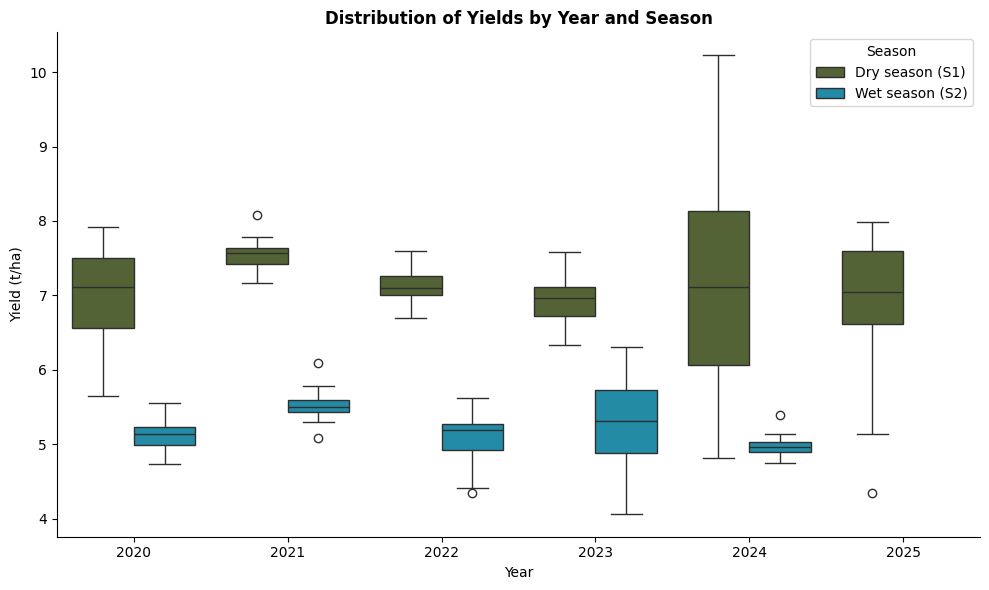

Saved figure: chapter4_refresh_outputs\fig_4_distribution_yields_by_year_season.png


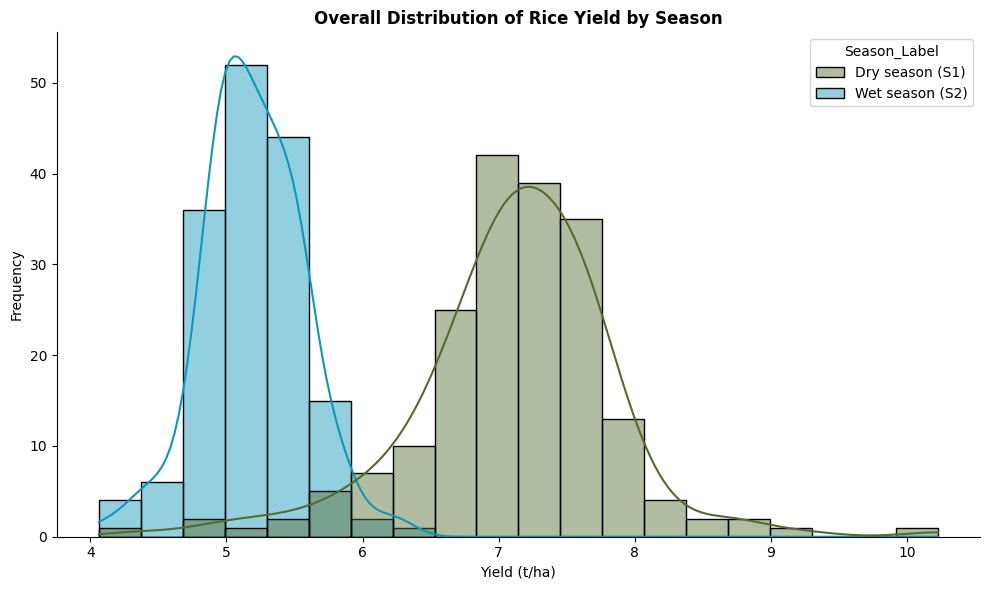

Saved figure: chapter4_refresh_outputs\Distribution_Histogram_KDE_Yield_by_Season.png


In [23]:
# ============================================================
# 5. YIELD DISTRIBUTION VISUALIZATIONS
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=long,
    x="Year",
    y="yield_t_ha",
    hue="Season",
    hue_order=[1, 2],
    palette={1: DRY_COLOR, 2: WET_COLOR},
    ax=ax
)

ax.set_title("Distribution of Yields by Year and Season", fontsize=12, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Yield (t/ha)")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ["Dry season (S1)", "Wet season (S2)"], title="Season")

style_axes(ax, grid=False)
save_fig(fig, "fig_4_distribution_yields_by_year_season.png")


fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=long,
    x="yield_t_ha",
    hue="Season_Label",
    hue_order=["Dry season (S1)", "Wet season (S2)"],
    palette={
        "Dry season (S1)": DRY_COLOR,
        "Wet season (S2)": WET_COLOR
    },
    bins=20,
    kde=True,
    alpha=0.45,
    ax=ax
)

ax.set_title("Overall Distribution of Rice Yield by Season", fontsize=12, fontweight="bold")
ax.set_xlabel("Yield (t/ha)")
ax.set_ylabel("Frequency")

style_axes(ax, grid=False)
save_fig(fig, "Distribution_Histogram_KDE_Yield_by_Season.png")

c:\Users\conch\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\conch\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


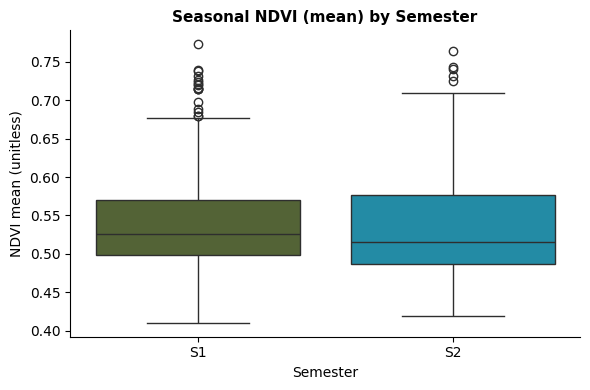

Saved figure: chapter4_refresh_outputs\fig_4_ndvi_mean_by_semester.png


c:\Users\conch\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\conch\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


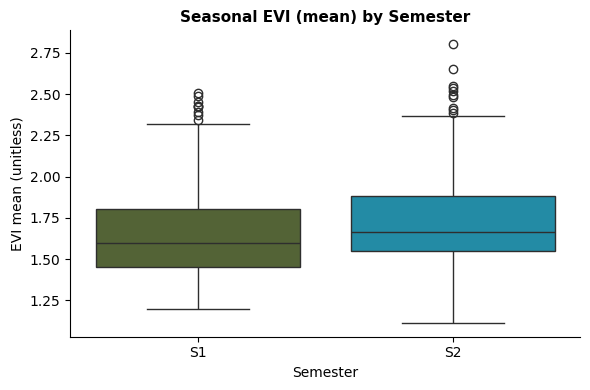

Saved figure: chapter4_refresh_outputs\fig_4_evi_mean_by_semester.png


c:\Users\conch\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\conch\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


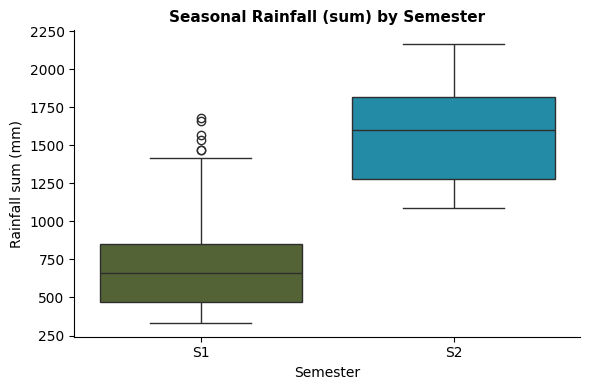

Saved figure: chapter4_refresh_outputs\fig_4_rainfall_sum_by_semester.png


c:\Users\conch\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\conch\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


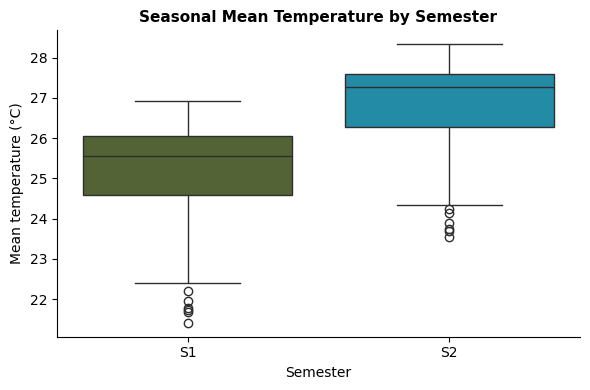

Saved figure: chapter4_refresh_outputs\fig_4_temperature_by_semester.png


c:\Users\conch\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\conch\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


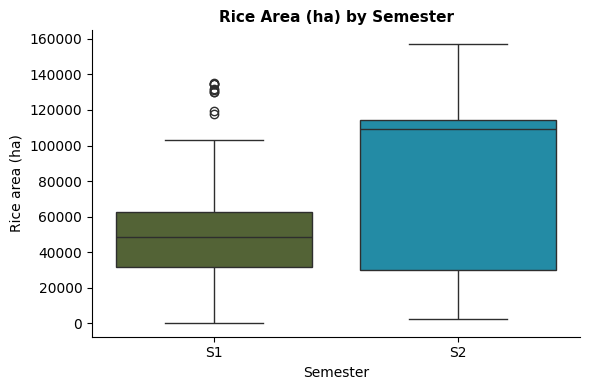

Saved figure: chapter4_refresh_outputs\fig_4_rice_area_by_semester.png


c:\Users\conch\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\conch\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


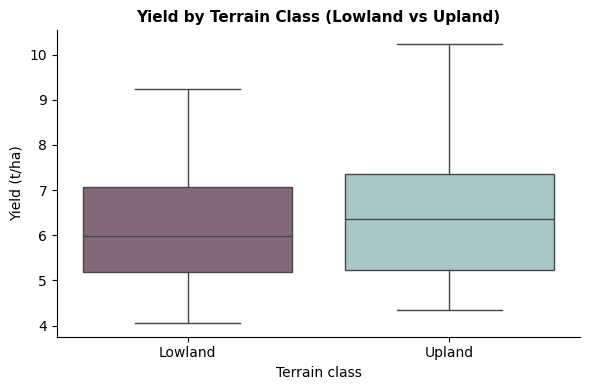

Saved figure: chapter4_refresh_outputs\fig_4_yield_by_terrain_class.png


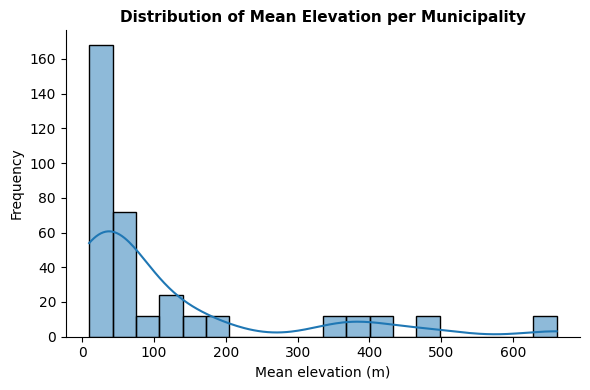

Saved figure: chapter4_refresh_outputs\fig_4_dtm_mean_distribution.png


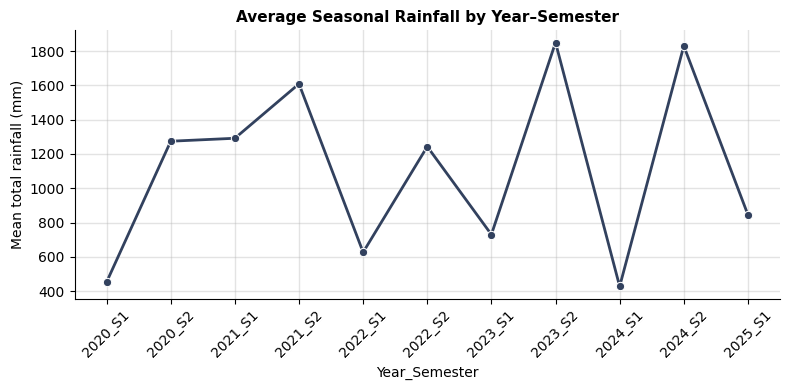

Saved figure: chapter4_refresh_outputs\fig_4_average_seasonal_rainfall.png


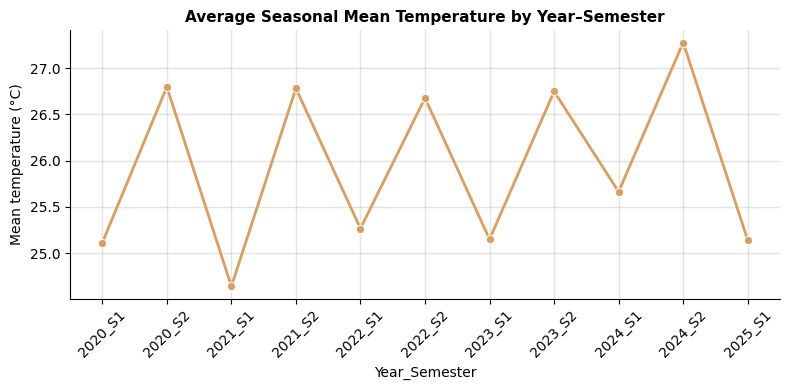

Saved figure: chapter4_refresh_outputs\fig_4_average_seasonal_temperature.png


In [24]:
# ============================================================
# 6. FEATURE DESCRIPTIVE VISUALIZATIONS
# Requires feat_df
# ============================================================

if "feat_df" in globals():
    desc_df = feat_df.copy()

    numeric_cols = [
        "NDVI_mean_season",
        "EVI_mean_season",
        "rain_season_sum",
        "tmean_season_mean",
        "rice_area_ha",
        "plant_month_majority",
        "dtm_mean"
    ]

    desc_df = clean_numeric(desc_df, numeric_cols)

    boxplot_specs = [
        (
            "NDVI_mean_season",
            "Seasonal NDVI (mean) by Semester",
            "NDVI mean (unitless)",
            "fig_4_ndvi_mean_by_semester.png"
        ),
        (
            "EVI_mean_season",
            "Seasonal EVI (mean) by Semester",
            "EVI mean (unitless)",
            "fig_4_evi_mean_by_semester.png"
        ),
        (
            "rain_season_sum",
            "Seasonal Rainfall (sum) by Semester",
            "Rainfall sum (mm)",
            "fig_4_rainfall_sum_by_semester.png"
        ),
        (
            "tmean_season_mean",
            "Seasonal Mean Temperature by Semester",
            "Mean temperature (°C)",
            "fig_4_temperature_by_semester.png"
        ),
        (
            "rice_area_ha",
            "Rice Area (ha) by Semester",
            "Rice area (ha)",
            "fig_4_rice_area_by_semester.png"
        )
    ]

    for y_col, title, ylabel, filename in boxplot_specs:
        if y_col in desc_df.columns:
            boxplot_by_semester(
                df=desc_df,
                y_col=y_col,
                title=title,
                ylabel=ylabel,
                filename=filename
            )

    # Terrain class plot
    if "dtm_mean" in desc_df.columns and TARGET_COL in desc_df.columns:
        median_elev = desc_df["dtm_mean"].median()

        desc_df["terrain_class"] = np.where(
            desc_df["dtm_mean"] <= median_elev,
            "Lowland",
            "Upland"
        )

        fig, ax = plt.subplots(figsize=(6, 4))

        sns.boxplot(
            data=desc_df,
            x="terrain_class",
            y=TARGET_COL,
            order=["Lowland", "Upland"],
            hue="terrain_class",
            palette={
                "Lowland": "#87657B",
                "Upland": "#A2CBD1"
            },
            legend=False,
            ax=ax
        )

        ax.set_title("Yield by Terrain Class (Lowland vs Upland)", fontsize=11, fontweight="bold")
        ax.set_xlabel("Terrain class")
        ax.set_ylabel("Yield (t/ha)")

        style_axes(ax, grid=False)
        save_fig(fig, "fig_4_yield_by_terrain_class.png")

        fig, ax = plt.subplots(figsize=(6, 4))

        sns.histplot(
            data=desc_df,
            x="dtm_mean",
            kde=True,
            bins=20,
            ax=ax
        )

        ax.set_title("Distribution of Mean Elevation per Municipality", fontsize=11, fontweight="bold")
        ax.set_xlabel("Mean elevation (m)")
        ax.set_ylabel("Frequency")

        style_axes(ax, grid=False)
        save_fig(fig, "fig_4_dtm_mean_distribution.png")

    # Climate line plots by year-semester
    climate_cols = ["rain_season_sum", "tmean_season_mean"]

    if all(col in desc_df.columns for col in ["Year", "Semester"] + climate_cols):
        clim_df = desc_df.copy()
        clim_df["season_id"] = (
            clim_df["Year"].astype(int).astype(str)
            + "_"
            + clim_df["Semester"].astype(str)
        )

        season_clim = (
            clim_df
            .groupby("season_id")
            .agg(
                rain_season_sum_mean=("rain_season_sum", "mean"),
                tmean_season_mean_mean=("tmean_season_mean", "mean")
            )
            .reset_index()
        )

        season_clim["Year"] = season_clim["season_id"].str.split("_").str[0].astype(int)
        season_clim["Semester"] = season_clim["season_id"].str.split("_").str[1]
        season_clim["SemOrder"] = season_clim["Semester"].map({"S1": 1, "S2": 2})
        season_clim = season_clim.sort_values(["Year", "SemOrder"])

        lineplot_by_season(
            df=season_clim,
            x_col="season_id",
            y_col="rain_season_sum_mean",
            title="Average Seasonal Rainfall by Year–Semester",
            ylabel="Mean total rainfall (mm)",
            color="#32415E",
            filename="fig_4_average_seasonal_rainfall.png"
        )

        lineplot_by_season(
            df=season_clim,
            x_col="season_id",
            y_col="tmean_season_mean_mean",
            title="Average Seasonal Mean Temperature by Year–Semester",
            ylabel="Mean temperature (°C)",
            color="#DA9F5F",
            filename="fig_4_average_seasonal_temperature.png"
        )

else:
    print("[WARN] feat_df not found. Skipping feature descriptive visualizations.")

,Rank,Predictor,Original_Column,Correlation_with_Yield_r,Direction,Strength
0,1,Dewpoint,dewpoint_season_mean,-0.712022,Negative,Strong
1,2,Min temperature (°C),tmin_season_mean,-0.690818,Negative,Moderate to strong
2,3,"Rain (season total, mm)",rain_season_sum,-0.656423,Negative,Moderate to strong
3,4,Wind speed (m/s),wind_season_mean,0.592386,Positive,Moderate to strong
4,5,Mean temperature (°C),tmean_season_mean,-0.569436,Negative,Moderate to strong
5,6,LST day mean (°C),lst_day_mean_season,-0.497983,Negative,Moderate
6,7,LST day max (°C),lst_day_max_season,-0.459562,Negative,Moderate
7,8,Max temperature (°C),tmax_season_mean,-0.442865,Negative,Moderate
8,9,LST day min (°C),lst_day_min_season,-0.360479,Negative,Moderate
9,10,"ET (season total, mm)",et_season_sum,0.338788,Positive,Moderate


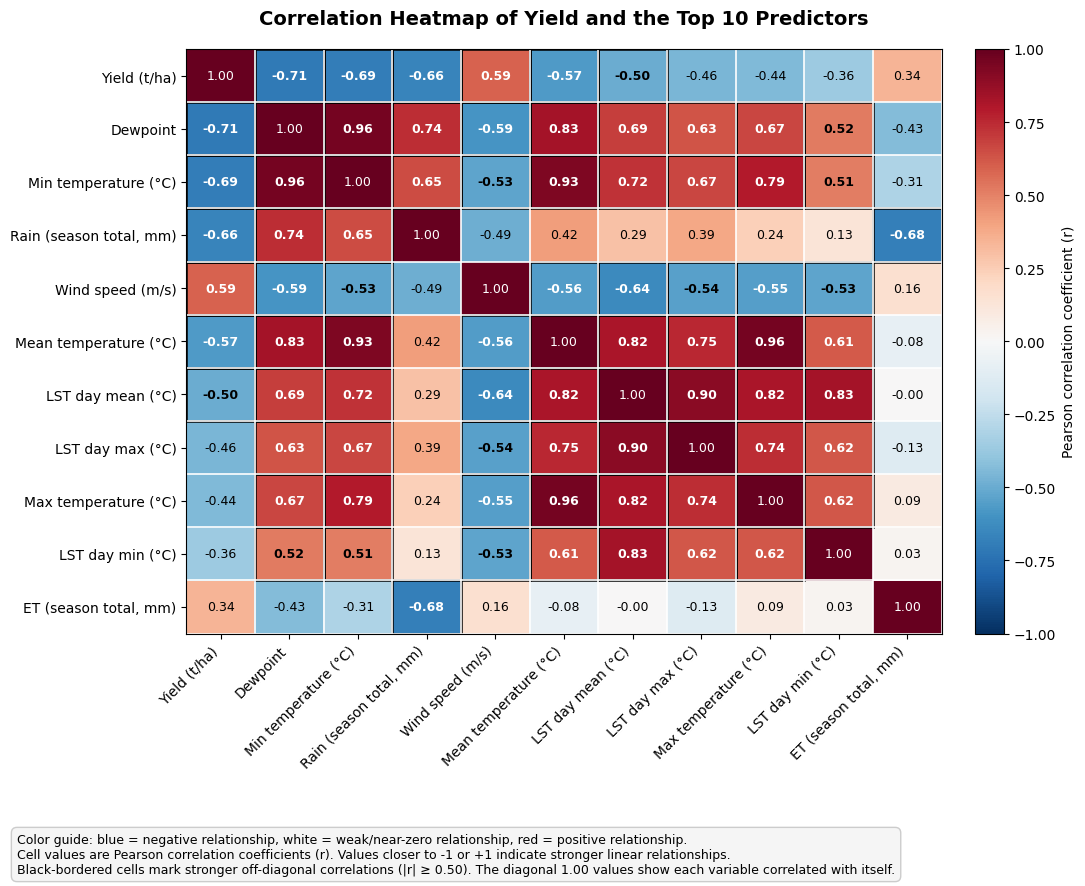

Saved figure: chapter4_refresh_outputs\fig_4_16_correlation_heatmap_clear.png
Saved table: chapter4_refresh_outputs\fig_4_16_top10_yield_correlations.csv


In [25]:
# ============================================================
# 7. CORRELATION HEATMAP OF YIELD AND TOP 10 PREDICTORS
# ============================================================

if "model_df" in globals():
    corr_source_df = model_df.copy()
elif "observed_df" in globals():
    corr_source_df = observed_df.copy()
elif "master_df" in globals():
    corr_source_df = master_df.dropna(subset=[TARGET_COL]).copy()
else:
    corr_source_df = None
    print("[WARN] No suitable dataframe found for correlation analysis.")

if corr_source_df is not None:
    if TARGET_COL not in corr_source_df.columns:
        raise ValueError(f"{TARGET_COL} not found in selected dataframe.")

    if "TREE_FEATURES" in globals():
        candidate_features = [
            col for col in TREE_FEATURES
            if col in corr_source_df.columns
        ]
    else:
        candidate_features = [
            col for col in corr_source_df.columns
            if pd.api.types.is_numeric_dtype(corr_source_df[col])
            and col not in ["Year", "Semester_num", TARGET_COL]
        ]

    candidate_features = [
        col for col in candidate_features
        if pd.api.types.is_numeric_dtype(corr_source_df[col])
    ]

    corr_df = corr_source_df[[TARGET_COL] + candidate_features].copy()

    valid_cols = [
        col for col in corr_df.columns
        if corr_df[col].nunique(dropna=True) > 1
    ]

    corr_df = corr_df[valid_cols]

    if TARGET_COL not in corr_df.columns:
        raise ValueError(f"{TARGET_COL} was removed due to missing or constant values.")

    corr = corr_df.corr(numeric_only=True, method="pearson")

    top10 = (
        corr[TARGET_COL]
        .drop(index=[TARGET_COL], errors="ignore")
        .dropna()
        .abs()
        .sort_values(ascending=False)
        .head(10)
        .index
        .tolist()
    )

    cols = [TARGET_COL] + top10
    corr_top = corr.loc[cols, cols].round(2)
    labels = [PRETTY_LABELS.get(col, col) for col in cols]

    top10_table = pd.DataFrame({
        "Rank": range(1, len(top10) + 1),
        "Predictor": [PRETTY_LABELS.get(col, col) for col in top10],
        "Original_Column": top10,
        "Correlation_with_Yield_r": [corr.loc[TARGET_COL, col] for col in top10]
    })

    top10_table["Direction"] = np.where(
        top10_table["Correlation_with_Yield_r"] > 0,
        "Positive",
        "Negative"
    )

    top10_table["Strength"] = top10_table["Correlation_with_Yield_r"].apply(strength_label)

    table_path = os.path.join(OUTDIR, "fig_4_16_top10_yield_correlations.csv")
    top10_table.to_csv(table_path, index=False)

    display(top10_table)

    # Heatmap
    fig, ax = plt.subplots(figsize=(11, 9))

    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    im = ax.imshow(
        corr_top.values,
        cmap="RdBu_r",
        norm=norm,
        aspect="auto"
    )

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(labels, fontsize=10)

    ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    vals = corr_top.values

    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            v = vals[i, j]
            is_diagonal = i == j
            is_strong = abs(v) >= 0.50 and not is_diagonal

            ax.text(
                j,
                i,
                f"{v:.2f}",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold" if is_strong else "normal",
                color="white" if abs(v) >= 0.55 else "black"
            )

            if is_strong:
                ax.add_patch(
                    Rectangle(
                        (j - 0.5, i - 0.5),
                        1,
                        1,
                        fill=False,
                        edgecolor="black",
                        linewidth=1.8
                    )
                )

    ax.set_title(
        "Correlation Heatmap of Yield and the Top 10 Predictors",
        fontsize=14,
        pad=18,
        fontweight="bold"
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Pearson correlation coefficient (r)", fontsize=10)
    cbar.set_ticks([-1.00, -0.75, -0.50, -0.25, 0.00, 0.25, 0.50, 0.75, 1.00])

    note = (
        "Color guide: blue = negative relationship, white = weak/near-zero relationship, red = positive relationship.\n"
        "Cell values are Pearson correlation coefficients (r). Values closer to -1 or +1 indicate stronger linear relationships.\n"
        "Black-bordered cells mark stronger off-diagonal correlations (|r| ≥ 0.50). The diagonal 1.00 values show each variable correlated with itself."
    )

    fig.text(
        0.02,
        0.02,
        note,
        ha="left",
        va="bottom",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor="#f5f5f5",
            edgecolor="#cccccc"
        )
    )

    plt.tight_layout(rect=[0, 0.12, 1, 1])

    heatmap_path = os.path.join(OUTDIR, "fig_4_16_correlation_heatmap_clear.png")
    fig.savefig(heatmap_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved figure: {heatmap_path}")
    print(f"Saved table: {table_path}")

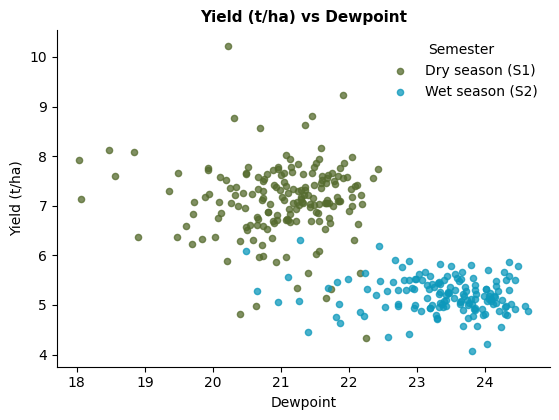

Saved figure: chapter4_refresh_outputs\fig_4_scatter_yield_vs_dewpoint_season_mean.png


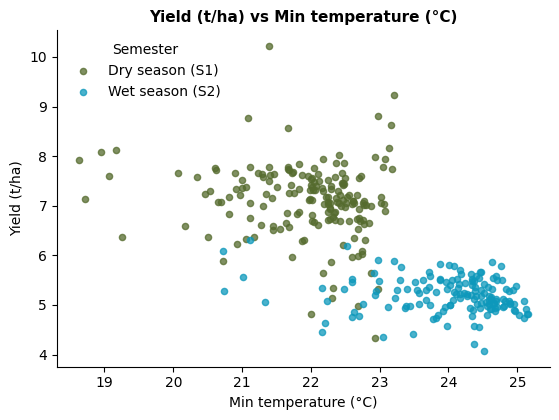

Saved figure: chapter4_refresh_outputs\fig_4_scatter_yield_vs_tmin_season_mean.png


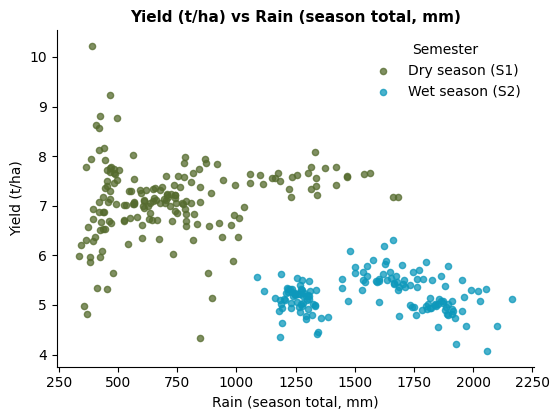

Saved figure: chapter4_refresh_outputs\fig_4_scatter_yield_vs_rain_season_sum.png


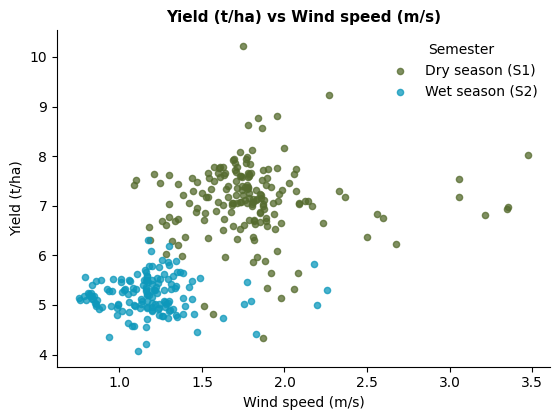

Saved figure: chapter4_refresh_outputs\fig_4_scatter_yield_vs_wind_season_mean.png


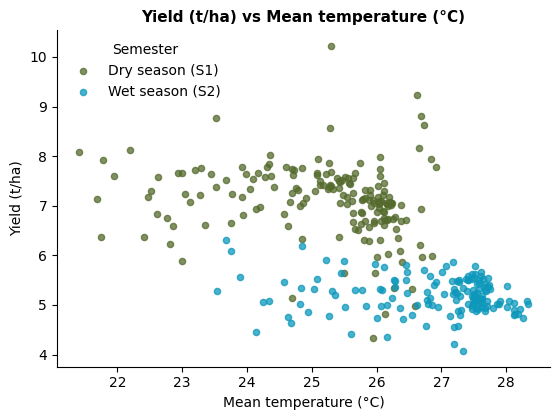

Saved figure: chapter4_refresh_outputs\fig_4_scatter_yield_vs_tmean_season_mean.png


In [26]:
# ============================================================
# 8. SCATTER PLOTS: YIELD VS TOP PREDICTORS
# ============================================================

if "model_df" in globals():
    eda_df = model_df.copy()

    if "feature_cols" in globals():
        predictor_cols = feature_cols.copy()
    elif "TREE_FEATURES" in globals():
        predictor_cols = TREE_FEATURES.copy()
    else:
        predictor_cols = [
            col for col in eda_df.columns
            if pd.api.types.is_numeric_dtype(eda_df[col])
            and col not in [TARGET_COL, "Year", "Semester_num"]
        ]

    keep_cols = [
        TARGET_COL
    ] + [
        col for col in predictor_cols
        if col in eda_df.columns
    ]

    num_df = eda_df[keep_cols].apply(pd.to_numeric, errors="coerce")

    corr = num_df.corr(numeric_only=True)

    corr_with_yield = (
        corr[TARGET_COL]
        .drop(index=[TARGET_COL], errors="ignore")
        .dropna()
        .to_frame(name="corr_with_yield")
    )

    corr_with_yield["abs_corr"] = corr_with_yield["corr_with_yield"].abs()
    corr_with_yield = corr_with_yield.sort_values("abs_corr", ascending=False)

    top_k = min(5, len(corr_with_yield))
    top_predictors = corr_with_yield.head(top_k).index.tolist()

    has_sem = "Semester" in eda_df.columns
    sem_series = eda_df["Semester"] if has_sem else None

    for x_col in top_predictors:
        plot_df = num_df[[TARGET_COL, x_col]].dropna()

        fig, ax = plt.subplots(figsize=(5.7, 4.3))

        if has_sem:
            sem = sem_series.loc[plot_df.index]
            sem_vals = [s for s in ["S1", "S2", 1, 2, "1", "2"] if s in set(sem.dropna().unique())]

            if not sem_vals:
                sem_vals = list(pd.unique(sem.dropna()))

            for s in sem_vals:
                mask = sem == s

                ax.scatter(
                    plot_df.loc[mask, x_col],
                    plot_df.loc[mask, TARGET_COL],
                    s=20,
                    alpha=0.75,
                    c=SEM_PALETTE.get(s, SEM_PALETTE.get(str(s), None)),
                    label=SEM_LABELS.get(s, str(s))
                )

            ax.legend(title="Semester", frameon=False, loc="best")

        else:
            ax.scatter(
                plot_df[x_col],
                plot_df[TARGET_COL],
                s=20,
                alpha=0.75,
                color=GREEN_COLOR
            )

        ax.set_title(
            f"{PRETTY_LABELS.get(TARGET_COL, TARGET_COL)} vs {PRETTY_LABELS.get(x_col, x_col)}",
            fontsize=11,
            fontweight="bold"
        )

        ax.set_xlabel(PRETTY_LABELS.get(x_col, x_col))
        ax.set_ylabel(PRETTY_LABELS.get(TARGET_COL, TARGET_COL))

        style_axes(ax, grid=False)

        filename = f"fig_4_scatter_yield_vs_{x_col}.png"
        save_fig(fig, filename)

else:
    print("[WARN] model_df not found. Skipping scatter plots.")

In [27]:
# -----------------------------
# 1) Global settings
# -----------------------------

POINT_COLOR = "#617129"       # green
LINE_COLOR = "#FA8334"        # orange
GRID_COLOR = "#d9d9d9"

CH4_REFRESH_OUTDIR = "chapter4_refresh_outputs"
FINAL_SPEC_OUTDIR = "chapter4_final_model_spec"
ALL_MODEL_OUTDIR = "chapter4_all_model_equation_outputs"

os.makedirs(CH4_REFRESH_OUTDIR, exist_ok=True)
os.makedirs(FINAL_SPEC_OUTDIR, exist_ok=True)
os.makedirs(ALL_MODEL_OUTDIR, exist_ok=True)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.weight": "normal",
    "axes.titlesize": 11,
    "axes.titleweight": "normal",
    "axes.labelsize": 9,
    "axes.labelweight": "normal",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.titlesize": 14
})

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


# -----------------------------
# 2) General helper functions
# -----------------------------

def show_fig(fig):
    """
    Display figure only.
    No image file is saved.
    """
    plt.show()
    print("Figure shown only. No image saved.")


def save_text(outdir, filename, text):
    """
    Save plain text output.
    """
    path = os.path.join(outdir, filename)
    with open(path, "w", encoding="utf-8") as f:
        f.write(text)
    print(f"Saved: {path}")


def safe_display(obj, title=None):
    """
    Display object safely in notebook.
    """
    if title:
        print("\n" + title)
        print("-" * len(title))

    try:
        display(obj)
    except Exception:
        print(obj)


def style_axes(ax, grid=True, grid_axis="both", grid_style="--"):
    """
    Apply consistent grid and spine styling.
    """
    if grid:
        ax.grid(
            True,
            axis=grid_axis,
            linestyle=grid_style,
            linewidth=0.6 if grid_style == "--" else 1.0,
            alpha=0.35,
            color=GRID_COLOR if grid_style == "--" else "#b0b0b0"
        )
        ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def p_text(p):
    """
    Format p-values for plot labels.
    """
    if pd.isna(p):
        return "p = NA"
    if p < 0.001:
        return "p < 0.001"
    return f"p = {p:.3f}"


def to_dense(X):
    """
    Convert sparse matrix to dense array if needed.
    """
    if hasattr(X, "toarray"):
        return X.toarray()
    return np.asarray(X)


def format_plus_minus(value):
    """
    Format coefficient sign for equation text.
    """
    value = float(value)
    return f"+ {abs(value):.6f}" if value >= 0 else f"- {abs(value):.6f}"


def get_final_estimator(pipe):
    """
    Return final estimator from fitted sklearn Pipeline, or the object itself.
    """
    if hasattr(pipe, "named_steps"):
        if "model" in pipe.named_steps:
            return pipe.named_steps["model"]
        return list(pipe.named_steps.values())[-1]

    return pipe


def get_preprocessor(pipe):
    """
    Return preprocessing step from pipeline if available.
    """
    if hasattr(pipe, "named_steps") and "prep" in pipe.named_steps:
        return pipe.named_steps["prep"]

    return None


def manual_feature_names_from_preprocessor(prep):
    """
    Extract transformed feature names manually.
    This handles custom steps such as MonthCyclicEncoder.
    """
    names = []

    if prep is None:
        return names

    try:
        return list(prep.get_feature_names_out())
    except Exception:
        pass

    try:
        for name, transformer, cols in prep.transformers_:
            if name == "remainder" or transformer == "drop":
                continue

            if isinstance(cols, slice):
                continue

            cols_list = list(cols) if isinstance(cols, (list, tuple, np.ndarray, pd.Index)) else [cols]

            if name in ["num", "month"]:
                names.extend(cols_list)

            elif name == "month_cyc":
                base = cols_list[0] if len(cols_list) > 0 else "plant_month"
                names.extend([f"{base}_sin", f"{base}_cos"])

            else:
                names.extend(cols_list)

    except Exception as e:
        print(f"[WARN] Could not manually extract feature names: {e}")

    return names


def transformed_matrix_and_names(pipe, X_raw):
    """
    Transform raw input and return transformed matrix plus feature names.
    """
    prep = get_preprocessor(pipe)

    if prep is None:
        return to_dense(X_raw), list(X_raw.columns)

    try:
        Xt = prep.transform(X_raw)
        Xt = to_dense(Xt)
    except Exception as e:
        print(f"[WARN] Could not transform input: {e}")
        return None, []

    names = manual_feature_names_from_preprocessor(prep)

    if len(names) != Xt.shape[1]:
        names = [f"x{j}" for j in range(Xt.shape[1])]

    return Xt, names


def replace_xgb_feature_tokens(dump_text, feature_names):
    """
    Replace XGBoost f0, f1, f2 tokens with actual transformed feature names.
    """
    out = dump_text

    for i, name in enumerate(feature_names):
        out = re.sub(rf"\bf{i}\b", name, out)

    return out


def add_fit_line(ax, x, y):
    """
    Add orange dashed trend line to scatter plot.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    ok = np.isfinite(x) & np.isfinite(y)

    if ok.sum() < 2:
        return

    if len(np.unique(x[ok])) < 2:
        return

    slope, intercept = np.polyfit(x[ok], y[ok], 1)
    xs = np.linspace(x[ok].min(), x[ok].max(), 100)
    ys = slope * xs + intercept

    ax.plot(
        xs,
        ys,
        color=LINE_COLOR,
        linestyle="--",
        linewidth=2.6,
        alpha=0.95,
        zorder=3
    )


H1 partial Spearman summary:


,variable,n,rho_partial_spearman,p_value
0,tmean_season_mean,330,-0.247069,0.000006
1,vpd_season_mean,330,-0.245425,0.000006
2,NDVI_max_season,330,0.135819,0.013535
3,EVI_max_season,330,0.134631,0.014383
4,rain_season_sum,330,0.109506,0.046844
5,lst_day_mean_season,330,-0.100168,0.069169
6,EVI_mean_season,330,0.070297,0.202757
7,NDVI_mean_season,330,0.014244,0.796576


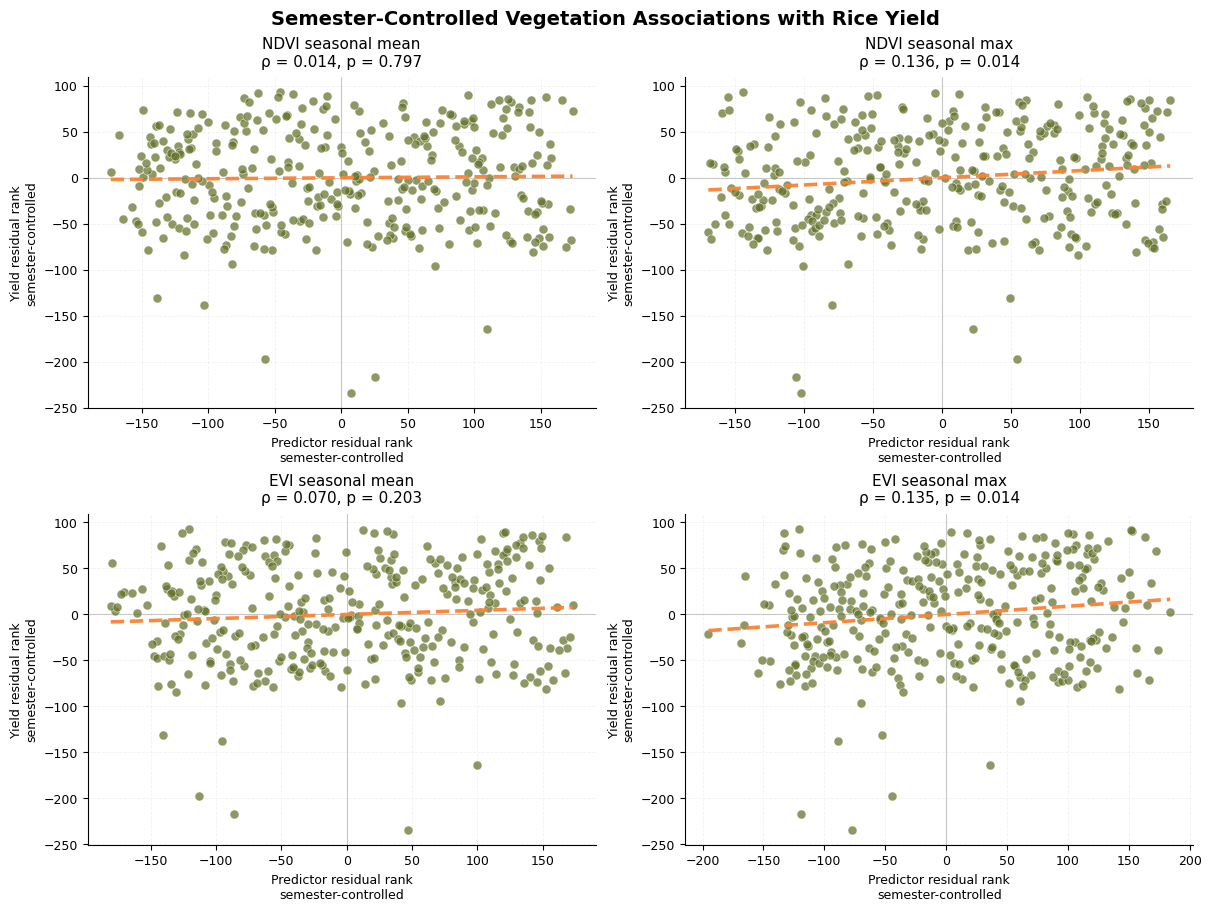

Figure shown only. No image saved.


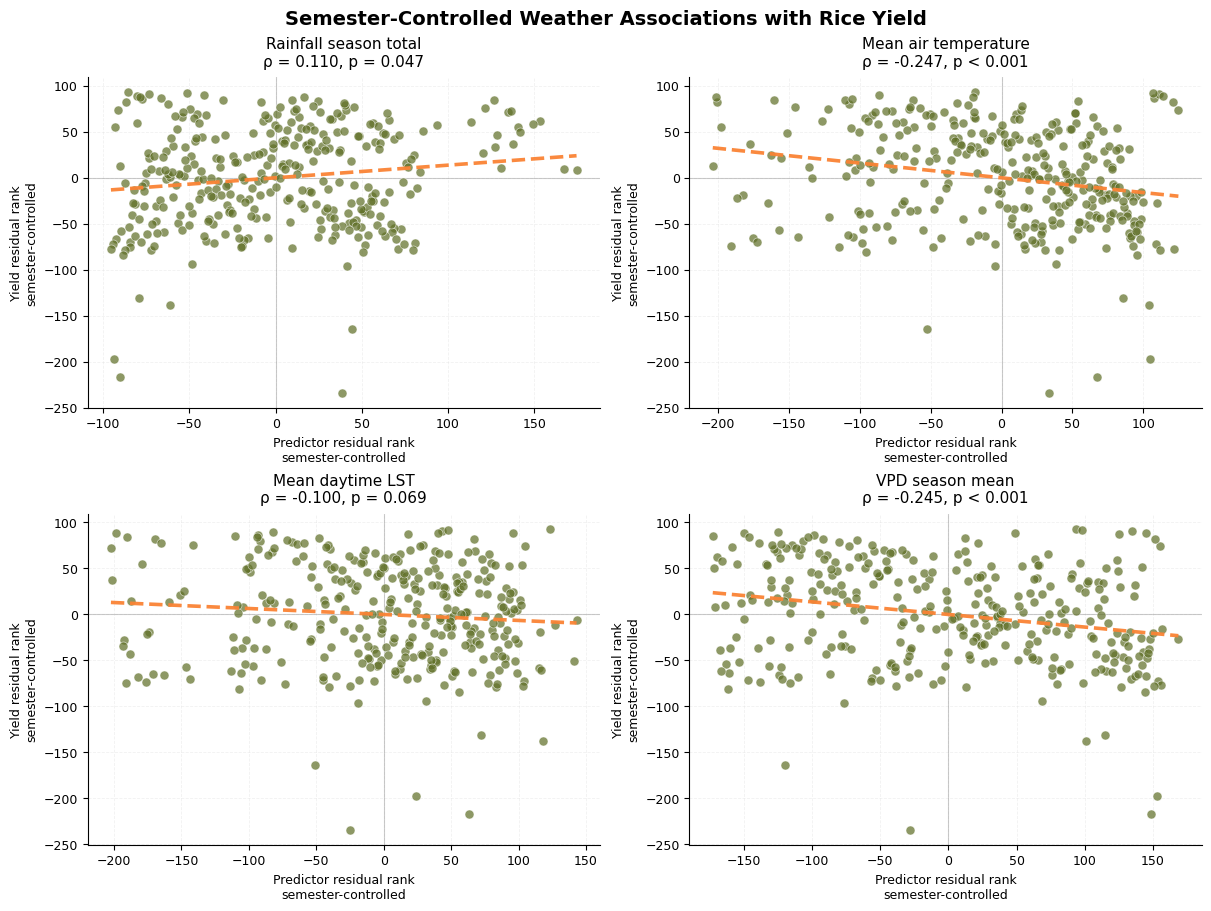

Figure shown only. No image saved.

Reader-friendly H1 table:


,Predictor,n,Partial_Spearman_rho,p_value
0,Mean air temperature,330,-0.247069,0.000006
1,VPD season mean,330,-0.245425,0.000006
2,NDVI seasonal max,330,0.135819,0.013535
3,EVI seasonal max,330,0.134631,0.014383
4,Rainfall season total,330,0.109506,0.046844
5,Mean daytime LST,330,-0.100168,0.069169
6,EVI seasonal mean,330,0.070297,0.202757
7,NDVI seasonal mean,330,0.014244,0.796576


In [28]:
# ============================================================
# PART A: CHAPTER 4 REFRESH OUTPUTS
# ============================================================

# -----------------------------
# 3) Prepare modeling dataframe
# -----------------------------

if "model_df" not in globals():
    if "master_df" in globals():
        model_df = master_df.dropna(subset=["Yield_t_ha"]).copy()
    else:
        raise RuntimeError("model_df not found. Run the earlier data integration/modeling cells first.")

df = model_df.copy()

required_cols = ["Yield_t_ha", "Semester"]
missing_req = [c for c in required_cols if c not in df.columns]

if missing_req:
    raise RuntimeError(f"Missing required columns in model_df: {missing_req}")


# -----------------------------
# 4) Partial Spearman helper
# Controls for Semester using residualized ranked variables
# -----------------------------

def partial_spearman_control_semester(data, x_col, y_col="Yield_t_ha", control_col="Semester"):
    tmp = data[[x_col, y_col, control_col]].dropna().copy()

    if len(tmp) < 8:
        return None

    x_rank = tmp[x_col].rank(method="average").astype(float).values
    y_rank = tmp[y_col].rank(method="average").astype(float).values

    dummies = pd.get_dummies(tmp[control_col].astype(str), drop_first=True)
    Xc = dummies.values.astype(float)

    def residualize(vec):
        if Xc.shape[1] == 0:
            return vec - np.mean(vec)

        lr = LinearRegression()
        lr.fit(Xc, vec)
        return vec - lr.predict(Xc)

    x_resid = residualize(x_rank)
    y_resid = residualize(y_rank)

    rho, pval = stats.spearmanr(x_resid, y_resid)

    out = tmp.copy()
    out["x_resid"] = x_resid
    out["y_resid"] = y_resid

    return {
        "variable": x_col,
        "n": len(tmp),
        "rho_partial_spearman": rho,
        "p_value": pval,
        "plot_df": out
    }


# -----------------------------
# 5) H1 variables and labels
# -----------------------------

veg_vars = [
    "NDVI_mean_season",
    "NDVI_max_season",
    "EVI_mean_season",
    "EVI_max_season"
]

weather_vars = [
    "rain_season_sum",
    "tmean_season_mean",
    "lst_day_mean_season",
    "vpd_season_mean"
]

veg_vars = [v for v in veg_vars if v in df.columns]
weather_vars = [v for v in weather_vars if v in df.columns]

label_map = {
    "NDVI_mean_season": "NDVI seasonal mean",
    "NDVI_max_season": "NDVI seasonal max",
    "EVI_mean_season": "EVI seasonal mean",
    "EVI_max_season": "EVI seasonal max",
    "rain_season_sum": "Rainfall season total",
    "tmean_season_mean": "Mean air temperature",
    "lst_day_mean_season": "Mean daytime LST",
    "vpd_season_mean": "VPD season mean"
}


# -----------------------------
# 6) H1 partial Spearman summary
# -----------------------------

assoc_results = []

for v in veg_vars + weather_vars:
    res = partial_spearman_control_semester(df, v)

    if res is not None:
        assoc_results.append({
            "variable": res["variable"],
            "n": res["n"],
            "rho_partial_spearman": res["rho_partial_spearman"],
            "p_value": res["p_value"]
        })

assoc_results_df = pd.DataFrame(assoc_results)

if len(assoc_results_df) > 0:
    assoc_results_df = (
        assoc_results_df
        .sort_values(["p_value", "rho_partial_spearman"], ascending=[True, False])
        .reset_index(drop=True)
    )

print("\nH1 partial Spearman summary:")
display(assoc_results_df)


# -----------------------------
# 7) H1 plotting function
# -----------------------------

def plot_partial_association_grid(variables, figure_title, nrows=2, ncols=2):
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(12, 9),
        constrained_layout=True
    )

    axes = axes.flatten()

    for ax, var in zip(axes, variables):
        res = partial_spearman_control_semester(df, var)

        if res is None:
            ax.axis("off")
            continue

        plot_df = res["plot_df"]
        x = plot_df["x_resid"]
        y = plot_df["y_resid"]

        ax.scatter(
            x,
            y,
            s=42,
            color=POINT_COLOR,
            alpha=0.72,
            edgecolor="white",
            linewidth=0.45,
            zorder=2
        )

        add_fit_line(ax, x, y)

        ax.axhline(
            0,
            color="gray",
            linestyle="-",
            linewidth=0.8,
            alpha=0.40,
            zorder=1
        )

        ax.axvline(
            0,
            color="gray",
            linestyle="-",
            linewidth=0.8,
            alpha=0.40,
            zorder=1
        )

        readable_label = label_map.get(var, var)

        ax.set_title(
            f"{readable_label}\nρ = {res['rho_partial_spearman']:.3f}, {p_text(res['p_value'])}",
            fontweight="normal",
            pad=8
        )

        ax.set_xlabel("Predictor residual rank\nsemester-controlled", fontweight="normal")
        ax.set_ylabel("Yield residual rank\nsemester-controlled", fontweight="normal")

        style_axes(ax, grid=True, grid_axis="both", grid_style="--")

    for j in range(len(variables), len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        figure_title,
        fontweight="bold"
    )

    show_fig(fig)


# -----------------------------
# 8) H1 Figures
# -----------------------------

if len(veg_vars) > 0:
    plot_partial_association_grid(
        variables=veg_vars,
        figure_title="Semester-Controlled Vegetation Associations with Rice Yield"
    )

if len(weather_vars) > 0:
    plot_partial_association_grid(
        variables=weather_vars,
        figure_title="Semester-Controlled Weather Associations with Rice Yield"
    )


# -----------------------------
# 9) Reader-friendly H1 table
# -----------------------------

if len(assoc_results_df) > 0:
    assoc_pretty_df = assoc_results_df.copy()

    assoc_pretty_df["Predictor"] = (
        assoc_pretty_df["variable"]
        .map(label_map)
        .fillna(assoc_pretty_df["variable"])
    )

    assoc_pretty_df = assoc_pretty_df[
        ["Predictor", "n", "rho_partial_spearman", "p_value"]
    ]

    assoc_pretty_df.columns = [
        "Predictor",
        "n",
        "Partial_Spearman_rho",
        "p_value"
    ]

    print("\nReader-friendly H1 table:")
    display(assoc_pretty_df)


H2 comparison summary:


,Model,RMSE,MAE,R2,Group
0,Baseline_MuniSemesterMean,0.669706,0.481896,0.656494,Baseline
1,RandomForest,0.730667,0.551407,0.591111,Machine learning
2,XGBoost,0.743698,0.544948,0.576397,Machine learning
3,GradientBoosting,0.772201,0.576007,0.543304,Machine learning
4,LinearRegression,0.778795,0.575205,0.535472,Machine learning
5,KNeighbors,0.835187,0.639237,0.465763,Machine learning
6,MLPRegressor,0.898812,0.621897,0.381267,Machine learning
7,Baseline_GlobalMean,1.199183,1.115093,-0.101378,Baseline
8,Baseline_MuniMean,1.222524,1.123712,-0.144672,Baseline


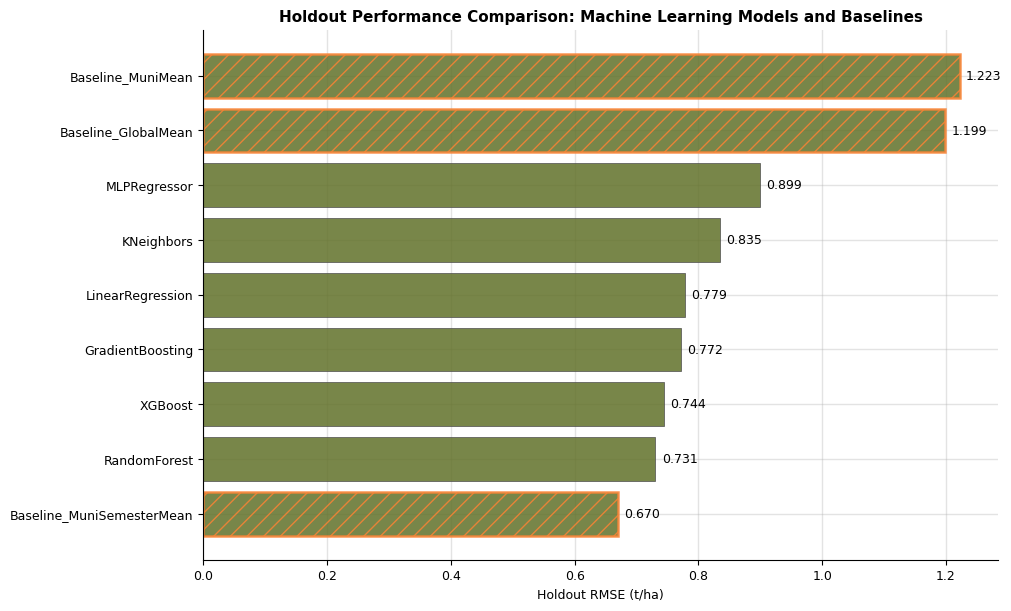

Figure shown only. No image saved.


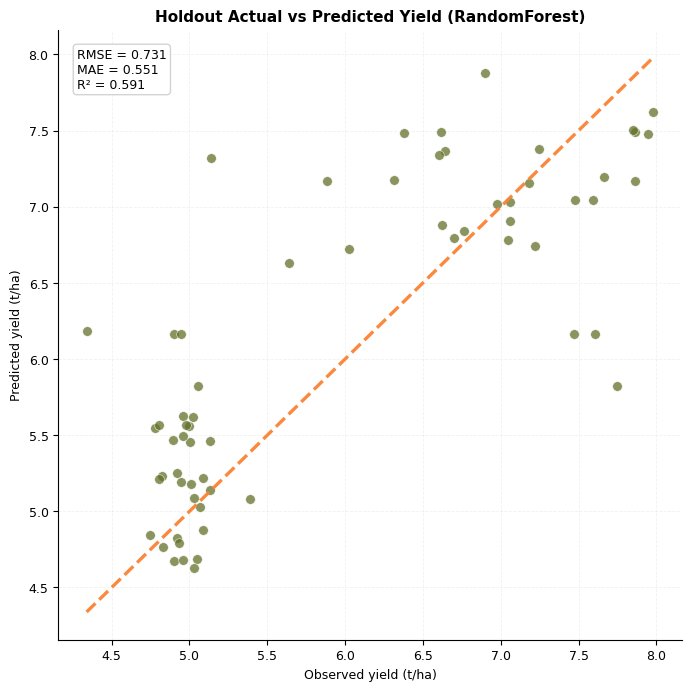

Figure shown only. No image saved.


In [29]:
# -----------------------------
# 10) H2 comparison table
# -----------------------------

h2_ready = (
    "holdout_results_df" in globals()
    and "baseline_overall_df" in globals()
)

if h2_ready:
    ml_holdout_df = holdout_results_df.copy()
    ml_holdout_df["Group"] = "Machine learning"

    baseline_df = baseline_overall_df.copy()
    baseline_df["Group"] = "Baseline"

    h2_compare_df = pd.concat(
        [
            ml_holdout_df[["Model", "RMSE", "MAE", "R2", "Group"]],
            baseline_df[["Model", "RMSE", "MAE", "R2", "Group"]]
        ],
        ignore_index=True
    )

    h2_compare_df = (
        h2_compare_df
        .sort_values(["RMSE", "R2"], ascending=[True, False])
        .reset_index(drop=True)
    )

    print("\nH2 comparison summary:")
    display(h2_compare_df)


# -----------------------------
# 11) H2 Figure: ML models and baselines
# -----------------------------

if h2_ready:
    plot_df = h2_compare_df.sort_values("RMSE", ascending=True).copy()

    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

    ypos = np.arange(len(plot_df))

    bars = ax.barh(
        ypos,
        plot_df["RMSE"],
        color=POINT_COLOR,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.6
    )

    ax.set_yticks(ypos)
    ax.set_yticklabels(plot_df["Model"], fontweight="normal")
    ax.set_xlabel("Holdout RMSE (t/ha)", fontweight="normal")

    ax.set_title(
        "Holdout Performance Comparison: Machine Learning Models and Baselines",
        fontweight="bold"
    )

    for i, (_, row) in enumerate(plot_df.iterrows()):
        ax.text(
            row["RMSE"] + 0.01,
            i,
            f"{row['RMSE']:.3f}",
            va="center",
            fontsize=9,
            fontweight="normal"
        )

    for bar, grp in zip(bars, plot_df["Group"]):
        if grp == "Baseline":
            bar.set_hatch("//")
            bar.set_edgecolor(LINE_COLOR)
            bar.set_linewidth(1.8)
        else:
            bar.set_edgecolor("#4F4F4F")
            bar.set_linewidth(0.6)

    style_axes(ax, grid=True, grid_axis="both", grid_style="-")

    show_fig(fig)


# -----------------------------
# 12) Deployment actual vs predicted figure
# -----------------------------

deployment_ready = (
    "holdout_preds_long_df" in globals()
    and "holdout_results_df" in globals()
)

dep_pred_df = pd.DataFrame()

if deployment_ready:
    if "deployment_model_name" not in globals():
        deployment_model_name = (
            holdout_results_df
            .sort_values(["RMSE", "R2"], ascending=[True, False])
            .iloc[0]["Model"]
        )

    dep_pred_df = holdout_preds_long_df.loc[
        holdout_preds_long_df["Model"] == deployment_model_name
    ].copy()

    if len(dep_pred_df) > 0:
        dep_metrics = holdout_results_df.loc[
            holdout_results_df["Model"] == deployment_model_name
        ].iloc[0]

        xy_min = min(
            dep_pred_df["Yield_t_ha"].min(),
            dep_pred_df["Prediction"].min()
        )

        xy_max = max(
            dep_pred_df["Yield_t_ha"].max(),
            dep_pred_df["Prediction"].max()
        )

        fig, ax = plt.subplots(figsize=(6.8, 6.8), constrained_layout=True)

        ax.scatter(
            dep_pred_df["Yield_t_ha"],
            dep_pred_df["Prediction"],
            s=48,
            color=POINT_COLOR,
            alpha=0.75,
            edgecolor="white",
            linewidth=0.45,
            zorder=2
        )

        ax.plot(
            [xy_min, xy_max],
            [xy_min, xy_max],
            color=LINE_COLOR,
            linestyle="--",
            linewidth=2.4,
            alpha=0.95,
            zorder=3
        )

        ax.set_xlabel("Observed yield (t/ha)", fontweight="normal")
        ax.set_ylabel("Predicted yield (t/ha)", fontweight="normal")

        ax.set_title(
            f"Holdout Actual vs Predicted Yield ({deployment_model_name})",
            fontweight="bold"
        )

        metrics_text = (
            f"RMSE = {dep_metrics['RMSE']:.3f}\n"
            f"MAE = {dep_metrics['MAE']:.3f}\n"
            f"R² = {dep_metrics['R2']:.3f}"
        )

        ax.text(
            0.03,
            0.97,
            metrics_text,
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=9,
            fontweight="normal",
            bbox=dict(
                boxstyle="round",
                facecolor="white",
                alpha=0.85,
                edgecolor="#cccccc"
            )
        )

        style_axes(ax, grid=True, grid_axis="both", grid_style="--")

        show_fig(fig)


In [30]:
# -----------------------------
# 13) Season-specific reliability table
# -----------------------------

if deployment_ready and "season_id" in holdout_preds_long_df.columns and len(dep_pred_df) > 0:
    dep_by_season_rows = []

    for season_id, grp in dep_pred_df.groupby("season_id"):
        y_true = grp["Yield_t_ha"].values
        y_pred = grp["Prediction"].values

        rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
        mae = np.mean(np.abs(y_true - y_pred))

        denom = np.sum((y_true - np.mean(y_true)) ** 2)
        r2 = np.nan if denom == 0 else 1 - np.sum((y_true - y_pred) ** 2) / denom

        dep_by_season_rows.append({
            "Model": deployment_model_name,
            "season_id": season_id,
            "n": len(grp),
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
            "Mean_Observed_Yield": np.mean(y_true),
            "Mean_Predicted_Yield": np.mean(y_pred),
            "Mean_Residual_Observed_minus_Predicted": np.mean(y_true - y_pred),
            "Max_Absolute_Error": np.max(np.abs(y_true - y_pred))
        })

    dep_by_season_df = (
        pd.DataFrame(dep_by_season_rows)
        .sort_values("season_id")
        .reset_index(drop=True)
    )

    print("\nDeployment model by holdout season:")
    display(dep_by_season_df)


Deployment model by holdout season:


,Model,season_id,n,RMSE,MAE,R2,Mean_Observed_Yield,Mean_Predicted_Yield,Mean_Residual_Observed_minus_Predicted,Max_Absolute_Error
0,RandomForest,2024_S2,32,0.512230,0.409006,-15.751407,4.970719,5.247143,-0.276425,1.264029
1,RandomForest,2025_S1,32,0.897424,0.693808,-0.153248,6.918709,7.030630,-0.111922,2.183501


In [31]:
# -----------------------------
# 14) Chapter IV refresh text summary
# -----------------------------

print("\n" + "=" * 90)
print("CHAPTER IV REFRESH SUMMARY")
print("=" * 90)

if "holdout_results_df" in globals():
    best_ml_row = (
        holdout_results_df
        .sort_values(["RMSE", "R2"], ascending=[True, False])
        .iloc[0]
    )

    print(
        f"Best ML holdout model: {best_ml_row['Model']} | "
        f"RMSE={best_ml_row['RMSE']:.6f} | "
        f"MAE={best_ml_row['MAE']:.6f} | "
        f"R2={best_ml_row['R2']:.6f}"
    )

if h2_ready:
    best_overall_row = (
        h2_compare_df
        .sort_values(["RMSE", "R2"], ascending=[True, False])
        .iloc[0]
    )

    print(
        f"Best overall predictor incl. baselines: {best_overall_row['Model']} | "
        f"RMSE={best_overall_row['RMSE']:.6f} | "
        f"MAE={best_overall_row['MAE']:.6f} | "
        f"R2={best_overall_row['R2']:.6f}"
    )

if "deployment_model_name" in globals():
    print(f"Deployment model used for scenario-based outputs: {deployment_model_name}")

print("No image files were saved.")


CHAPTER IV REFRESH SUMMARY
Best ML holdout model: RandomForest | RMSE=0.730667 | MAE=0.551407 | R2=0.591111
Best overall predictor incl. baselines: Baseline_MuniSemesterMean | RMSE=0.669706 | MAE=0.481896 | R2=0.656494
Deployment model used for scenario-based outputs: RandomForest
No image files were saved.


In [32]:
# ============================================================
# PART B: FINAL RANDOM FOREST MODEL SPECIFICATION OUTPUTS
# ============================================================

print("\n" + "=" * 90)
print("FINAL MODEL SPECIFICATION OUTPUTS")
print("=" * 90)

deployment_name = globals().get("deployment_model_name", "RandomForest")
print(f"\nDeployment model identified as: {deployment_name}")


# -----------------------------
# 15) Retrieve deployment model object
# -----------------------------

def find_model_object(deployment_name):
    possible_model_containers = [
        "fitted_models",
        "trained_models",
        "models",
        "model_pipelines",
        "final_models"
    ]

    for container_name in possible_model_containers:
        container = globals().get(container_name, None)

        if isinstance(container, dict) and deployment_name in container:
            print(f"Model object found in: {container_name}['{deployment_name}']")
            return container[deployment_name]

    possible_model_names = [
        "deployment_model",
        "final_model",
        "rf_model",
        "random_forest_model"
    ]

    for name in possible_model_names:
        candidate = globals().get(name, None)

        if candidate is not None:
            print(f"Model object found as: {name}")
            return candidate

    print("Model object not found directly. Will still print feature sets and known results if available.")
    return None


model_obj = find_model_object(deployment_name)
estimator = get_final_estimator(model_obj) if model_obj is not None else None

if estimator is not None:
    print(f"Final estimator type: {type(estimator).__name__}")


FINAL MODEL SPECIFICATION OUTPUTS

Deployment model identified as: RandomForest
Model object found in: fitted_models['RandomForest']
Final estimator type: RandomForestRegressor


In [33]:
# -----------------------------
# 16) Final RF parameters
# -----------------------------

param_rows = []

if estimator is not None and hasattr(estimator, "get_params"):
    params = estimator.get_params()

    wanted_params = [
        "n_estimators",
        "max_depth",
        "min_samples_leaf",
        "min_samples_split",
        "max_features",
        "bootstrap",
        "random_state",
        "n_jobs"
    ]

    for p in wanted_params:
        if p in params:
            param_rows.append({"Parameter": p, "Value": params[p]})

params_df = pd.DataFrame(param_rows)

if len(params_df) > 0:
    print("\nFinal Random Forest parameters:")
    display(params_df)

    params_df.to_csv(
        os.path.join(FINAL_SPEC_OUTDIR, "final_random_forest_parameters.csv"),
        index=False
    )
else:
    print("\nCould not extract parameters from model object.")
    print("Known from current Chapter 3/notebook: n_estimators=400, max_depth=None, min_samples_leaf=1, random_state=42.")



Final Random Forest parameters:


,Parameter,Value
0,n_estimators,400
1,max_depth,None
2,min_samples_leaf,1
3,min_samples_split,2
4,max_features,1.000000
5,bootstrap,True
6,random_state,42
7,n_jobs,-1


In [34]:
# -----------------------------
# 17) Actual tree-based variables
# -----------------------------

def find_tree_features():
    feature_sources = [
        "tree_features",
        "tree_feature_cols",
        "tree_feature_candidates",
        "tree_model_features",
        "tree_predictors",
        "TREE_FEATURES"
    ]

    for fname in feature_sources:
        val = globals().get(fname, None)

        if isinstance(val, (list, tuple, pd.Index)):
            print(f"\nTree-based feature list found as: {fname}")
            return list(val)

    print("\nTree-based feature list not found by variable name; using known 24-feature set from notebook/Chapter 3.")

    return [
        "rain_season_sum",
        "lst_day_mean_season",
        "lst_day_max_season",
        "lst_day_min_season",
        "tmean_season_mean",
        "tmax_season_mean",
        "tmin_season_mean",
        "vpd_season_mean",
        "wind_season_mean",
        "et_season_sum",
        "srad_season_sum",
        "dewpoint_season_mean",
        "NDVI_mean_season",
        "NDVI_max_season",
        "EVI_mean_season",
        "EVI_max_season",
        "sar_mean",
        "sar_stdev",
        "dsm_mean",
        "dsm_stdev",
        "dtm_mean",
        "dtm_stdev",
        "rice_area_ha",
        "plant_month_majority"
    ]


feature_group_map = {
    "NDVI_mean_season": "Remote Sensing",
    "NDVI_max_season": "Remote Sensing",
    "EVI_mean_season": "Remote Sensing",
    "EVI_max_season": "Remote Sensing",

    "rain_season_sum": "Weather and Agrometeorological",
    "lst_day_mean_season": "Weather and Agrometeorological",
    "lst_day_max_season": "Weather and Agrometeorological",
    "lst_day_min_season": "Weather and Agrometeorological",
    "tmean_season_mean": "Weather and Agrometeorological",
    "tmax_season_mean": "Weather and Agrometeorological",
    "tmin_season_mean": "Weather and Agrometeorological",
    "vpd_season_mean": "Weather and Agrometeorological",
    "wind_season_mean": "Weather and Agrometeorological",
    "et_season_sum": "Weather and Agrometeorological",
    "srad_season_sum": "Weather and Agrometeorological",
    "dewpoint_season_mean": "Weather and Agrometeorological",

    "sar_mean": "Terrain",
    "sar_stdev": "Terrain",
    "dtm_mean": "Terrain",
    "dtm_stdev": "Terrain",
    "dsm_mean": "Terrain",
    "dsm_stdev": "Terrain",

    "rice_area_ha": "Cropping Context",
    "plant_month_majority": "Cropping Context"
}

tree_features_found = find_tree_features()

features_df = pd.DataFrame({
    "Feature": tree_features_found,
    "Predictor_Group": [
        feature_group_map.get(f, "Unclassified")
        for f in tree_features_found
    ]
})

print(f"\nActual tree-based feature count: {len(features_df)}")
display(features_df)

features_df.to_csv(
    os.path.join(FINAL_SPEC_OUTDIR, "final_random_forest_feature_set.csv"),
    index=False
)


Tree-based feature list found as: tree_feature_candidates

Actual tree-based feature count: 24


,Feature,Predictor_Group
0,rain_season_sum,Weather and Agrometeorological
1,lst_day_mean_season,Weather and Agrometeorological
2,lst_day_max_season,Weather and Agrometeorological
3,lst_day_min_season,Weather and Agrometeorological
4,tmean_season_mean,Weather and Agrometeorological
5,tmax_season_mean,Weather and Agrometeorological
6,tmin_season_mean,Weather and Agrometeorological
7,vpd_season_mean,Weather and Agrometeorological
8,wind_season_mean,Weather and Agrometeorological
9,et_season_sum,Weather and Agrometeorological


In [35]:
# -----------------------------
# 18) Random Forest feature importances
# -----------------------------

importance_df = None

if estimator is not None and hasattr(estimator, "feature_importances_"):
    importances = estimator.feature_importances_

    if len(importances) == len(tree_features_found):
        importance_df = (
            pd.DataFrame({
                "Feature": tree_features_found,
                "Importance": importances
            })
            .sort_values("Importance", ascending=False)
            .reset_index(drop=True)
        )
    else:
        print("\nFeature importance length does not match feature list length.")
        print(f"Importance length: {len(importances)}, feature list length: {len(tree_features_found)}")

if importance_df is None:
    for name in [
        "deployment_importance_df",
        "rf_importance_df",
        "feature_importance_df",
        "importance_df"
    ]:
        candidate = globals().get(name, None)

        if isinstance(candidate, pd.DataFrame):
            importance_df = candidate.copy()
            print(f"\nUsing existing importance table: {name}")
            break

if importance_df is not None:
    print("\nRandom Forest feature importance ranking:")
    display(importance_df)

    importance_df.to_csv(
        os.path.join(FINAL_SPEC_OUTDIR, "final_random_forest_feature_importances.csv"),
        index=False
    )
else:
    print("\nCould not extract feature importances automatically.")



Random Forest feature importance ranking:


,Feature,Importance
0,dewpoint_season_mean,0.500435
1,wind_season_mean,0.150416
2,et_season_sum,0.069051
3,rain_season_sum,0.041423
4,tmin_season_mean,0.040275
5,tmean_season_mean,0.023338
6,vpd_season_mean,0.020522
7,srad_season_sum,0.019580
8,tmax_season_mean,0.018037
9,lst_day_max_season,0.017333


In [36]:
# -----------------------------
# 19) Performance summary
# -----------------------------

perf_rows = []

if "holdout_results_df" in globals():
    try:
        rf_row = holdout_results_df.loc[
            holdout_results_df["Model"] == deployment_name
        ].iloc[0]

        perf_rows.append({
            "Model": deployment_name,
            "Type": "Best machine-learning deployment model",
            "RMSE": rf_row["RMSE"],
            "MAE": rf_row["MAE"],
            "R2": rf_row["R2"]
        })

    except Exception as e:
        print(f"Could not extract deployment performance from holdout_results_df: {e}")

if "baseline_overall_df" in globals():
    try:
        baseline_row = (
            baseline_overall_df
            .sort_values(["RMSE", "R2"], ascending=[True, False])
            .iloc[0]
        )

        perf_rows.append({
            "Model": baseline_row["Model"],
            "Type": "Best overall benchmark including baselines",
            "RMSE": baseline_row["RMSE"],
            "MAE": baseline_row["MAE"],
            "R2": baseline_row["R2"]
        })

    except Exception as e:
        print(f"Could not extract baseline performance from baseline_overall_df: {e}")

perf_df = pd.DataFrame(perf_rows)

if len(perf_df) > 0:
    print("\nPerformance summary for model-selection narrative:")
    display(perf_df)

    perf_df.to_csv(
        os.path.join(FINAL_SPEC_OUTDIR, "final_model_performance_summary.csv"),
        index=False
    )


print(f"\nFinal model specification outputs saved to folder: {FINAL_SPEC_OUTDIR}")


Performance summary for model-selection narrative:


,Model,Type,RMSE,MAE,R2
0,RandomForest,Best machine-learning deployment model,0.730667,0.551407,0.591111
1,Baseline_MuniSemesterMean,Best overall benchmark including baselines,0.669706,0.481896,0.656494



Final model specification outputs saved to folder: chapter4_final_model_spec


In [37]:
# ============================================================
# PART C: ALL MODEL MATHEMATICAL SPECIFICATION OUTPUTS
# ============================================================

print("\n" + "=" * 100)
print("CHAPTER 4 ALL-MODEL EQUATION AND ACTUAL VALUE OUTPUTS")
print("=" * 100)


# -----------------------------
# 21) All-model helper functions
# -----------------------------

def infer_raw_inputs(model_name):
    """
    Return X_train_raw, X_test_raw, and input kind for each model.
    """
    tree_models = {"RandomForest", "XGBoost", "GradientBoosting"}
    scaled_models = {"KNeighbors", "MLPRegressor"}
    linear_models = {"LinearRegression"}

    if model_name in tree_models:
        if "X_train_tree" in globals() and "X_test_tree" in globals():
            return X_train_tree.copy(), X_test_tree.copy(), "tree"

        if "tree_input_columns" in globals():
            return train_df[tree_input_columns].copy(), test_df[tree_input_columns].copy(), "tree"

    if model_name in scaled_models:
        if "X_train_scaled" in globals() and "X_test_scaled" in globals():
            return X_train_scaled.copy(), X_test_scaled.copy(), "scaled"

        if "scaled_input_columns" in globals():
            return train_df[scaled_input_columns].copy(), test_df[scaled_input_columns].copy(), "scaled"

    if model_name in linear_models:
        if "X_train_linear" in globals() and "X_test_linear" in globals():
            return X_train_linear.copy(), X_test_linear.copy(), "linear"

        if "linear_input_columns" in globals():
            return train_df[linear_input_columns].copy(), test_df[linear_input_columns].copy(), "linear"

    return None, None, "unknown"


def get_example_identity(example_position=0):
    """
    Return readable identity row for selected holdout observation.
    """
    if "test_df" not in globals() or len(test_df) == 0:
        return pd.DataFrame()

    id_cols = [
        c for c in [
            "MUNICIPALITY",
            "Year",
            "Semester",
            "season_id",
            "Yield_t_ha"
        ]
        if c in test_df.columns
    ]

    return test_df.iloc[[example_position]][id_cols].copy()


def get_selected_params(est):
    """
    Return selected implemented hyperparameters from estimator.
    """
    try:
        params = est.get_params()
    except Exception:
        return pd.DataFrame(), {}

    keep_params = [
        "n_estimators",
        "max_depth",
        "min_samples_leaf",
        "min_samples_split",
        "max_features",
        "bootstrap",
        "random_state",
        "n_jobs",
        "learning_rate",
        "subsample",
        "colsample_bytree",
        "reg_lambda",
        "n_neighbors",
        "weights",
        "hidden_layer_sizes",
        "activation",
        "solver",
        "alpha",
        "max_iter",
        "early_stopping",
        "validation_fraction",
        "n_iter_no_change"
    ]

    param_df = pd.DataFrame([
        {"Parameter": k, "Value": v}
        for k, v in params.items()
        if k in keep_params
    ])

    return param_df, params

# -----------------------------
# 22) Experiment setup summary
# -----------------------------

summary_rows = []

if "train_df" in globals():
    summary_rows.append({"Item": "Training rows", "Value": len(train_df)})

if "test_df" in globals():
    summary_rows.append({"Item": "Holdout/test rows", "Value": len(test_df)})

if "holdout_season_ids" in globals():
    summary_rows.append({"Item": "Holdout seasons", "Value": str(holdout_season_ids)})

if "cv_n_splits" in globals():
    summary_rows.append({"Item": "Grouped CV folds", "Value": cv_n_splits})

if "TREE_FEATURES" in globals():
    summary_rows.append({"Item": "Tree-model raw feature count", "Value": len(TREE_FEATURES)})

if "SCALED_BASE_FEATURES" in globals():
    summary_rows.append({"Item": "Scaled base feature count before plant-month cycle", "Value": len(SCALED_BASE_FEATURES)})

if "LINEAR_BASE_FEATURES" in globals():
    summary_rows.append({"Item": "Linear base feature count before plant-month cycle", "Value": len(LINEAR_BASE_FEATURES)})

experiment_summary_df = pd.DataFrame(summary_rows)

safe_display(experiment_summary_df, "Experiment setup summary")

experiment_summary_df.to_csv(
    os.path.join(ALL_MODEL_OUTDIR, "experiment_setup_summary.csv"),
    index=False
)

# -----------------------------
# 23) Save existing performance tables
# -----------------------------

existing_tables = {
    "combined_results_df": "combined_results_for_model_narrative.csv",
    "holdout_results_df": "holdout_results_for_model_narrative.csv",
    "baseline_overall_df": "baseline_results_for_model_narrative.csv"
}

for obj_name, filename in existing_tables.items():
    obj = globals().get(obj_name, None)

    if isinstance(obj, pd.DataFrame):
        obj.to_csv(os.path.join(ALL_MODEL_OUTDIR, filename), index=False)

        title = filename.replace("_", " ").replace(".csv", "").title()
        safe_display(obj, title)

# -----------------------------
# 24) Select example holdout observation
# -----------------------------

example_position = 0
example_identity_df = get_example_identity(example_position=example_position)

safe_display(example_identity_df, "Example holdout observation used for actual-value substitution")

example_identity_df.to_csv(
    os.path.join(ALL_MODEL_OUTDIR, "example_holdout_observation.csv"),
    index=False
)


# -----------------------------
# 25) Ensure fitted_models exists
# -----------------------------

if "fitted_models" not in globals() or not isinstance(fitted_models, dict):
    print("[WARN] fitted_models dictionary was not found. Run the model training cell first.")
    fitted_models = {}


# -----------------------------
# 26) Main all-model extraction loop
# -----------------------------

model_overview_rows = []
equation_rows = []

for model_name, pipe in fitted_models.items():

    print("\n" + "=" * 100)
    print(f"MODEL: {model_name}")
    print("=" * 100)

    est = get_final_estimator(pipe)

    X_train_raw, X_test_raw, input_kind = infer_raw_inputs(model_name)

    if X_train_raw is None or X_test_raw is None:
        print(f"[WARN] Could not infer raw inputs for {model_name}. Skipping detailed extraction.")
        continue

    Xt_train, feature_names = transformed_matrix_and_names(pipe, X_train_raw)
    Xt_test, _ = transformed_matrix_and_names(pipe, X_test_raw)

    if Xt_train is None or Xt_test is None:
        print(f"[WARN] Could not transform inputs for {model_name}. Skipping detailed extraction.")
        continue

    x0 = Xt_test[[example_position], :]

    y0_actual = (
        float(test_df["Yield_t_ha"].iloc[example_position])
        if "test_df" in globals() and "Yield_t_ha" in test_df.columns
        else np.nan
    )

    try:
        y0_pred = float(pipe.predict(X_test_raw.iloc[[example_position]])[0])
    except Exception:
        y0_pred = np.nan

    example_vector_df = pd.DataFrame({
        "Transformed_Feature": feature_names,
        "Example_Value": x0.ravel()
    })

    example_vector_df.to_csv(
        os.path.join(ALL_MODEL_OUTDIR, f"{model_name}_example_transformed_feature_values.csv"),
        index=False
    )

    param_df, params = get_selected_params(est)

    safe_display(param_df, f"{model_name} implemented parameters")

    param_df.to_csv(
        os.path.join(ALL_MODEL_OUTDIR, f"{model_name}_parameters.csv"),
        index=False
    )

    model_overview_rows.append({
        "Model": model_name,
        "Estimator_Type": type(est).__name__,
        "Input_Kind": input_kind,
        "Raw_Input_Columns": X_train_raw.shape[1],
        "Transformed_Features": Xt_train.shape[1],
        "Example_Actual_Yield": y0_actual,
        "Example_Predicted_Yield": y0_pred,
        "Example_Error_Actual_Minus_Predicted": y0_actual - y0_pred if pd.notna(y0_pred) else np.nan
    })

    # --------------------------------------------------------
    # Linear Regression
    # --------------------------------------------------------

    if model_name == "LinearRegression":
        try:
            intercept = float(est.intercept_)
            coefs = np.asarray(est.coef_).ravel()

            coef_df = pd.DataFrame({
                "Feature": feature_names,
                "Coefficient": coefs
            })

            coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

            coef_df = (
                coef_df
                .sort_values("Abs_Coefficient", ascending=False)
                .reset_index(drop=True)
            )

            safe_display(coef_df, "Linear Regression coefficients, sorted by absolute magnitude")

            coef_df.to_csv(
                os.path.join(ALL_MODEL_OUTDIR, "LinearRegression_coefficients_full.csv"),
                index=False
            )

            terms = [
                f"{format_plus_minus(c)}({name})"
                for name, c in zip(feature_names, coefs)
            ]

            equation_text = "ŷ = " + f"{intercept:.6f} " + " ".join(terms)

            print("\nLinear Regression full fitted equation:")
            print(equation_text)

            save_text(
                ALL_MODEL_OUTDIR,
                "LinearRegression_full_equation.txt",
                equation_text
            )

            contribution_df = pd.DataFrame({
                "Feature": feature_names,
                "Example_Value": x0.ravel(),
                "Coefficient": coefs,
                "Contribution_to_Prediction": x0.ravel() * coefs
            })

            contribution_df["Abs_Contribution"] = contribution_df["Contribution_to_Prediction"].abs()

            contribution_df = (
                contribution_df
                .sort_values("Abs_Contribution", ascending=False)
                .reset_index(drop=True)
            )

            contribution_df.to_csv(
                os.path.join(ALL_MODEL_OUTDIR, "LinearRegression_example_contributions.csv"),
                index=False
            )

            safe_display(
                contribution_df.head(20),
                "Linear Regression example prediction contributions, top 20"
            )

            equation_rows.append({
                "Model": model_name,
                "Paper_Equation": "ŷᵢ = β₀ + β₁xᵢ₁ + β₂xᵢ₂ + ... + βₚxᵢₚ",
                "Actual_Implemented_Values": f"β₀ = {intercept:.6f}; coefficients saved in LinearRegression_coefficients_full.csv",
                "Example_Substitution": f"Example predicted yield = {y0_pred:.6f} t/ha; actual = {y0_actual:.6f} t/ha"
            })

        except Exception as e:
            print(f"[WARN] Could not extract Linear Regression coefficients: {e}")

    # --------------------------------------------------------
    # Random Forest
    # --------------------------------------------------------

    elif model_name == "RandomForest":
        try:
            B = len(est.estimators_)
            importances = np.asarray(est.feature_importances_)

            imp_df = (
                pd.DataFrame({
                    "Feature": feature_names,
                    "Importance": importances
                })
                .sort_values("Importance", ascending=False)
                .reset_index(drop=True)
            )

            safe_display(imp_df, "Random Forest feature importance")

            imp_df.to_csv(
                os.path.join(ALL_MODEL_OUTDIR, "RandomForest_feature_importance.csv"),
                index=False
            )

            tree_preds = np.array([
                tree.predict(x0)[0]
                for tree in est.estimators_
            ])

            tree_pred_df = pd.DataFrame({
                "Tree_Number": np.arange(1, B + 1),
                "Tree_Predicted_Yield": tree_preds
            })

            tree_pred_df.to_csv(
                os.path.join(ALL_MODEL_OUTDIR, "RandomForest_example_per_tree_predictions.csv"),
                index=False
            )

            print("\nRandom Forest actual prediction equation for this fitted model:")
            print(f"ŷᵢ = (1 / {B}) Σ T_b(xᵢ), for b = 1,...,{B}")
            print(f"For the example observation: ŷ = mean of {B} tree outputs = {tree_preds.mean():.6f} t/ha")
            print(f"First 10 tree predictions: {np.round(tree_preds[:10], 6)}")

            tree_text = export_text(
                est.estimators_[0],
                feature_names=feature_names,
                max_depth=4,
                decimals=4
            )

            print("\nRepresentative Random Forest tree: Tree 1, truncated to depth 4")
            print(tree_text[:5000])

            save_text(
                ALL_MODEL_OUTDIR,
                "RandomForest_representative_tree_1_depth4.txt",
                tree_text
            )

            equation_rows.append({
                "Model": model_name,
                "Paper_Equation": "ŷᵢ = (1/B) Σ T_b(xᵢ)",
                "Actual_Implemented_Values": f"B = {B}; max_depth = {params.get('max_depth')}; bootstrap = {params.get('bootstrap')}; max_features = {params.get('max_features')}",
                "Example_Substitution": f"Example predicted yield = mean of {B} tree outputs = {tree_preds.mean():.6f} t/ha"
            })

        except Exception as e:
            print(f"[WARN] Could not extract Random Forest details: {e}")

    # --------------------------------------------------------
    # XGBoost
    # --------------------------------------------------------

    elif model_name == "XGBoost":
        try:
            booster = est.get_booster()
            n_trees = len(booster.get_dump())
            xgb_params = est.get_params()

            print("\nXGBoost actual fitted model form:")
            print("ŷᵢ = base_score + Σ f_m(xᵢ), where each f_m is one boosted regression tree.")
            print(f"Number of boosted trees found in booster dump: {n_trees}")
            print(f"n_estimators = {xgb_params.get('n_estimators')}")
            print(f"learning_rate = {xgb_params.get('learning_rate')}")
            print(f"max_depth = {xgb_params.get('max_depth')}")
            print(f"subsample = {xgb_params.get('subsample')}")
            print(f"colsample_bytree = {xgb_params.get('colsample_bytree')}")
            print(f"reg_lambda = {xgb_params.get('reg_lambda')}")
            print(f"For the example observation: predicted yield = {y0_pred:.6f} t/ha; actual = {y0_actual:.6f} t/ha")

            if hasattr(est, "feature_importances_"):
                xgb_imp_df = (
                    pd.DataFrame({
                        "Feature": feature_names,
                        "Importance": est.feature_importances_
                    })
                    .sort_values("Importance", ascending=False)
                    .reset_index(drop=True)
                )

                safe_display(xgb_imp_df, "XGBoost feature importance")

                xgb_imp_df.to_csv(
                    os.path.join(ALL_MODEL_OUTDIR, "XGBoost_feature_importance.csv"),
                    index=False
                )

            dump0 = booster.get_dump(with_stats=True)[0]
            dump0_named = replace_xgb_feature_tokens(dump0, feature_names)

            print("\nRepresentative XGBoost tree: Tree 1")
            print(dump0_named[:5000])

            save_text(
                ALL_MODEL_OUTDIR,
                "XGBoost_representative_tree_1.txt",
                dump0_named
            )

            equation_rows.append({
                "Model": model_name,
                "Paper_Equation": "ŷᵢ = base_score + Σ f_m(xᵢ)",
                "Actual_Implemented_Values": f"n_estimators = {xgb_params.get('n_estimators')}; learning_rate = {xgb_params.get('learning_rate')}; max_depth = {xgb_params.get('max_depth')}; subsample = {xgb_params.get('subsample')}; colsample_bytree = {xgb_params.get('colsample_bytree')}; reg_lambda = {xgb_params.get('reg_lambda')}",
                "Example_Substitution": f"Example predicted yield = {y0_pred:.6f} t/ha; actual = {y0_actual:.6f} t/ha"
            })

        except Exception as e:
            print(f"[WARN] Could not extract XGBoost details: {e}")

    # --------------------------------------------------------
    # Gradient Boosting
    # --------------------------------------------------------

    elif model_name == "GradientBoosting":
        try:
            M = est.n_estimators
            lr = float(est.learning_rate)

            try:
                init_pred = float(est.init_.constant_.ravel()[0])
            except Exception:
                init_pred = float(np.mean(y_train)) if "y_train" in globals() else np.nan

            stage_outputs = np.array([
                est.estimators_[m, 0].predict(x0)[0]
                for m in range(M)
            ])

            manual_pred = init_pred + lr * stage_outputs.sum()

            gb_stage_df = pd.DataFrame({
                "Stage": np.arange(1, M + 1),
                "Tree_Output": stage_outputs,
                "Learning_Rate": lr,
                "Contribution": lr * stage_outputs
            })

            gb_stage_df.to_csv(
                os.path.join(ALL_MODEL_OUTDIR, "GradientBoosting_example_stage_contributions.csv"),
                index=False
            )

            if hasattr(est, "feature_importances_"):
                gb_imp_df = (
                    pd.DataFrame({
                        "Feature": feature_names,
                        "Importance": est.feature_importances_
                    })
                    .sort_values("Importance", ascending=False)
                    .reset_index(drop=True)
                )

                safe_display(gb_imp_df, "Gradient Boosting feature importance")

                gb_imp_df.to_csv(
                    os.path.join(ALL_MODEL_OUTDIR, "GradientBoosting_feature_importance.csv"),
                    index=False
                )

            print("\nGradient Boosting actual prediction equation:")
            print(f"ŷᵢ = F₀ + ν Σ h_m(xᵢ), m = 1,...,{M}")
            print(f"F₀ = {init_pred:.6f}")
            print(f"ν / learning_rate = {lr:.6f}")
            print(f"Number of boosting stages M = {M}")
            print(f"For the example observation: ŷ = {init_pred:.6f} + {lr:.6f} * Σ tree_outputs = {manual_pred:.6f} t/ha")
            print(f"First 10 stage contributions: {np.round((lr * stage_outputs[:10]), 6)}")

            tree_text = export_text(
                est.estimators_[0, 0],
                feature_names=feature_names,
                max_depth=4,
                decimals=4
            )

            print("\nRepresentative Gradient Boosting tree: Stage 1, truncated to depth 4")
            print(tree_text[:5000])

            save_text(
                ALL_MODEL_OUTDIR,
                "GradientBoosting_representative_stage_1_tree_depth4.txt",
                tree_text
            )

            equation_rows.append({
                "Model": model_name,
                "Paper_Equation": "ŷᵢ = F₀ + νΣh_m(xᵢ)",
                "Actual_Implemented_Values": f"F₀ = {init_pred:.6f}; ν = {lr}; M = {M}; max_depth = {params.get('max_depth')}",
                "Example_Substitution": f"Example predicted yield = {manual_pred:.6f} t/ha; actual = {y0_actual:.6f} t/ha"
            })

        except Exception as e:
            print(f"[WARN] Could not extract Gradient Boosting details: {e}")

    # --------------------------------------------------------
    # K-Nearest Neighbors
    # --------------------------------------------------------

    elif model_name == "KNeighbors":
        try:
            k = est.n_neighbors
            weights_setting = est.weights

            distances, indices = est.kneighbors(
                x0,
                n_neighbors=k,
                return_distance=True
            )

            distances = distances.ravel()
            indices = indices.ravel()

            try:
                neighbor_y = np.asarray(est._y)[indices].astype(float)
            except Exception:
                neighbor_y = np.asarray(y_train)[indices].astype(float)

            if weights_setting == "distance":
                if np.any(distances == 0):
                    zero_mask = distances == 0
                    weights = zero_mask.astype(float) / zero_mask.sum()
                else:
                    inv_d = 1.0 / distances
                    weights = inv_d / inv_d.sum()
            else:
                weights = np.repeat(1.0 / k, k)

            manual_pred = float(np.sum(weights * neighbor_y))

            knn_df = pd.DataFrame({
                "Neighbor_Rank": np.arange(1, k + 1),
                "Training_Row_Index_Inside_KNN": indices,
                "Distance": distances,
                "Neighbor_Yield_t_ha": neighbor_y,
                "Weight": weights,
                "Weighted_Contribution": weights * neighbor_y
            })

            safe_display(knn_df, "KNN example nearest-neighbor calculation")

            knn_df.to_csv(
                os.path.join(ALL_MODEL_OUTDIR, "KNeighbors_example_neighbor_calculation.csv"),
                index=False
            )

            print("\nKNN actual prediction equation:")
            print("ŷᵢ = Σ w_j y_j over the k nearest training observations.")
            print(f"k = {k}")
            print(f"weights = {weights_setting}")
            print(f"For the example observation: ŷ = Σ(weight × neighbor yield) = {manual_pred:.6f} t/ha")
            print(f"Actual holdout yield = {y0_actual:.6f} t/ha")

            equation_rows.append({
                "Model": model_name,
                "Paper_Equation": "ŷᵢ = Σ w_j y_j for the k nearest neighbors",
                "Actual_Implemented_Values": f"k = {k}; weights = {weights_setting}",
                "Example_Substitution": f"Example predicted yield = Σ(weight × neighbor yield) = {manual_pred:.6f} t/ha"
            })

        except Exception as e:
            print(f"[WARN] Could not extract KNN details: {e}")

    # --------------------------------------------------------
    # MLP Regressor
    # --------------------------------------------------------

    elif model_name == "MLPRegressor":
        try:
            coefs = est.coefs_
            intercepts = est.intercepts_

            layer_rows = []

            for layer_idx, W in enumerate(coefs, start=1):
                b = intercepts[layer_idx - 1]

                layer_rows.append({
                    "Layer": layer_idx,
                    "Weight_Matrix_Shape": str(W.shape),
                    "Bias_Vector_Length": len(b),
                    "Mean_Abs_Weight": float(np.mean(np.abs(W))),
                    "Max_Abs_Weight": float(np.max(np.abs(W)))
                })

                pd.DataFrame(W).to_csv(
                    os.path.join(ALL_MODEL_OUTDIR, f"MLP_layer_{layer_idx}_weights.csv"),
                    index=False
                )

                pd.DataFrame({"Bias": b}).to_csv(
                    os.path.join(ALL_MODEL_OUTDIR, f"MLP_layer_{layer_idx}_biases.csv"),
                    index=False
                )

            layer_df = pd.DataFrame(layer_rows)

            safe_display(layer_df, "MLP layer weight/bias summary")

            layer_df.to_csv(
                os.path.join(ALL_MODEL_OUTDIR, "MLP_layer_summary.csv"),
                index=False
            )

            a = x0.copy()
            activations = []

            for layer_idx, W in enumerate(coefs):
                z = a @ W + intercepts[layer_idx]

                if layer_idx < len(coefs) - 1:
                    a = np.maximum(0, z)
                else:
                    a = z

                activations.append(a.ravel())

            manual_pred = float(a.ravel()[0])

            first_layer_importance = (
                pd.DataFrame({
                    "Feature": feature_names,
                    "Mean_Abs_Input_Weight_to_Hidden_Layer_1": np.mean(np.abs(coefs[0]), axis=1)
                })
                .sort_values("Mean_Abs_Input_Weight_to_Hidden_Layer_1", ascending=False)
                .reset_index(drop=True)
            )

            safe_display(
                first_layer_importance,
                "MLP input-to-first-hidden-layer weight summary"
            )

            first_layer_importance.to_csv(
                os.path.join(ALL_MODEL_OUTDIR, "MLP_input_weight_summary.csv"),
                index=False
            )

            activation_df = pd.DataFrame([
                {
                    "Layer": layer_idx,
                    "First_10_Activation_or_Output_Values": np.round(act[:10], 6).tolist()
                }
                for layer_idx, act in enumerate(activations, start=1)
            ])

            safe_display(
                activation_df,
                "MLP example forward-pass activations"
            )

            activation_df.to_csv(
                os.path.join(ALL_MODEL_OUTDIR, "MLP_example_forward_pass_activations.csv"),
                index=False
            )

            print("\nMLP actual fitted model form:")
            print("h₁ = ReLU(W₁x + b₁)")
            print("h₂ = ReLU(W₂h₁ + b₂)")
            print("ŷ = W₃h₂ + b₃")
            print(f"Hidden layers = {est.hidden_layer_sizes}")
            print(f"Activation = {est.activation}")
            print(f"Alpha / L2 penalty = {est.alpha}")
            print(f"For the example observation: manual forward-pass predicted yield = {manual_pred:.6f} t/ha")
            print(f"Actual holdout yield = {y0_actual:.6f} t/ha")
            print("Full fitted weight matrices and bias vectors were saved as CSV files.")

            equation_rows.append({
                "Model": model_name,
                "Paper_Equation": "h₁ = ReLU(W₁x+b₁); h₂ = ReLU(W₂h₁+b₂); ŷ = W₃h₂+b₃",
                "Actual_Implemented_Values": f"hidden_layer_sizes = {est.hidden_layer_sizes}; activation = {est.activation}; alpha = {est.alpha}; weight shapes = {[W.shape for W in coefs]}",
                "Example_Substitution": f"Example predicted yield from forward pass = {manual_pred:.6f} t/ha; actual = {y0_actual:.6f} t/ha"
            })

        except Exception as e:
            print(f"[WARN] Could not extract MLP details: {e}")

# -----------------------------
# 27) Save final all-model summary tables
# -----------------------------

model_overview_df = pd.DataFrame(model_overview_rows)
equation_summary_df = pd.DataFrame(equation_rows)

safe_display(model_overview_df, "All-model overview")
safe_display(equation_summary_df, "Thesis-ready equation summary")

model_overview_df.to_csv(
    os.path.join(ALL_MODEL_OUTDIR, "all_model_overview.csv"),
    index=False
)

equation_summary_df.to_csv(
    os.path.join(ALL_MODEL_OUTDIR, "thesis_ready_equation_summary.csv"),
    index=False
)

print(f"\nDone. All outputs saved to folder: {ALL_MODEL_OUTDIR}")


CHAPTER 4 ALL-MODEL EQUATION AND ACTUAL VALUE OUTPUTS

Experiment setup summary
------------------------


,Item,Value
0,Training rows,288
1,Holdout/test rows,64
2,Holdout seasons,"['2024_S2', '2025_S1']"
3,Grouped CV folds,5
4,Tree-model raw feature count,24
5,Scaled base feature count before plant-month cycle,13
6,Linear base feature count before plant-month cycle,13



Combined Results For Model Narrative
------------------------------------


,Model,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_MAE_std,CV_R2_mean,CV_R2_std,CV_n_splits,Feature_count_before_transform,MSE,RMSE,MAE,R2,RMSE_gap_holdout_minus_cv
0,RandomForest,0.899991,0.495376,0.659891,0.418050,-0.823679,1.970567,5,24,0.533874,0.730667,0.551407,0.591111,-0.169324
1,XGBoost,0.883354,0.428386,0.655935,0.363013,-0.940632,2.315602,5,24,0.553086,0.743698,0.544948,0.576397,-0.139656
2,GradientBoosting,0.941001,0.482668,0.704390,0.406282,-1.060574,2.317899,5,24,0.596295,0.772201,0.576007,0.543304,-0.168800
3,LinearRegression,0.919637,0.479125,0.795364,0.464260,-0.279054,0.830005,5,14,0.606522,0.778795,0.575205,0.535472,-0.140842
4,KNeighbors,0.613095,0.202435,0.469803,0.163239,0.136763,0.991517,5,14,0.697538,0.835187,0.639237,0.465763,0.222093
5,MLPRegressor,0.999692,0.498483,0.840698,0.428504,-1.501952,2.996906,5,14,0.807863,0.898812,0.621897,0.381267,-0.100880



Holdout Results For Model Narrative
-----------------------------------


...


All-model overview
------------------


,Model,Estimator_Type,Input_Kind,Raw_Input_Columns,Transformed_Features,Example_Actual_Yield,Example_Predicted_Yield,Example_Error_Actual_Minus_Predicted
0,RandomForest,RandomForestRegressor,tree,24,24,4.901000,4.676035,0.224965
1,XGBoost,XGBRegressor,tree,24,24,4.901000,4.810756,0.090244
2,GradientBoosting,GradientBoostingRegressor,tree,24,24,4.901000,4.814196,0.086804
3,MLPRegressor,MLPRegressor,scaled,14,15,4.901000,4.818893,0.082107
4,KNeighbors,KNeighborsRegressor,scaled,14,15,4.901000,5.499020,-0.598020
5,LinearRegression,LinearRegression,linear,14,15,4.901000,5.017593,-0.116593



Thesis-ready equation summary
-----------------------------


,Model,Paper_Equation,Actual_Implemented_Values,Example_Substitution
0,RandomForest,ŷᵢ = (1/B) Σ T_b(xᵢ),B = 400; max_depth = None; bootstrap = True; max_features = 1.0,Example predicted yield = mean of 400 tree outputs = 4.676035 t/ha
1,XGBoost,ŷᵢ = base_score + Σ f_m(xᵢ),n_estimators = 300; learning_rate = 0.05; max_depth = 4; subsample = 0.9; colsample_bytree = 0.9; reg_lambda = 1.0,Example predicted yield = 4.810756 t/ha; actual = 4.901000 t/ha
2,GradientBoosting,ŷᵢ = F₀ + νΣh_m(xᵢ),F₀ = 6.308536; ν = 0.05; M = 300; max_depth = 3,Example predicted yield = 4.814196 t/ha; actual = 4.901000 t/ha
3,MLPRegressor,h₁ = ReLU(W₁x+b₁); h₂ = ReLU(W₂h₁+b₂); ŷ = W₃h₂+b₃,"hidden_layer_sizes = (64, 32); activation = relu; alpha = 0.001; weight shapes = [(15, 64), (64, 32), (32, 1)]",Example predicted yield from forward pass = 4.818893 t/ha; actual = 4.901000 t/ha
4,KNeighbors,ŷᵢ = Σ w_j y_j for the k nearest neighbors,k = 7; weights = distance,Example predicted yield = Σ(weight × neighbor yield) = 5.499020 t/ha
5,LinearRegression,ŷᵢ = β₀ + β₁xᵢ₁ + β₂xᵢ₂ + ... + βₚxᵢₚ,β₀ = 6.308536; coefficients saved in LinearRegression_coefficients_full.csv,Example predicted yield = 5.017593 t/ha; actual = 4.901000 t/ha



Done. All outputs saved to folder: chapter4_all_model_equation_outputs


### **CHAPTER 5: MODELING RESULTS AND PROPOSED FRAMEWORK**

In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap

In [39]:
# ------------------------------------------------------------
# 1. Global settings
# ------------------------------------------------------------

FIG_DIR = "chapter5_figures"
os.makedirs(FIG_DIR, exist_ok=True)

GREEN = "#617129"
DARK_GREEN = "#556B2E"
BLUE = "#0D98BB"
ORANGE = "#FA8334"
EDGE_COLOR = "#4F4F4F"
GRID_COLOR = "#b0b0b0"

SEM_LABELS = {
    "S1": "Dry Season (S1)",
    "S2": "Wet Season (S2)"
}

SEM_COLORS = {
    "Dry Season (S1)": DARK_GREEN,
    "Wet Season (S2)": BLUE
}

SEASON_COLORS = {
    "2024_S2": BLUE
}


# ------------------------------------------------------------
# 2. Helper functions
# ------------------------------------------------------------

def save_and_show(fig, filename):
    path = os.path.join(FIG_DIR, filename)
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")


def check_required_objects(required_objects):
    missing_objects = [obj for obj in required_objects if obj not in globals()]

    if missing_objects:
        print("[WARN] Missing objects:", missing_objects)
    else:
        print("All main plotting objects found.")


def clean_axis(ax, grid=False):
    if grid:
        ax.grid(
            True,
            axis="both",
            linestyle="-",
            linewidth=1.0,
            alpha=0.35,
            color=GRID_COLOR
        )
        ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def style_boxplot(
    bp,
    labels,
    color_map=None,
    default_color=GREEN,
    median_color=ORANGE
):
    color_map = color_map or {}

    for box, label in zip(bp["boxes"], labels):
        box.set_facecolor(color_map.get(label, default_color))
        box.set_alpha(0.75)
        box.set_edgecolor("black")
        box.set_linewidth(1.0)

    for whisker in bp["whiskers"]:
        whisker.set_color("black")
        whisker.set_linewidth(1.0)

    for cap in bp["caps"]:
        cap.set_color("black")
        cap.set_linewidth(1.0)

    for median in bp["medians"]:
        median.set_color(median_color)
        median.set_linewidth(2.0)

    for flier in bp["fliers"]:
        flier.set_marker("o")
        flier.set_markerfacecolor("white")
        flier.set_markeredgecolor("black")
        flier.set_markersize(6)


def plot_boxplot(
    data,
    labels,
    title,
    xlabel,
    ylabel,
    filename,
    figsize=(7, 5),
    color_map=None,
    default_color=GREEN,
    zero_line=False
):
    fig, ax = plt.subplots(figsize=figsize)

    bp = ax.boxplot(
        data,
        labels=labels,
        patch_artist=True
    )

    style_boxplot(
        bp=bp,
        labels=labels,
        color_map=color_map,
        default_color=default_color
    )

    if zero_line:
        ax.axhline(
            0,
            color="gray",
            linestyle="--",
            linewidth=1.2
        )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    save_and_show(fig, filename)


def plot_horizontal_bar(
    df,
    y_col,
    x_col,
    title,
    xlabel,
    ylabel,
    filename,
    figsize=(10, 6),
    color=GREEN,
    grid=True
):
    fig, ax = plt.subplots(figsize=figsize)

    ax.barh(
        df[y_col],
        df[x_col],
        color=color,
        edgecolor=EDGE_COLOR,
        linewidth=0.6
    )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    clean_axis(ax, grid=grid)

    save_and_show(fig, filename)


def group_feature(feature):
    feature = str(feature).lower()

    climate_terms = [
        "rain", "lst", "tmean", "tmax", "tmin",
        "vpd", "wind", "et_", "srad", "dewpoint"
    ]

    vegetation_terms = ["ndvi", "evi"]
    cropping_terms = ["rice_area", "plant_month", "month_cyc"]
    terrain_terms = ["dtm", "dsm", "sar"]

    if any(term in feature for term in climate_terms):
        return "Climate / Atmosphere"

    if any(term in feature for term in vegetation_terms):
        return "Vegetation Indices"

    if any(term in feature for term in cropping_terms):
        return "Cropping Context"

    if any(term in feature for term in terrain_terms):
        return "Terrain"

    return "Other"


# ------------------------------------------------------------
# 3. Safety checks
# ------------------------------------------------------------

required_objects = [
    "observed_df",
    "holdout_results_df",
    "deployment_model_name",
    "selected_preds_df",
    "feature_insight_df"
]

check_required_objects(required_objects)


All main plotting objects found.


C:\Users\conch\AppData\Local\Temp\ipykernel_12836\4211734186.py:115: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


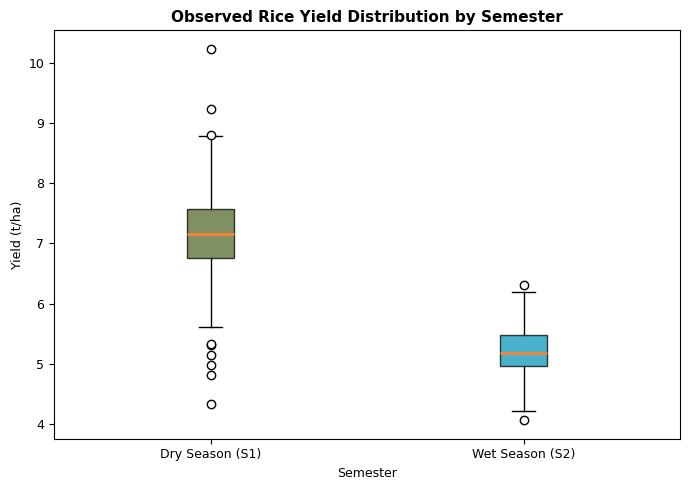

Saved: chapter5_figures\fig01_observed_yield_by_semester.png


In [40]:
# ------------------------------------------------------------
# 4. Figure 1: Observed Yield Distribution by Semester
# Helps support the agriculture discussion in 5.2.1
# ------------------------------------------------------------

if "observed_df" in globals():
    tmp = observed_df.dropna(subset=["Yield_t_ha", "Semester"]).copy()

    tmp["Semester_Label"] = (
        tmp["Semester"]
        .map(SEM_LABELS)
        .fillna(tmp["Semester"])
    )

    semester_order = ["Dry Season (S1)", "Wet Season (S2)"]

    semesters_present = [
        sem for sem in semester_order
        if sem in tmp["Semester_Label"].unique()
    ]

    data = [
        tmp.loc[tmp["Semester_Label"] == sem, "Yield_t_ha"].values
        for sem in semesters_present
    ]

    plot_boxplot(
        data=data,
        labels=semesters_present,
        title="Observed Rice Yield Distribution by Semester",
        xlabel="Semester",
        ylabel="Yield (t/ha)",
        filename="fig01_observed_yield_by_semester.png",
        figsize=(7, 5),
        color_map=SEM_COLORS,
        default_color=GREEN
    )

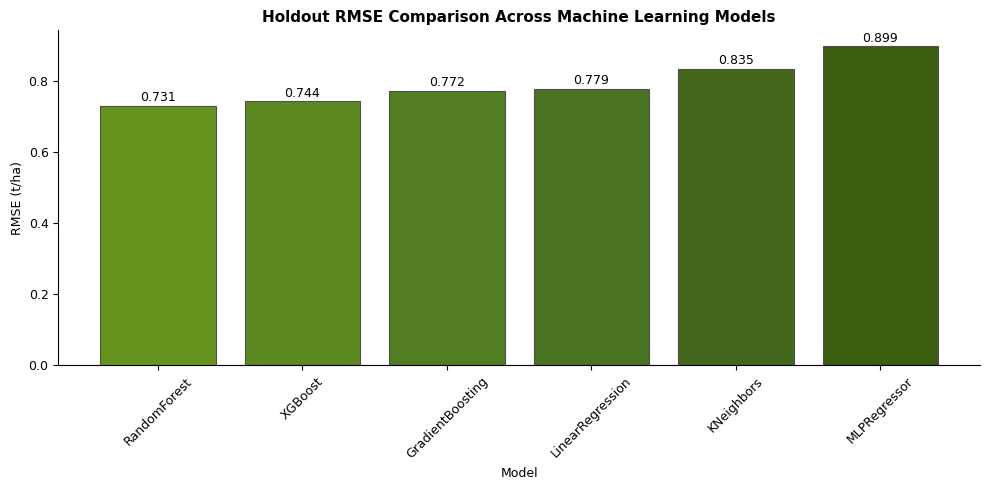

Saved: chapter5_figures\fig02_holdout_rmse_comparison.png


In [41]:
# ------------------------------------------------------------
# 2. Figure 2: Holdout RMSE Comparison Across ML Models
# Main comparative evidence for 5.3.1
# ------------------------------------------------------------

if "holdout_results_df" in globals():
    plot_df = (
        holdout_results_df.copy()
        .sort_values("RMSE", ascending=True)
        .reset_index(drop=True)
    )

    green_hexes = ["#3B5D0F", "#486F25", "#568122", "#64931E"]
    cmap = LinearSegmentedColormap.from_list("custom_green_scale", green_hexes)

    color_positions = np.linspace(1, 0, len(plot_df))
    bar_colors = [cmap(pos) for pos in color_positions]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(
        plot_df["Model"],
        plot_df["RMSE"],
        color=bar_colors,
        edgecolor=EDGE_COLOR,
        linewidth=0.8
    )

    ax.set_title(
        "Holdout RMSE Comparison Across Machine Learning Models",
        fontweight="bold"
    )
    ax.set_xlabel("Model")
    ax.set_ylabel("RMSE (t/ha)")
    ax.tick_params(axis="x", rotation=45)

    for i, v in enumerate(plot_df["RMSE"]):
        ax.text(
            i,
            v + 0.005,
            f"{v:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    clean_axis(ax, grid=False)

    save_and_show(fig, "fig02_holdout_rmse_comparison.png")

C:\Users\conch\AppData\Local\Temp\ipykernel_12836\4211734186.py:115: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


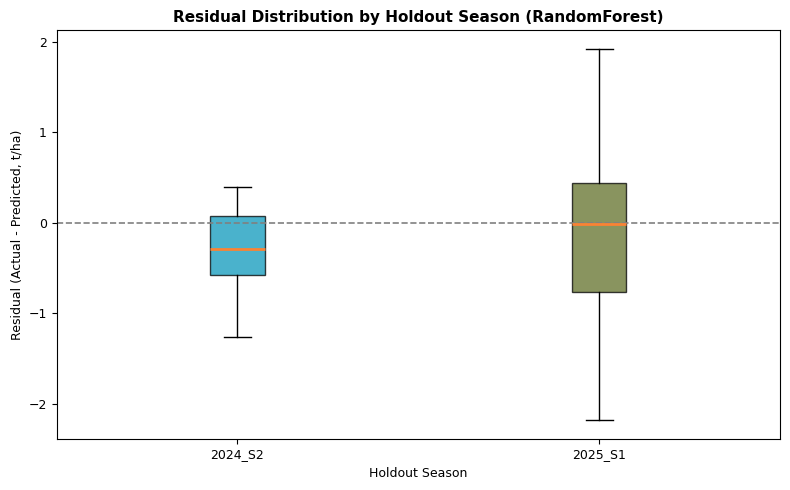

Saved: chapter5_figures\fig05_residual_boxplot_by_season.png


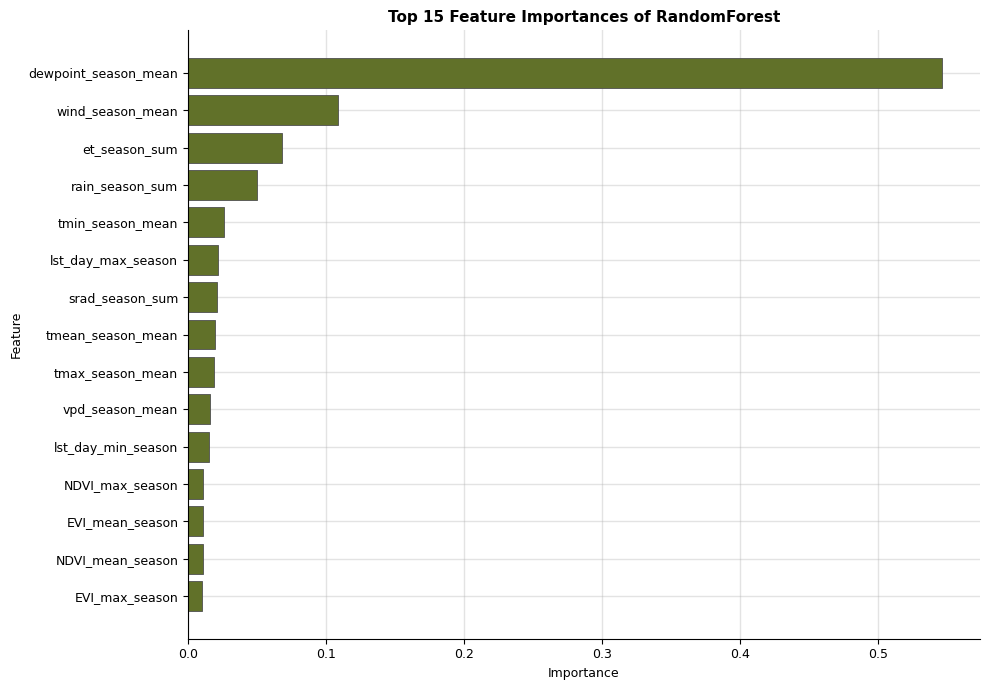

Saved: chapter5_figures\fig06_top_feature_importances.png


In [42]:
# ------------------------------------------------------------
# 3. Figure 5: Residual Distribution by Holdout Season
# Helps with 5.3.3 reliability notes
# ------------------------------------------------------------

if "selected_preds_df" in globals():
    tmp = selected_preds_df.dropna(subset=["season_id", "Residual"]).copy()

    seasons = sorted(tmp["season_id"].unique())

    data = [
        tmp.loc[tmp["season_id"] == season, "Residual"].values
        for season in seasons
    ]

    plot_boxplot(
        data=data,
        labels=seasons,
        title=f"Residual Distribution by Holdout Season ({deployment_model_name})",
        xlabel="Holdout Season",
        ylabel="Residual (Actual - Predicted, t/ha)",
        filename="fig05_residual_boxplot_by_season.png",
        figsize=(8, 5),
        color_map=SEASON_COLORS,
        default_color=GREEN,
        zero_line=True
    )


# ------------------------------------------------------------
# 7. Figure 6: Top Feature Importances of the Deployment Model
# Main evidence for 5.3.2
# ------------------------------------------------------------

if "feature_insight_df" in globals() and "importance" in feature_insight_df.columns:
    imp_df = (
        feature_insight_df.copy()
        .sort_values("importance", ascending=False)
        .head(15)
        .sort_values("importance", ascending=True)
    )

    plot_horizontal_bar(
        df=imp_df,
        y_col="feature_after_prep",
        x_col="importance",
        title=f"Top 15 Feature Importances of {deployment_model_name}",
        xlabel="Importance",
        ylabel="Feature",
        filename="fig06_top_feature_importances.png",
        figsize=(10, 7),
        color=GREEN,
        grid=True
    )

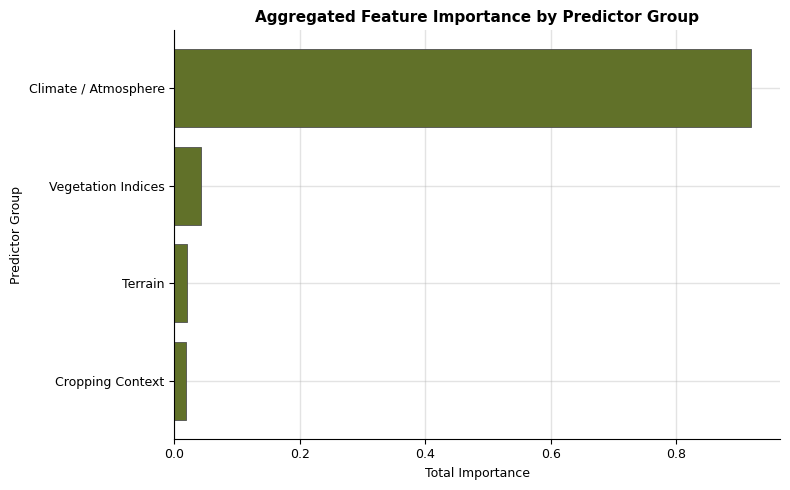

Saved: chapter5_figures\fig07_feature_group_importance.png


In [43]:
# ------------------------------------------------------------
# 4. Figure 7: Aggregated Feature Group Importance
# Stronger agriculture-facing interpretation
# ------------------------------------------------------------

if "feature_insight_df" in globals() and "importance" in feature_insight_df.columns:
    tmp = feature_insight_df.copy()

    tmp["FeatureGroup"] = tmp["feature_after_prep"].apply(group_feature)

    grp = (
        tmp.groupby("FeatureGroup", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=True)
    )

    plot_horizontal_bar(
        df=grp,
        y_col="FeatureGroup",
        x_col="importance",
        title="Aggregated Feature Importance by Predictor Group",
        xlabel="Total Importance",
        ylabel="Predictor Group",
        filename="fig07_feature_group_importance.png",
        figsize=(8, 5),
        color=GREEN,
        grid=True
    )

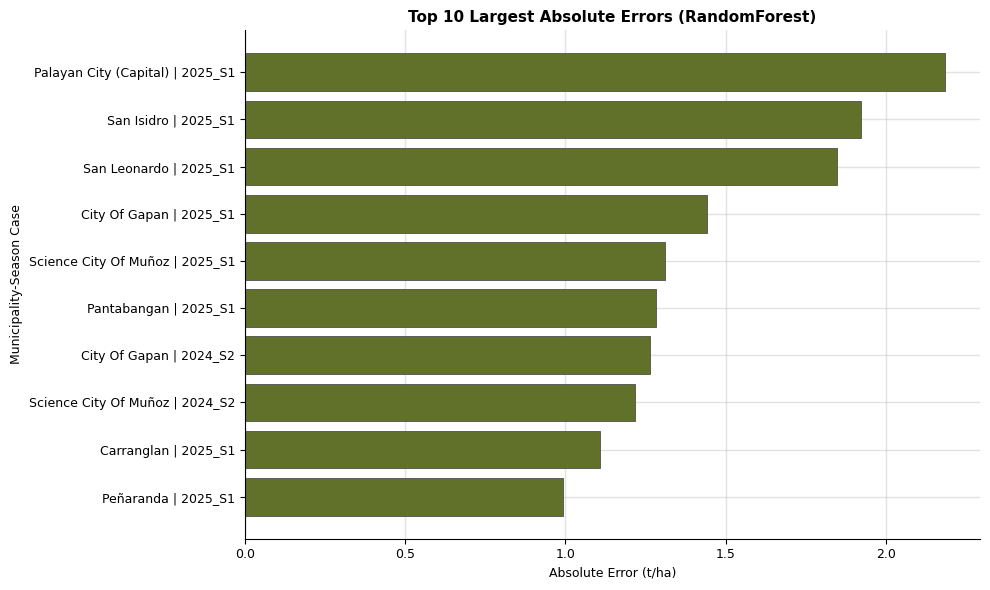

Saved: chapter5_figures\fig08_top_absolute_error_cases.png


In [44]:
# ------------------------------------------------------------
# 5. Figure 8: Top Municipality-Season Cases by Absolute Error
# Helps show where the model struggles
# ------------------------------------------------------------

if "selected_preds_df" in globals():
    tmp = (
        selected_preds_df.copy()
        .sort_values("AbsError", ascending=False)
        .head(10)
    )

    tmp["CaseLabel"] = (
        tmp["MUNICIPALITY"].astype(str)
        + " | "
        + tmp["season_id"].astype(str)
    )

    tmp = tmp.sort_values("AbsError", ascending=True)

    plot_horizontal_bar(
        df=tmp,
        y_col="CaseLabel",
        x_col="AbsError",
        title=f"Top 10 Largest Absolute Errors ({deployment_model_name})",
        xlabel="Absolute Error (t/ha)",
        ylabel="Municipality-Season Case",
        filename="fig08_top_absolute_error_cases.png",
        figsize=(10, 6),
        color=GREEN,
        grid=True
    )